In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random
import seaborn as sns
from sklearn.metrics import confusion_matrix
import os
import pandas as pd

import tensorflow as tf
tf.get_logger().setLevel(40) # suppress deprecation messages

import logging
import datetime

### MNIST

In [368]:
keras_cnn = tf.keras.models.load_model('../pretrained_models/cnn_mnist.h5')
misclassified_image_user_set = np.load('../data/mnist_cf/misclassified_image_user_set.npy')
user_explanations_g1 = np.load('../data/mnist_cf/user_explanations_g1.npy')
user_explanations_g2 = np.load('../data/mnist_cf/user_explanations_g2.npy')
user_indices = np.load('../data/mnist_cf/user_indices_mnist.npy')
user_explanations_g1_flattened = user_explanations_g1.reshape(-1,28,28,1)


In [19]:
mnist = tf.keras.datasets.mnist 

(x_train, y_train), (x_test, y_test) = mnist.load_data()
# Normalize the images to [-0.5, 0.5] range
x_train = (x_train.astype(np.float32) - 127.5) / 255.0
x_test = (x_test.astype(np.float32) - 127.5) / 255.0

In [3]:
pred_probs_user_g1 = keras_cnn.predict(user_explanations_g1_flattened)

33/33 [==============================] - 0s 2ms/step


In [166]:
def plot_6_columns(img_idx, cf_indices):
    true_label = y_test[user_indices[img_idx]]
    # 缩小 figsize 的高度（从 10 降到 7），这能从根本上压缩垂直间隙
    fig = plt.figure(figsize=(24, 7)) 
    # fig.suptitle(f'Sample {img_idx} | True Label: {true_label}', fontsize=24, y=1.02)

    master_grid = fig.add_gridspec(1, 6, wspace=0.3)

    # 1st column (Original)
    original_img = x_test[user_indices[img_idx]]
    original_pred_prob = keras_cnn.predict(original_img.reshape(1,28,28,1), verbose=0).squeeze()
    original_pred_label = np.argmax(original_pred_prob)

    # 调整 height_ratios，让图片占更多比重 (2.5:1)，这样给 Bar Plot 的原始区域就变扁了
    orig_col = master_grid[0, 0].subgridspec(2, 1, height_ratios=[1.5, 1], hspace=-0.1) # 尝试负 hspace
    
    title_color = 'blue'
    ax_orig_img = fig.add_subplot(orig_col[0])
    ax_orig_img.imshow(original_img, cmap='gray') 
    ax_orig_img.set_title(f"Original\nPred: {original_pred_label}", fontsize=22, pad=5, color=title_color)
    ax_orig_img.set_aspect('equal')
    ax_orig_img.axis('off')
    
    ax_orig_bar = fig.add_subplot(orig_col[1])
    ax_orig_bar.bar(range(10), original_pred_prob, color='skyblue')
    ax_orig_bar.set_box_aspect(0.6) # 稍微再调扁一点点
    ax_orig_bar.set_xticks(range(10)) # 解决你刚才提到的 X 轴显示问题
    ax_orig_bar.set_xticklabels(range(10), fontsize=14)
    # ax_orig_bar.set_ylabel("Softmax Score")
    ax_orig_bar.set_ylim(0, 1.1)

    # 2th-6th columns
    # 注意：这里有一个逻辑修正，cf_data_list 取出来后，循环内应该用 enumerate 里的 i
    # 否则你的 sample = cf_data_list[cf_idx] 在 cf_idx 很大时会越界
    cf_data_list = user_explanations_g1[cf_indices, img_idx]
    
    for i in range(len(cf_indices)):
        col_idx = i + 1 
        cf_col = master_grid[0, col_idx].subgridspec(2, 1, height_ratios=[1.5, 1], hspace=-0.1)
        
        sample = cf_data_list[i]
        cf_idx_val = cf_indices[i]
        
        sample_pred_prob = keras_cnn.predict(sample.reshape(1,28,28,1), verbose=0).squeeze()
        sample_pred_label = np.argmax(sample_pred_prob)

        title_color = 'red' if sample_pred_label != true_label else 'black'
        ax_cf_img = fig.add_subplot(cf_col[0])
        ax_cf_img.imshow(sample, cmap='gray')
        ax_cf_img.set_title(f"User {cf_idx_val}\nPred: {sample_pred_label}", fontsize=22, pad=5, color=title_color)
        ax_cf_img.set_aspect('equal')
        ax_cf_img.axis('off')

        ax_cf_bar = fig.add_subplot(cf_col[1])
        ax_cf_bar.bar(range(10), sample_pred_prob, color='skyblue')
        ax_cf_bar.set_box_aspect(0.6)
        ax_cf_bar.set_xticks(range(10))
        ax_cf_bar.set_xticklabels(range(10), fontsize=14)
        ax_cf_bar.set_yticklabels([]) 
        ax_cf_bar.set_ylim(0, 1.1)

    plt.show()
    plt.close()

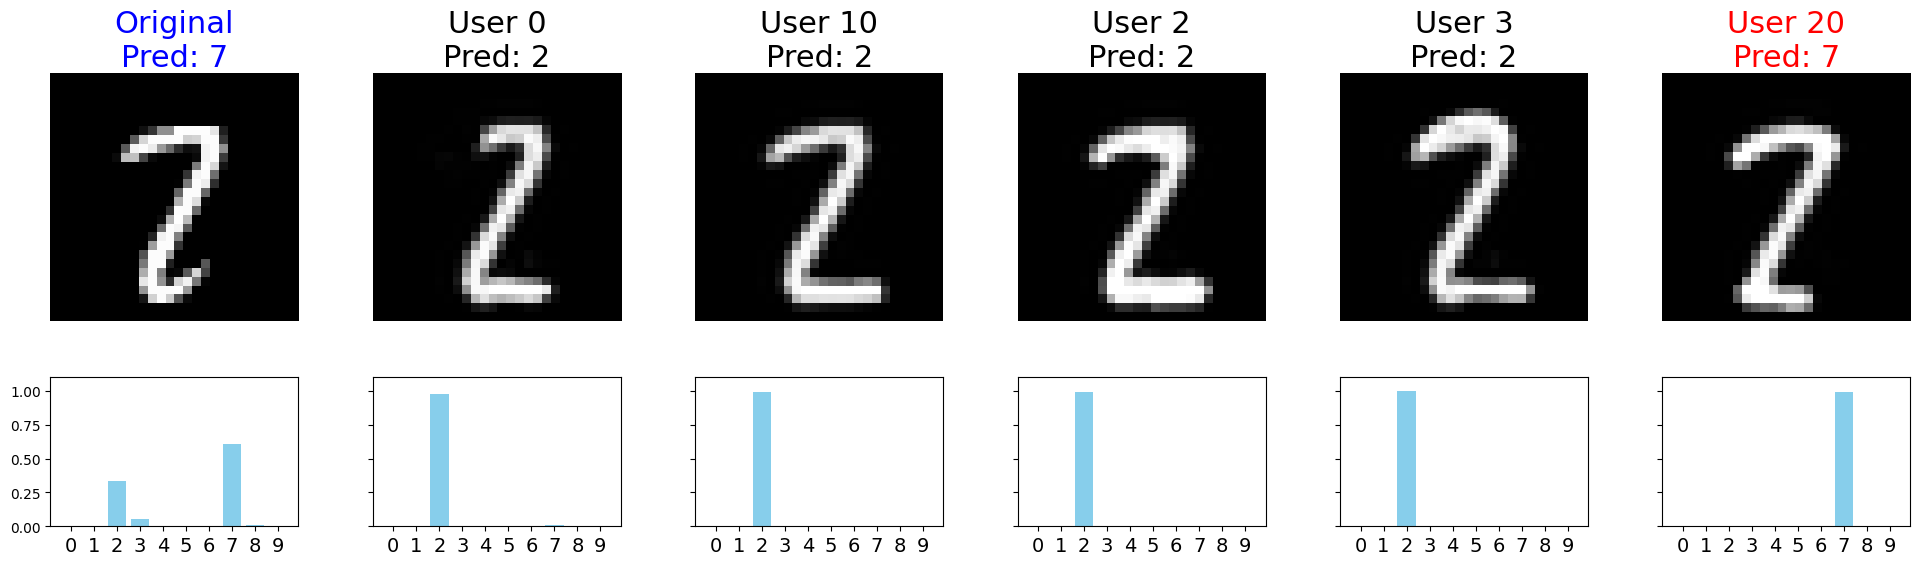

In [167]:
img_idx = 1
cf_indices = [0, 10, 2, 3, 20]
plot_6_columns(img_idx, cf_indices)

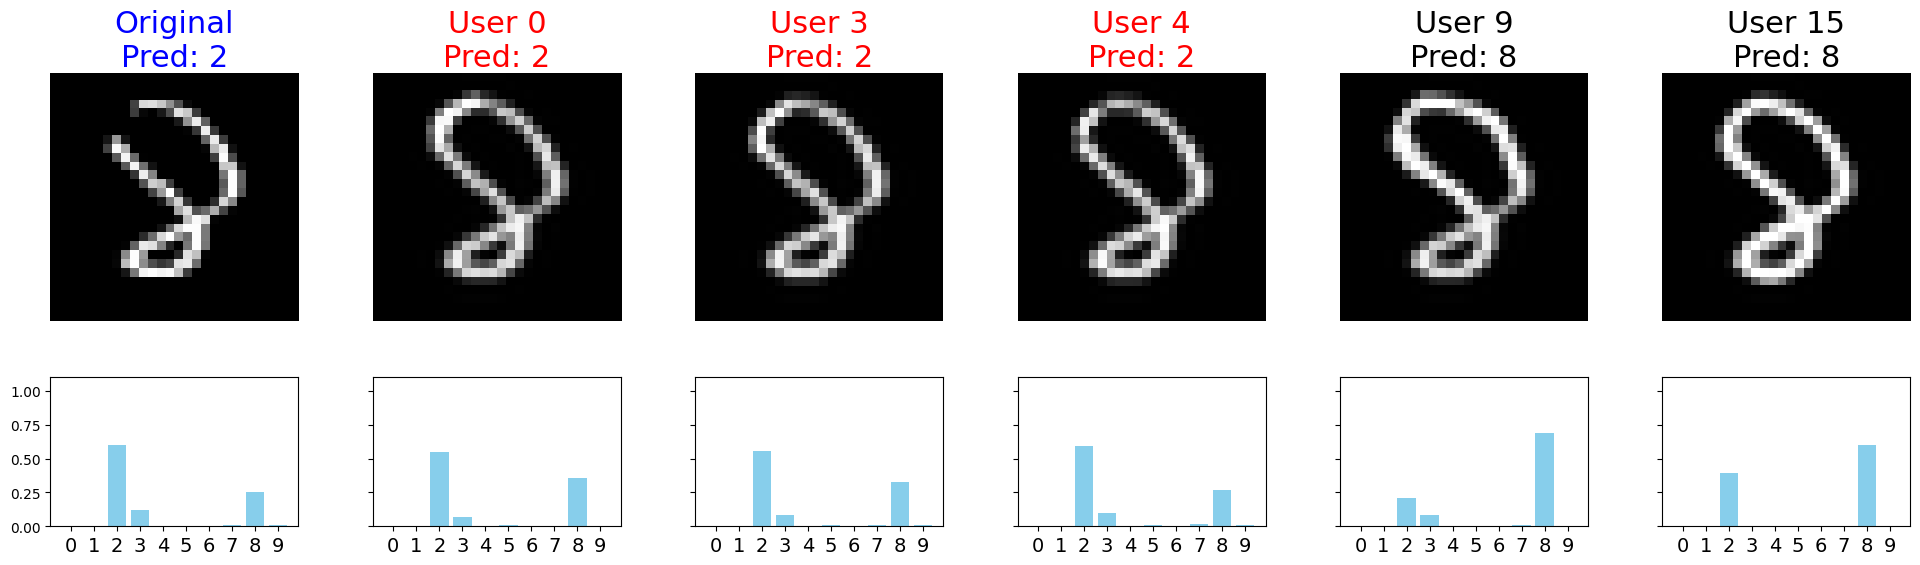

In [168]:
img_idx = 12
cf_indices = [0, 3, 4, 9, 15]
plot_6_columns(img_idx, cf_indices)

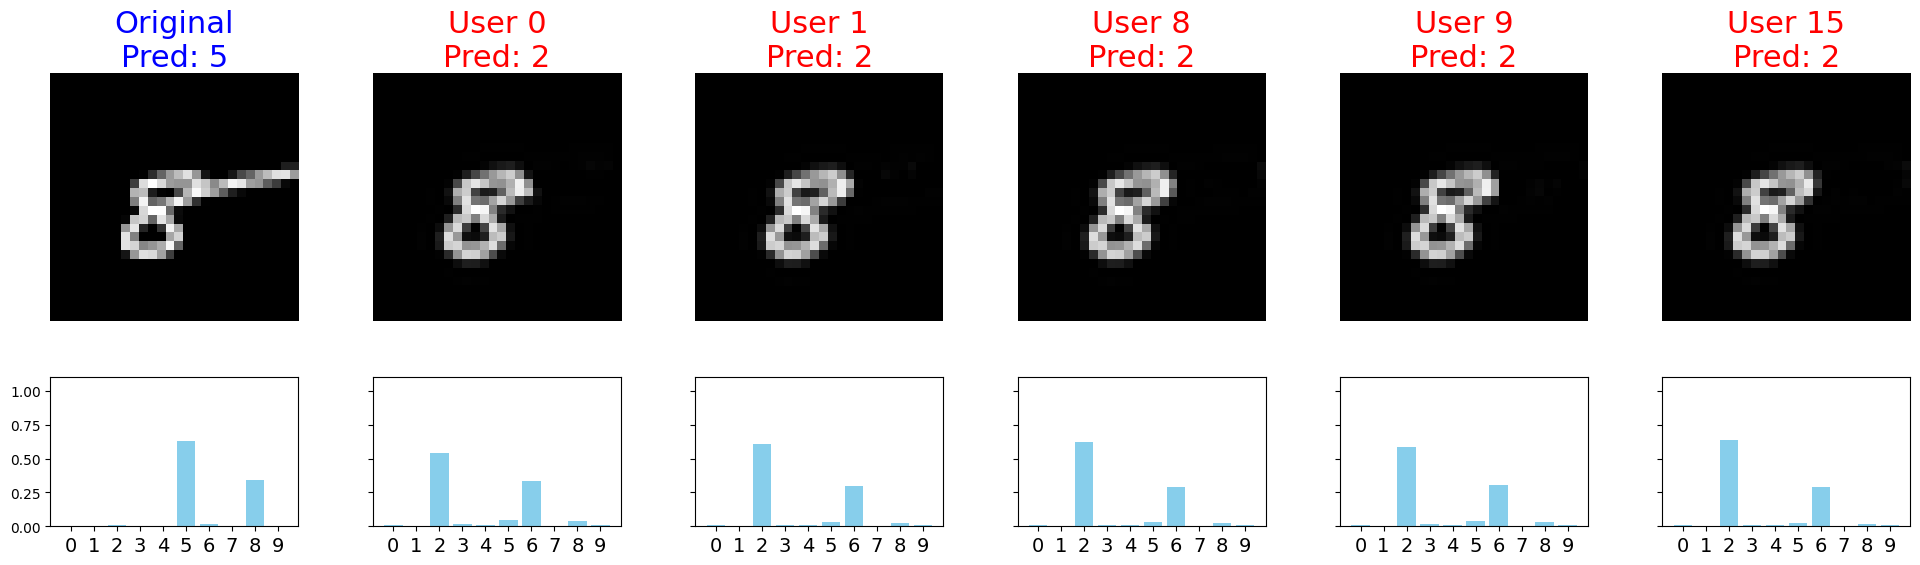

In [169]:
img_idx = 45
cf_indices = [0, 1, 8, 9, 15]
plot_6_columns(img_idx, cf_indices)

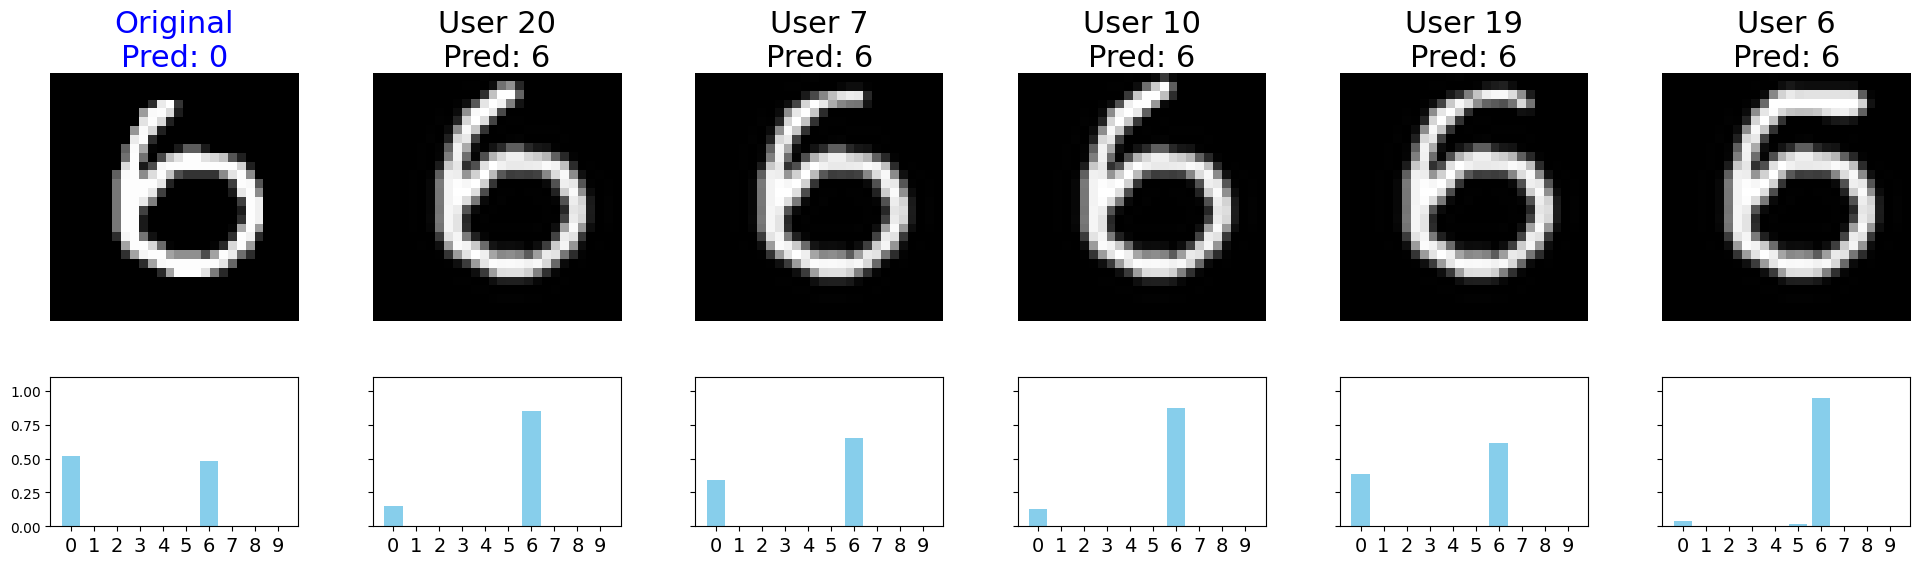

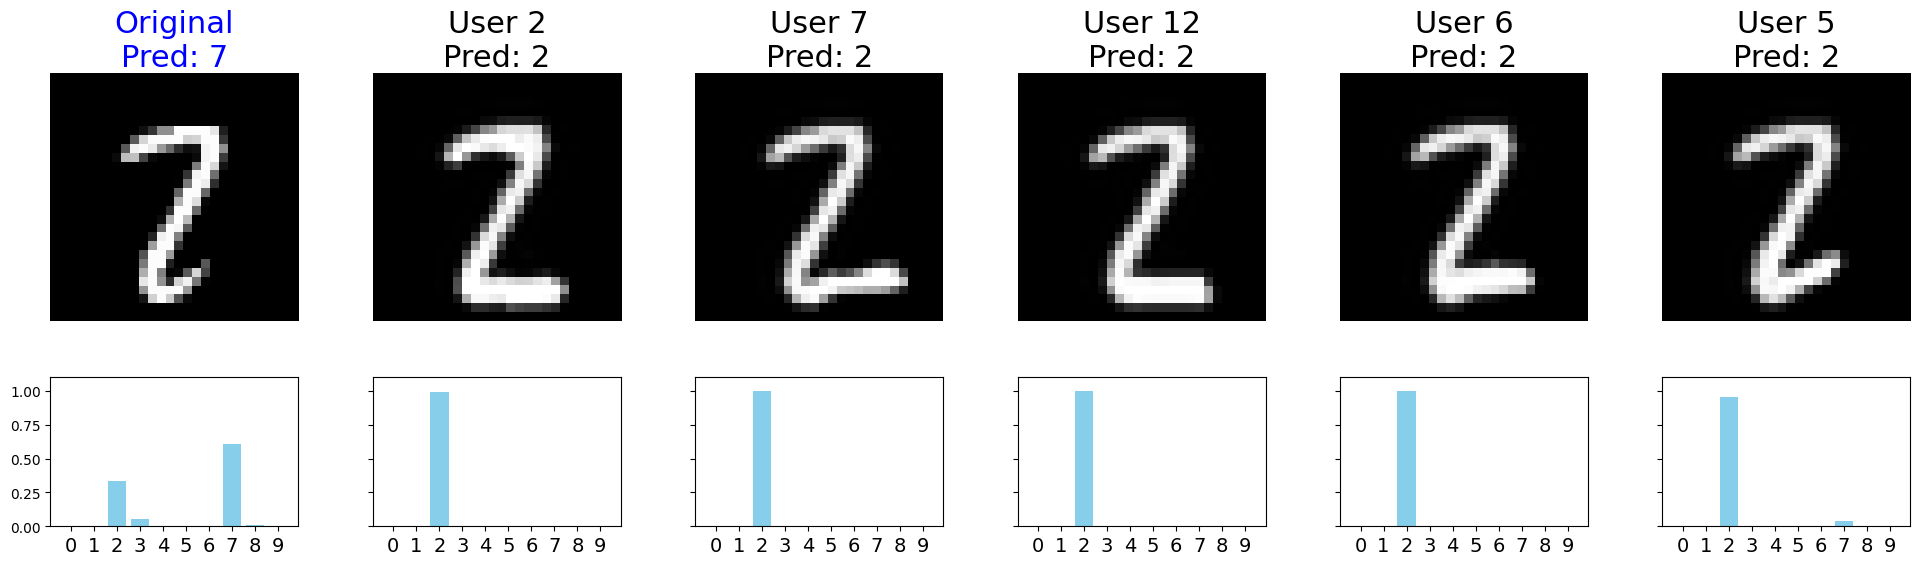

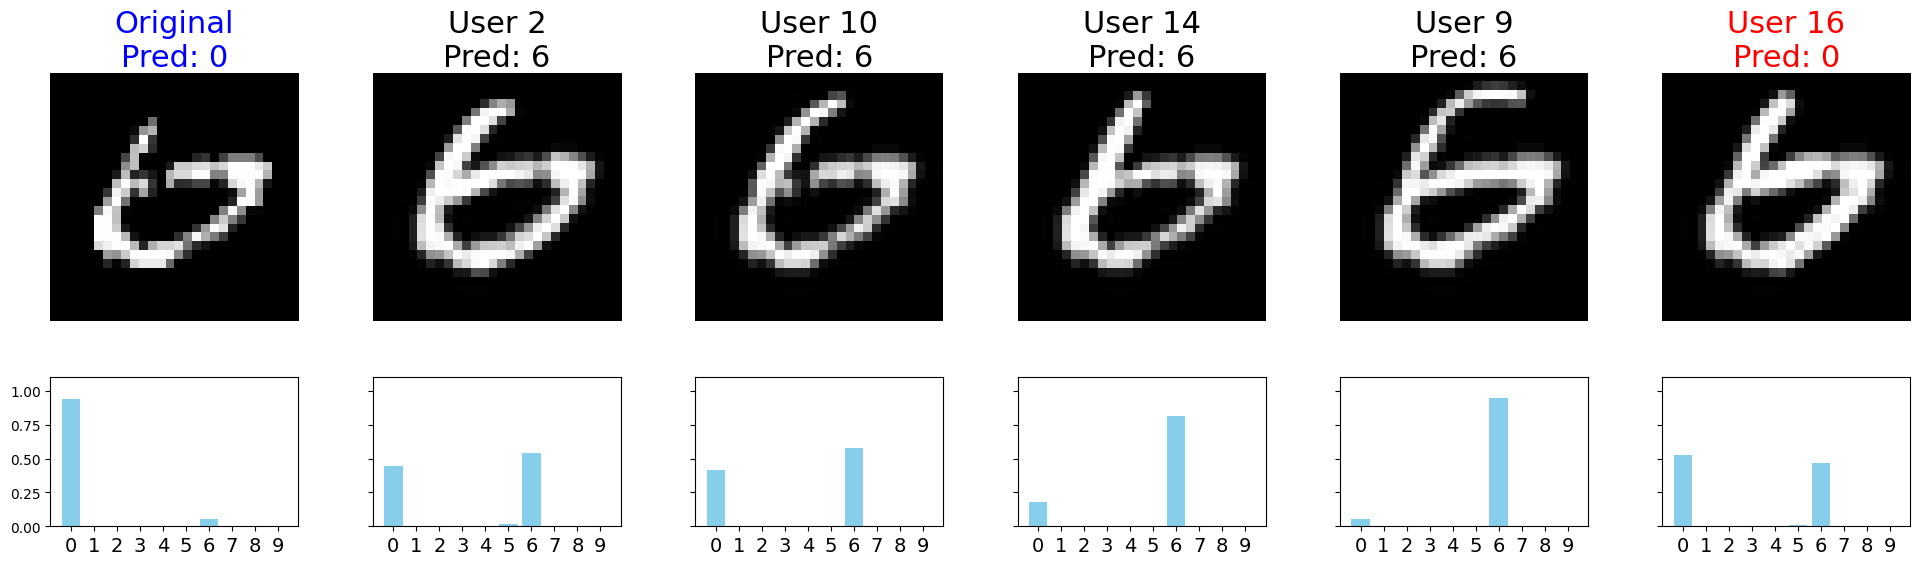

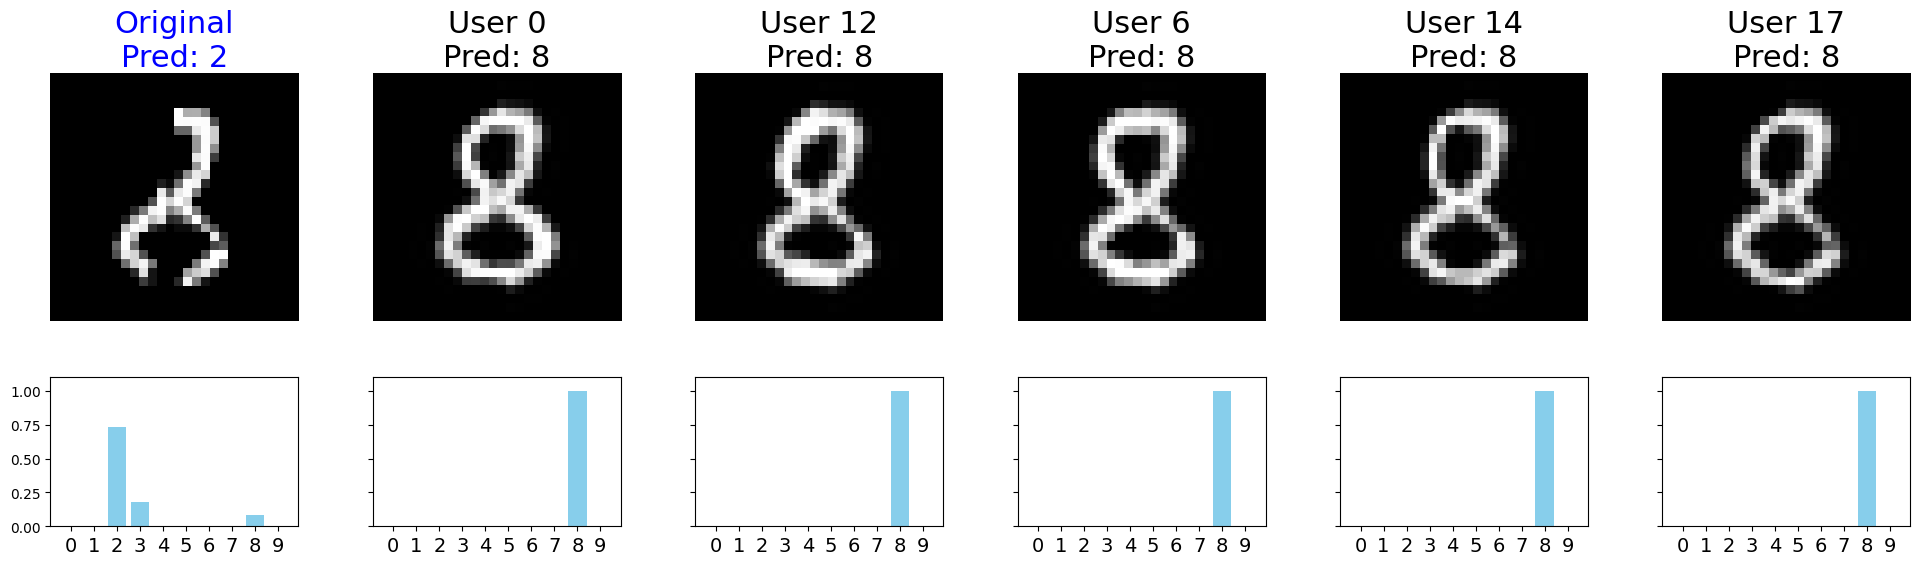

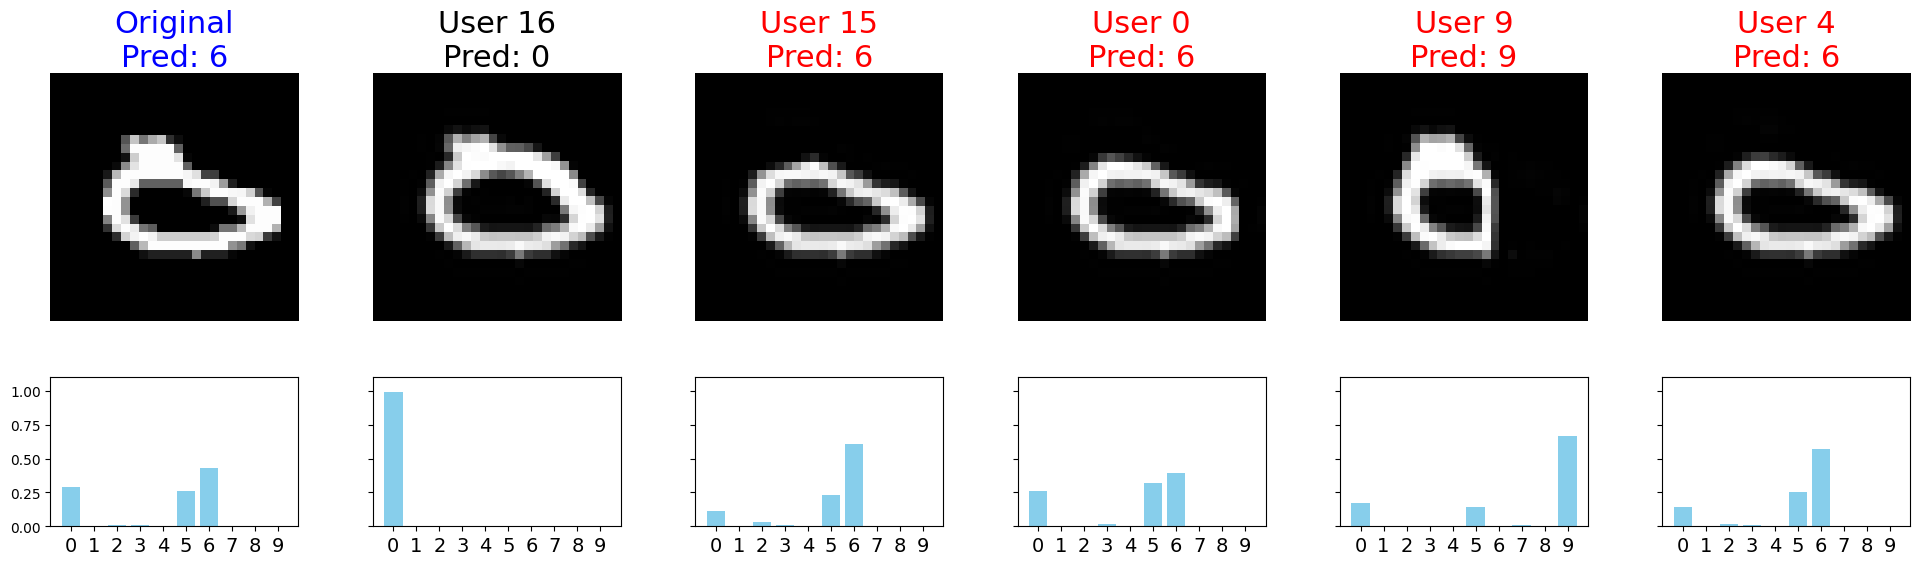

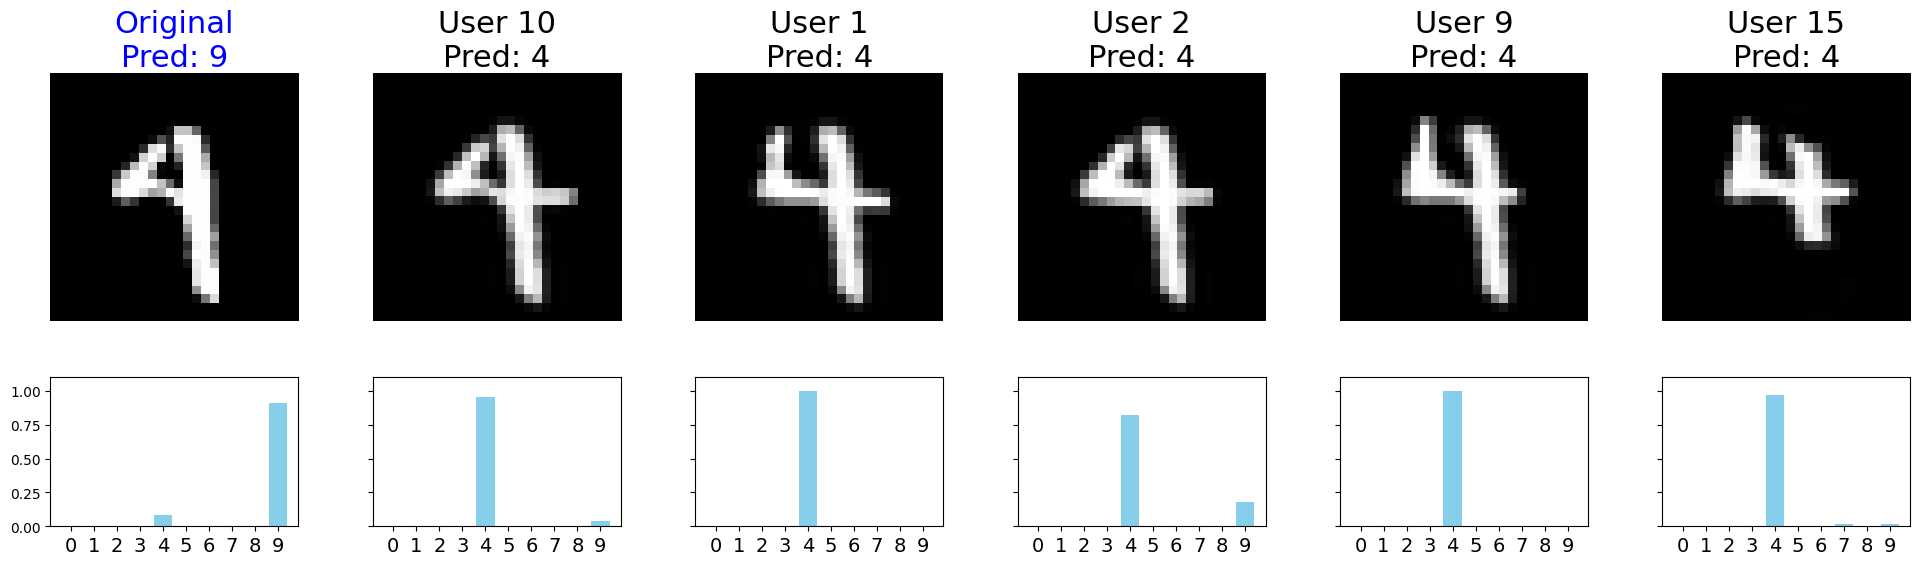

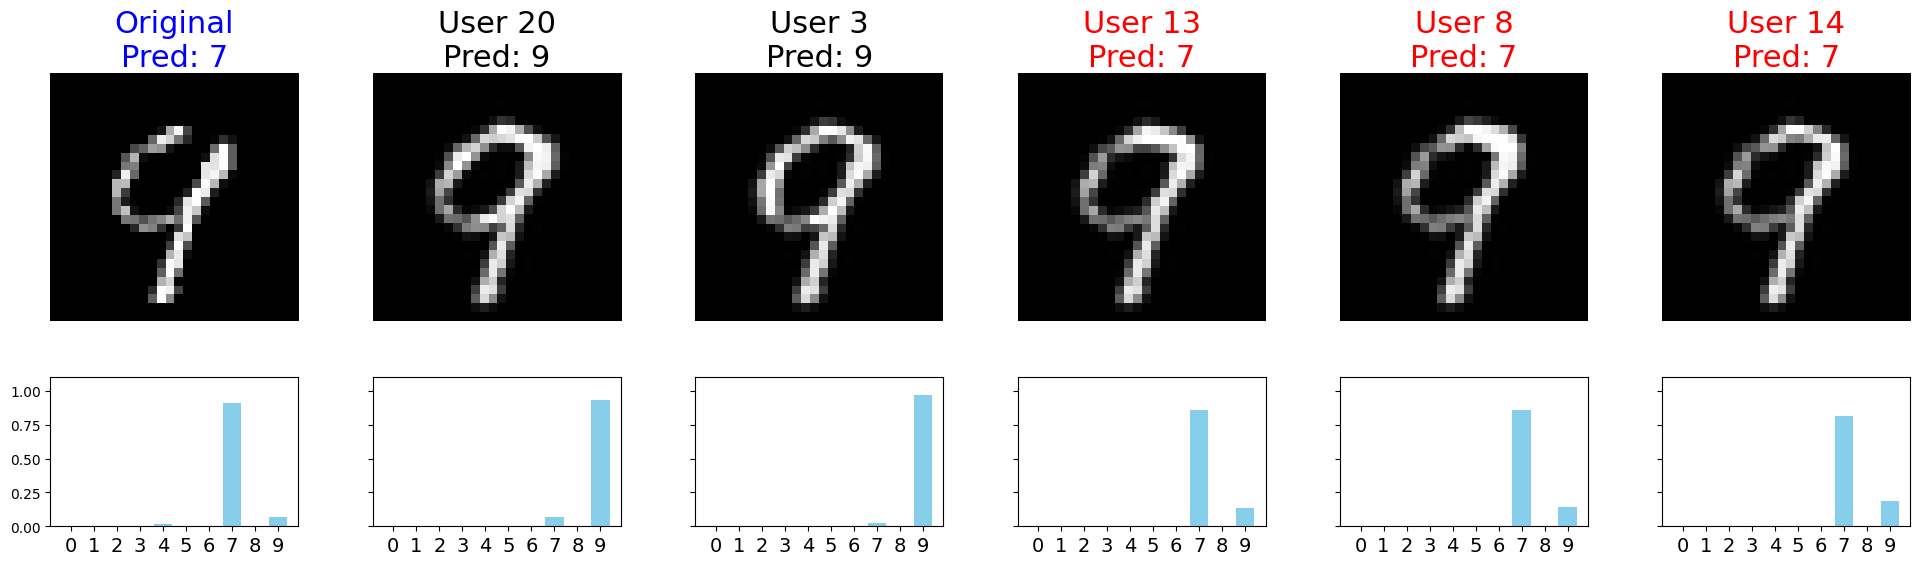

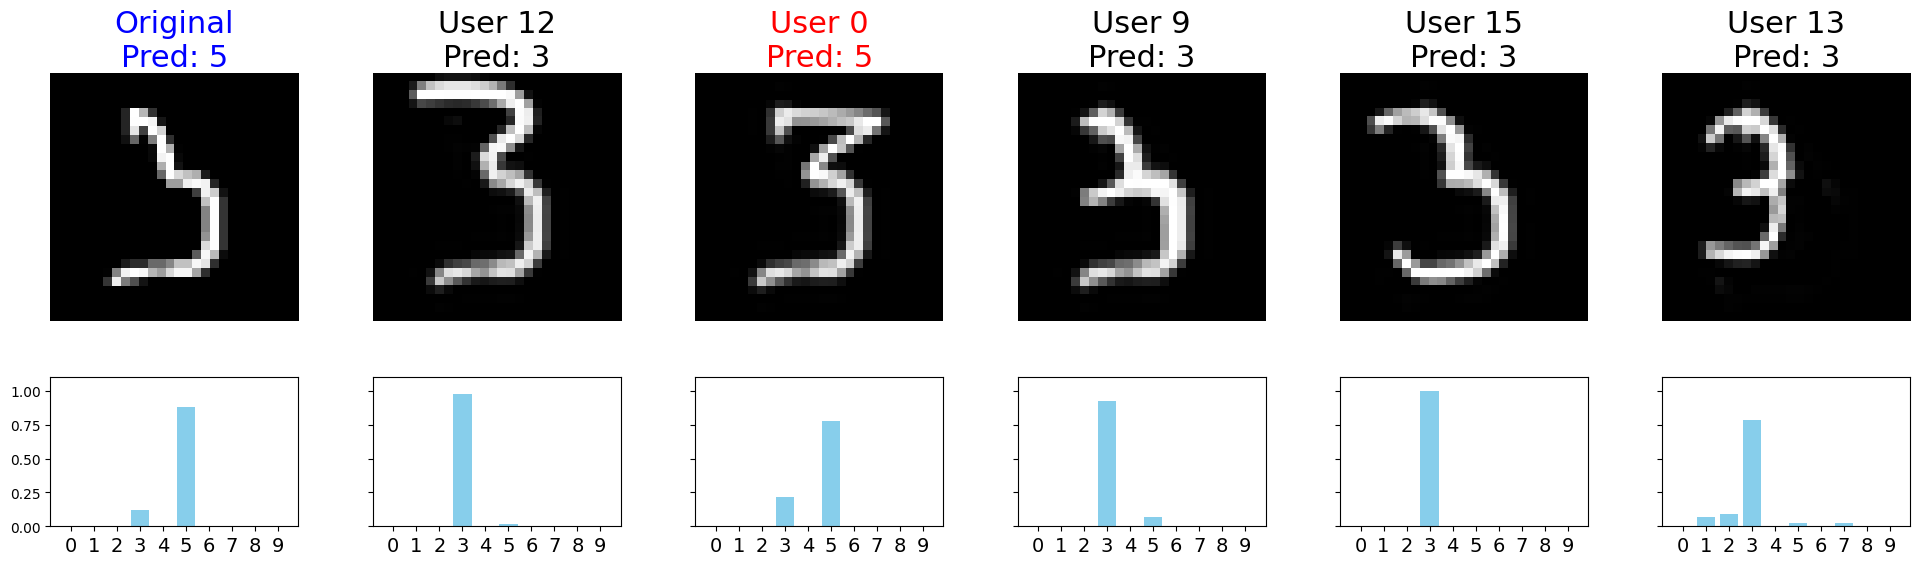

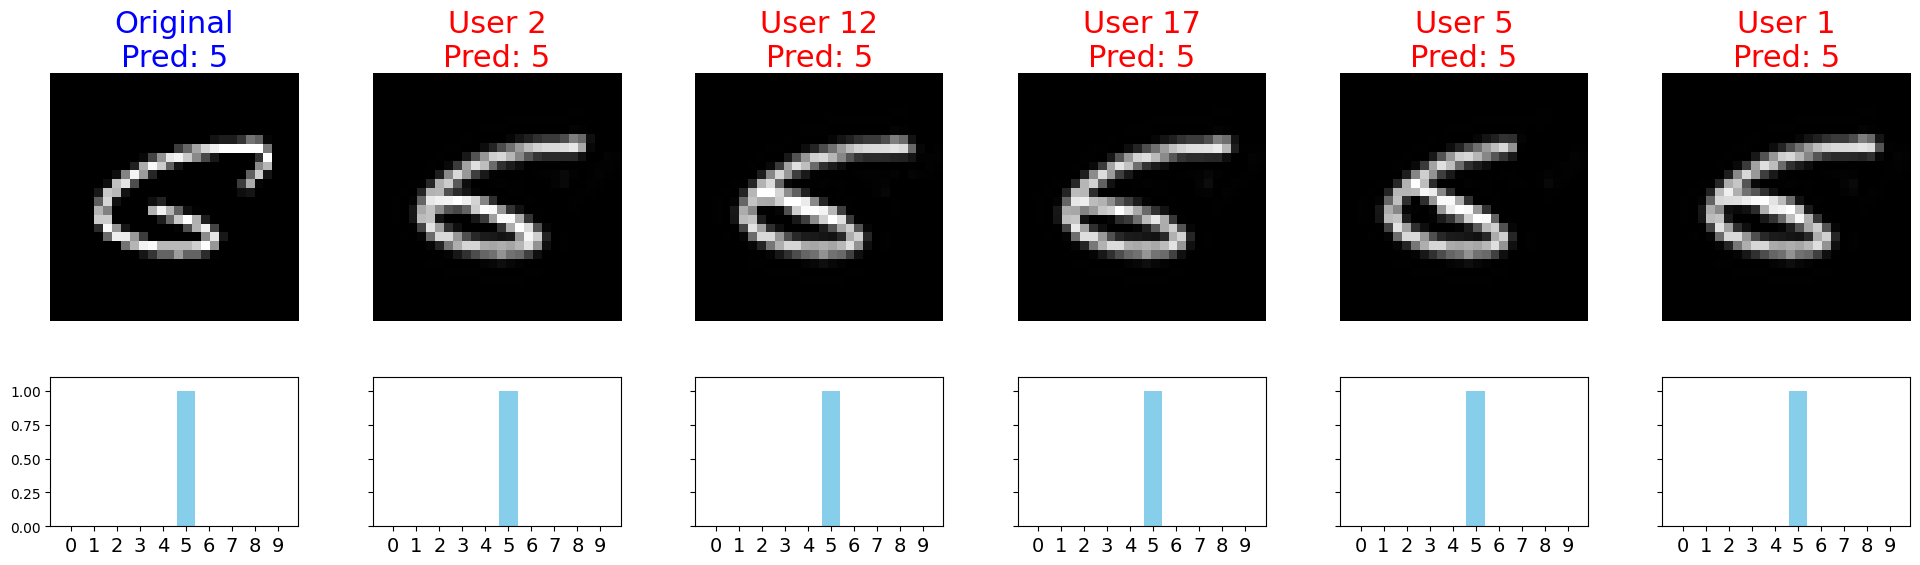

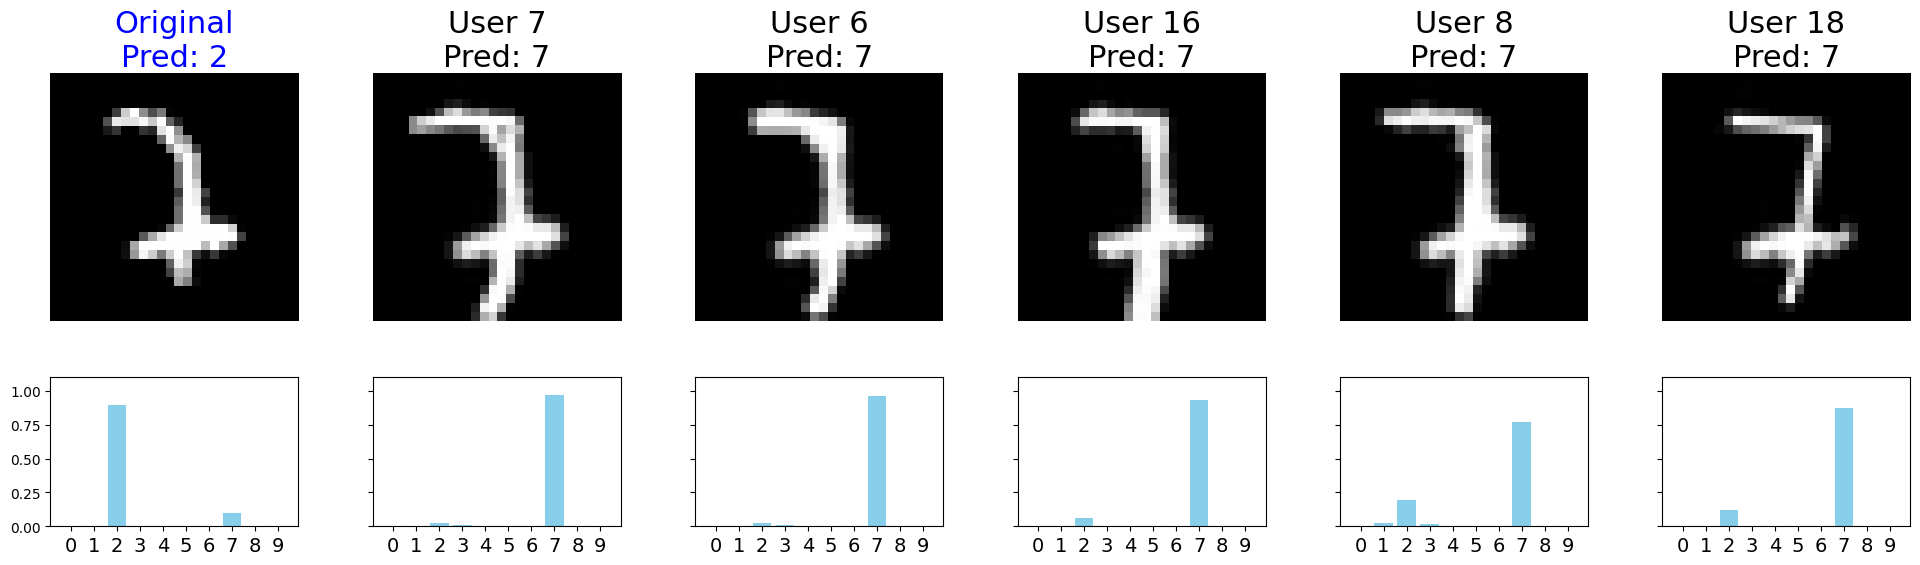

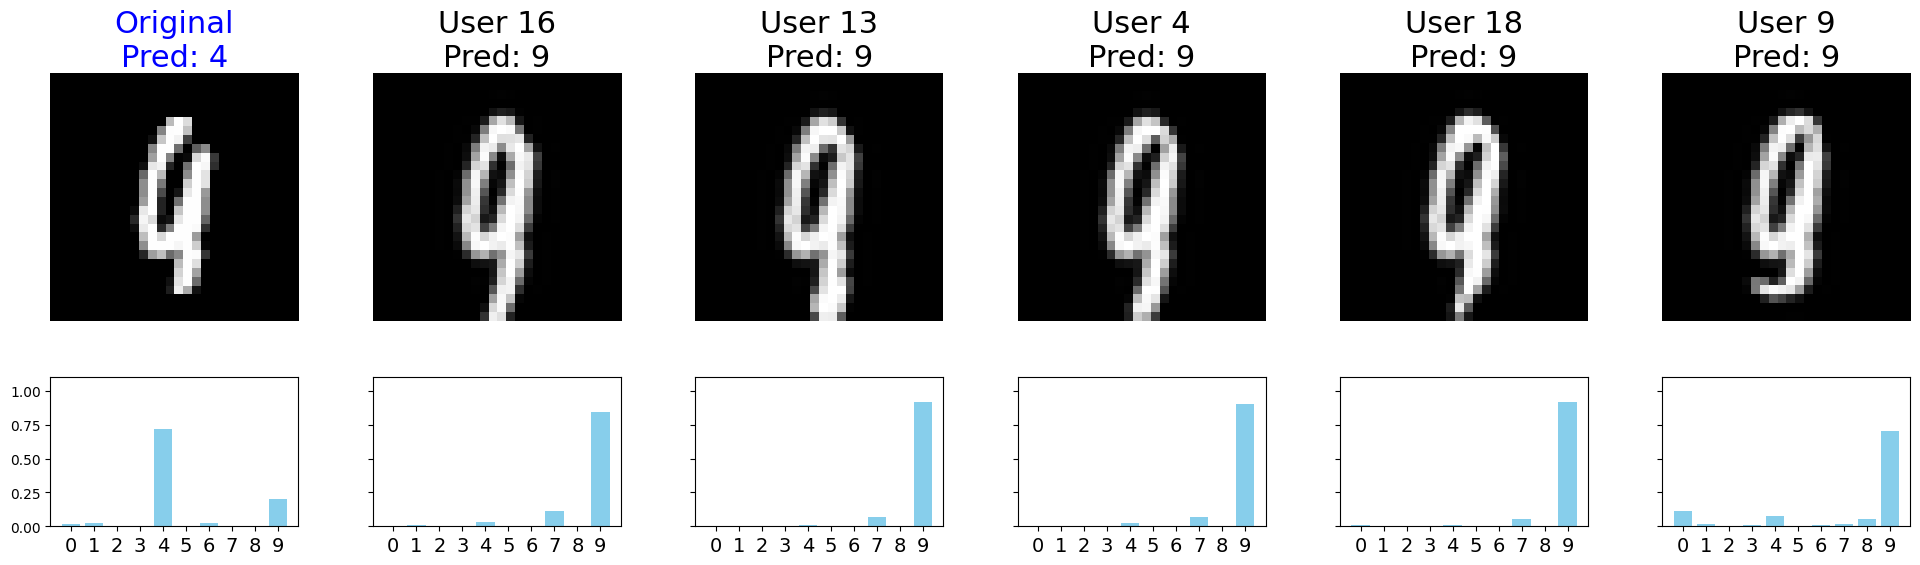

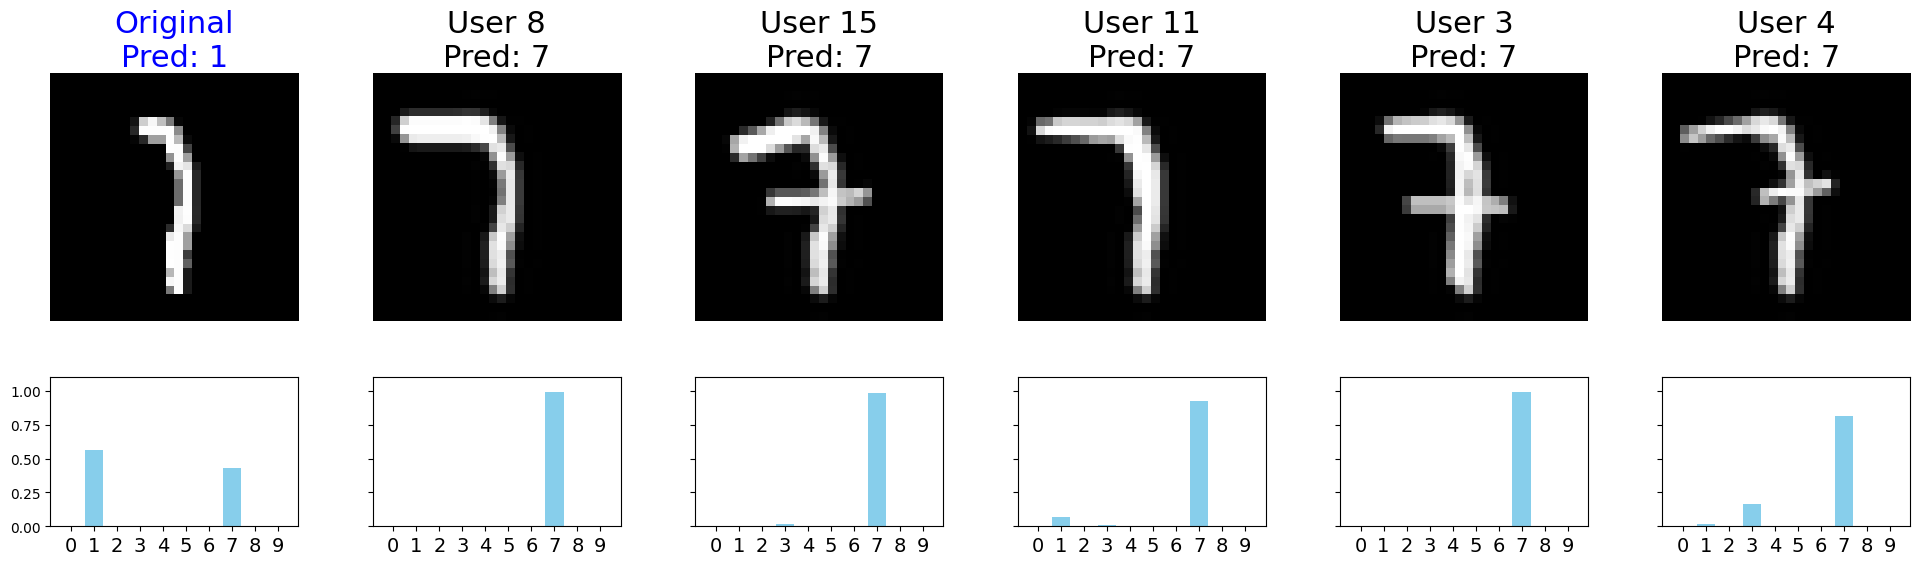

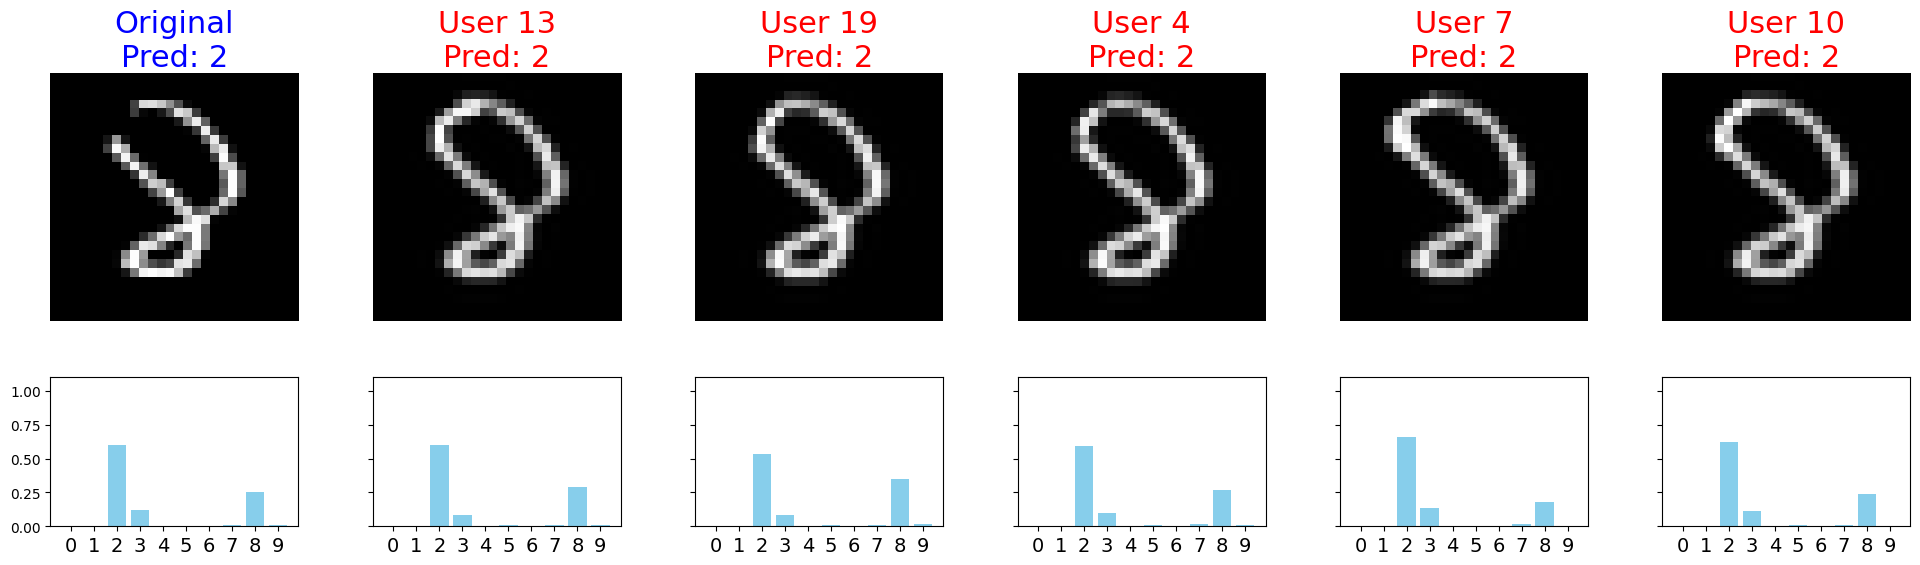

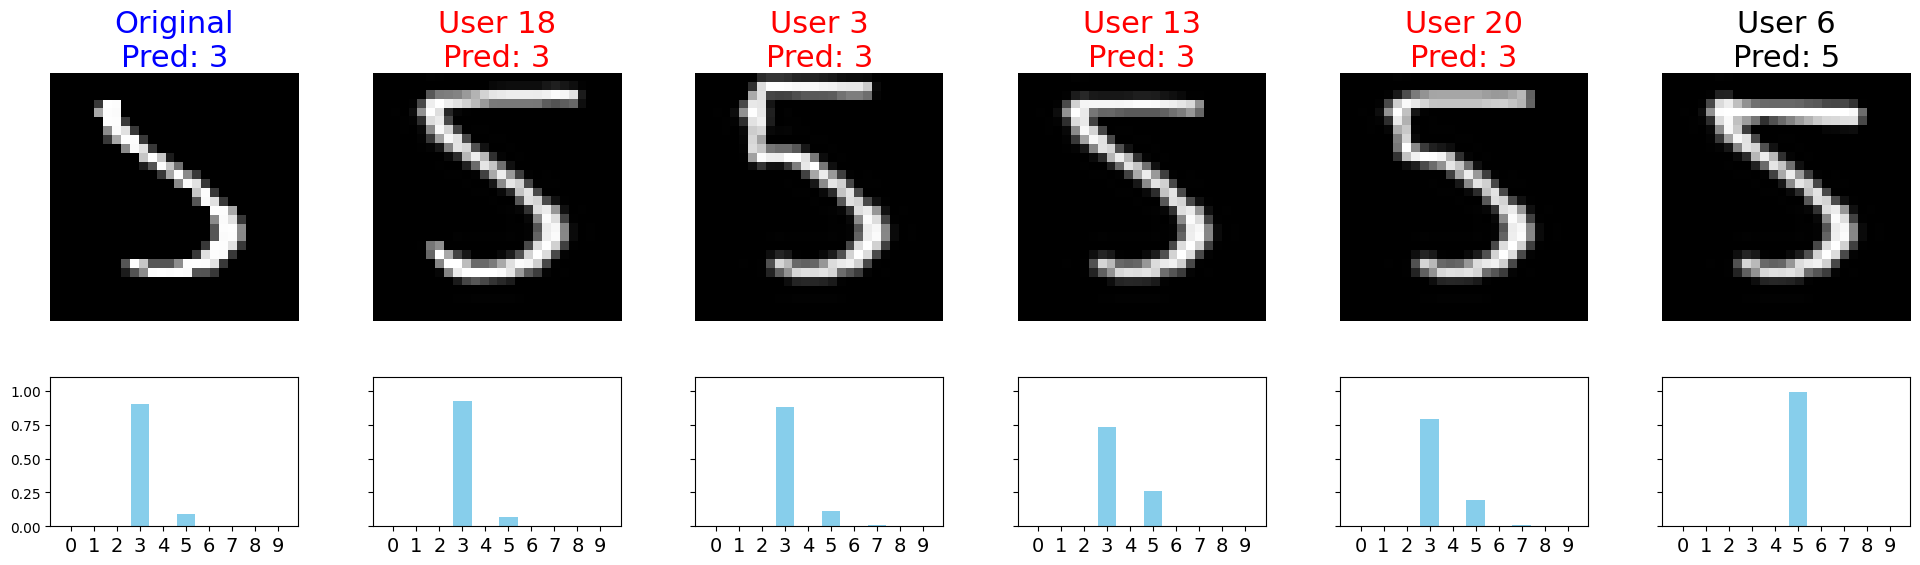

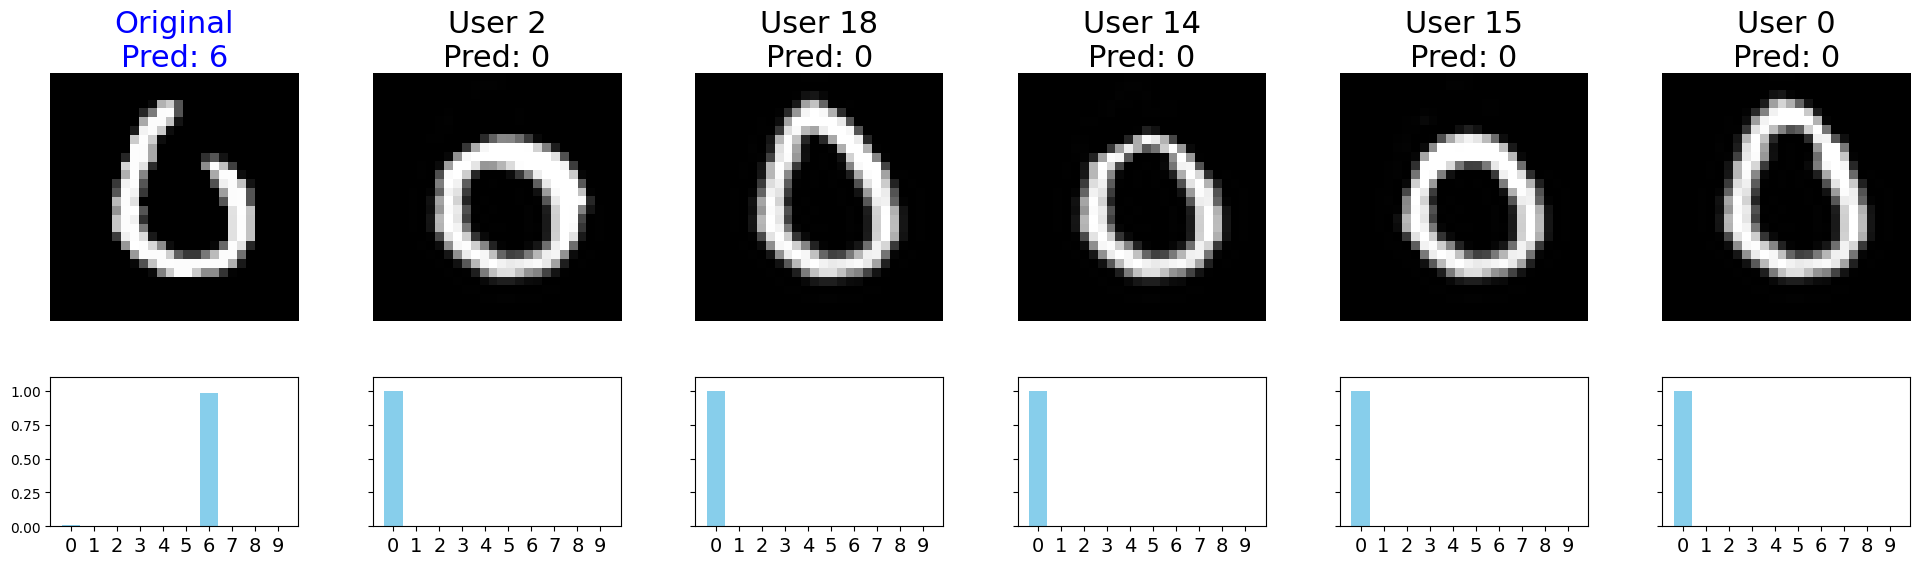

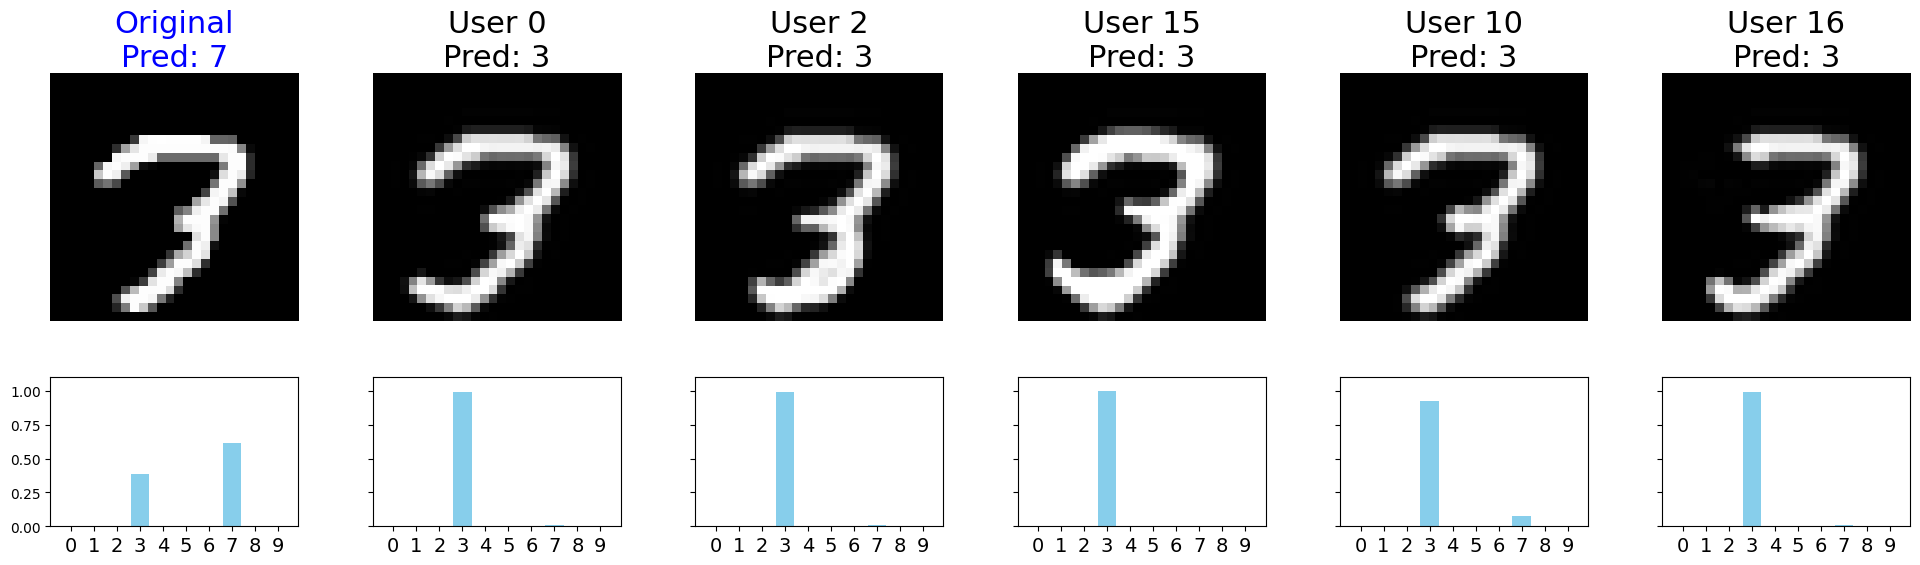

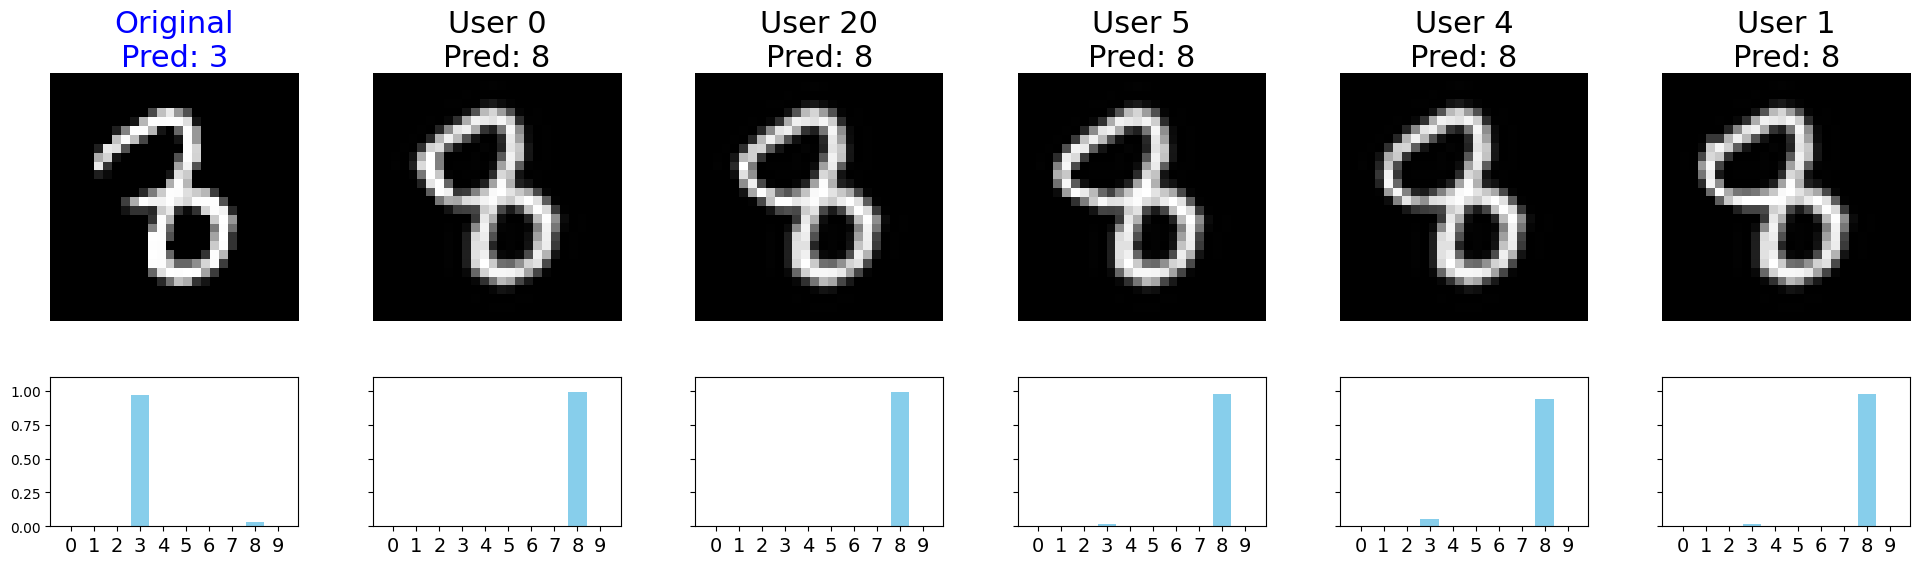

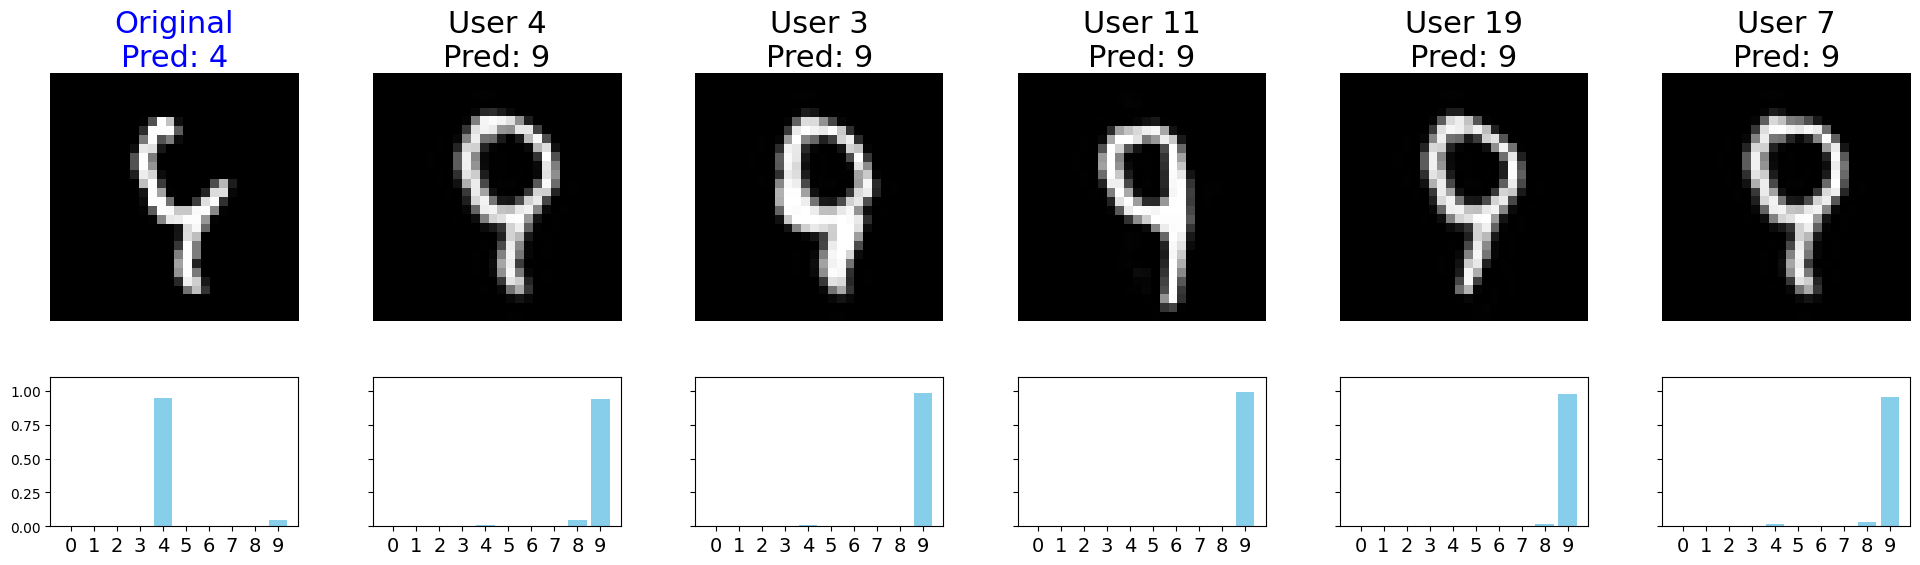

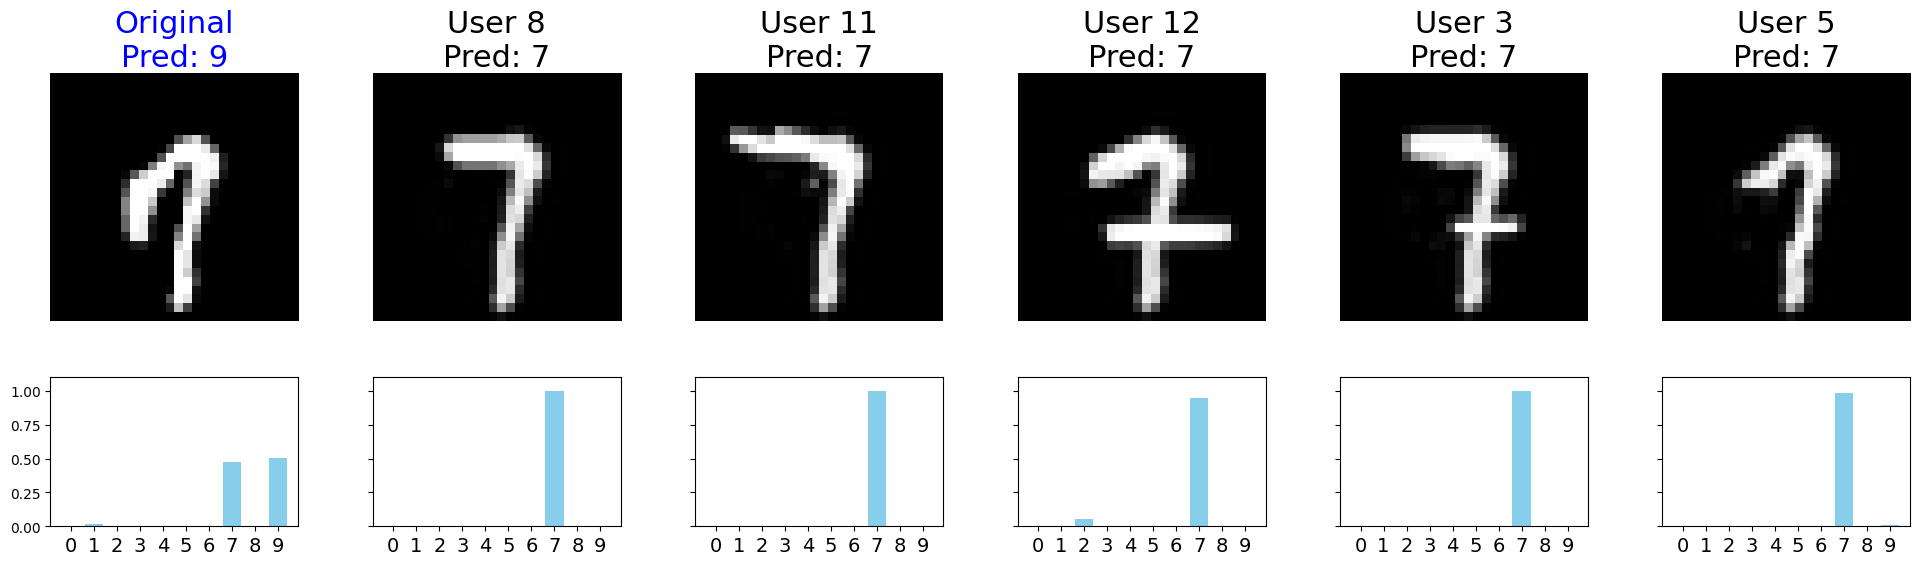

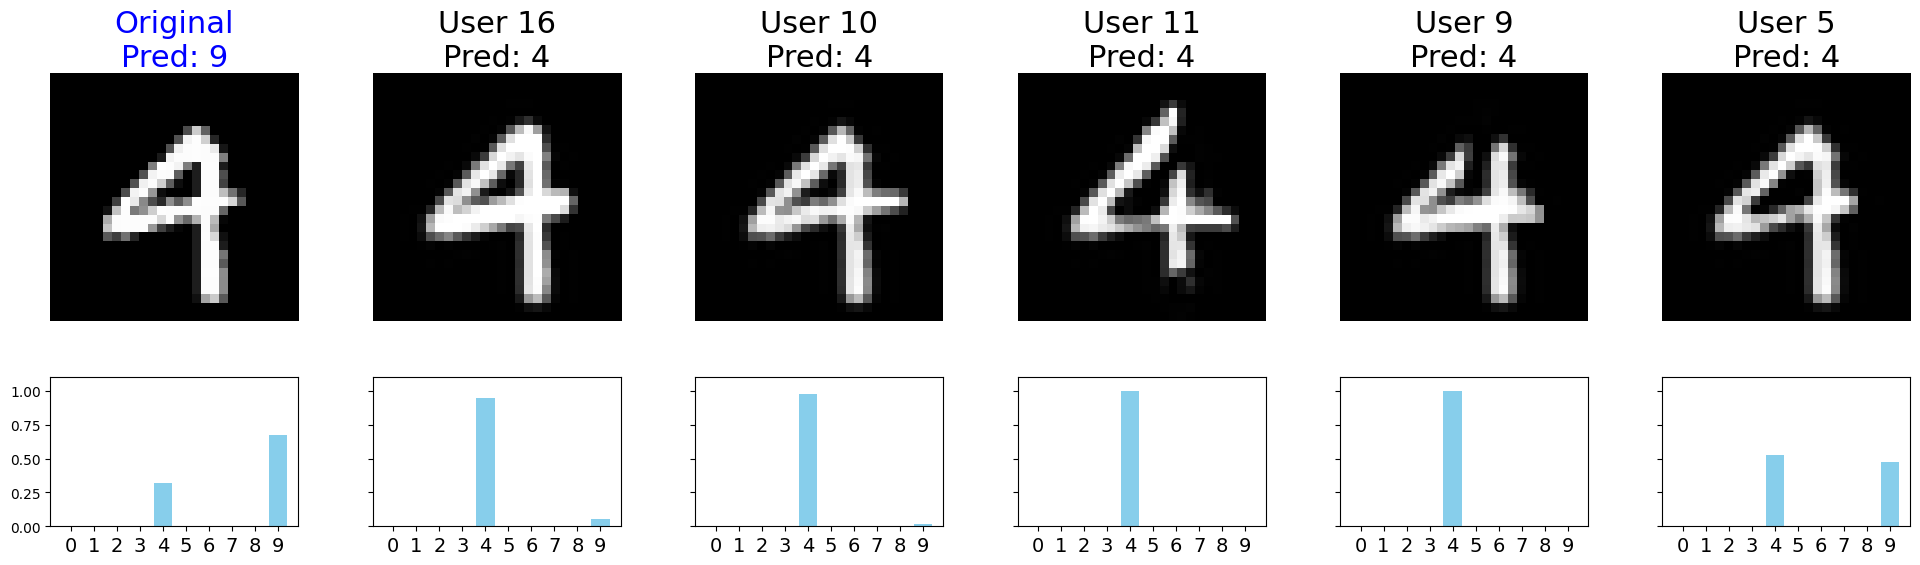

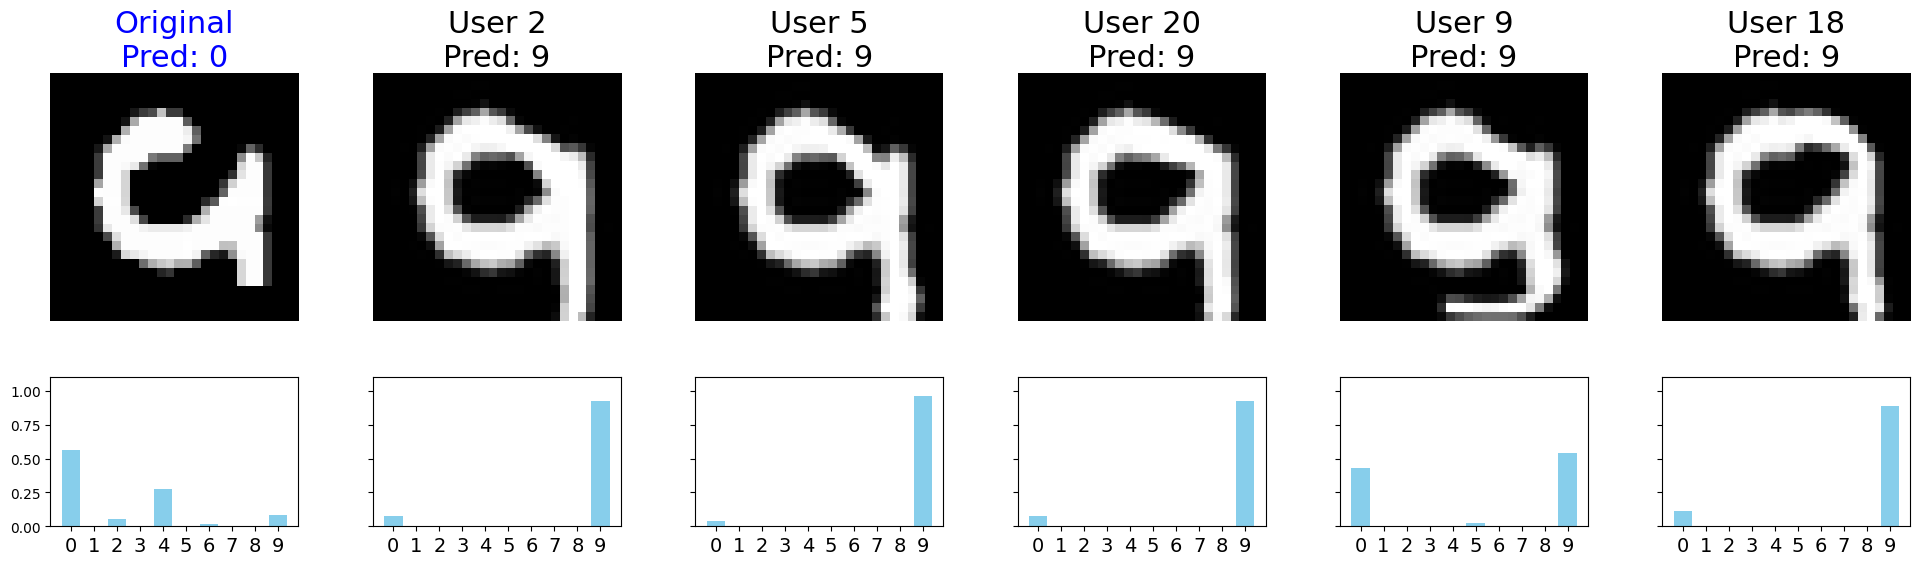

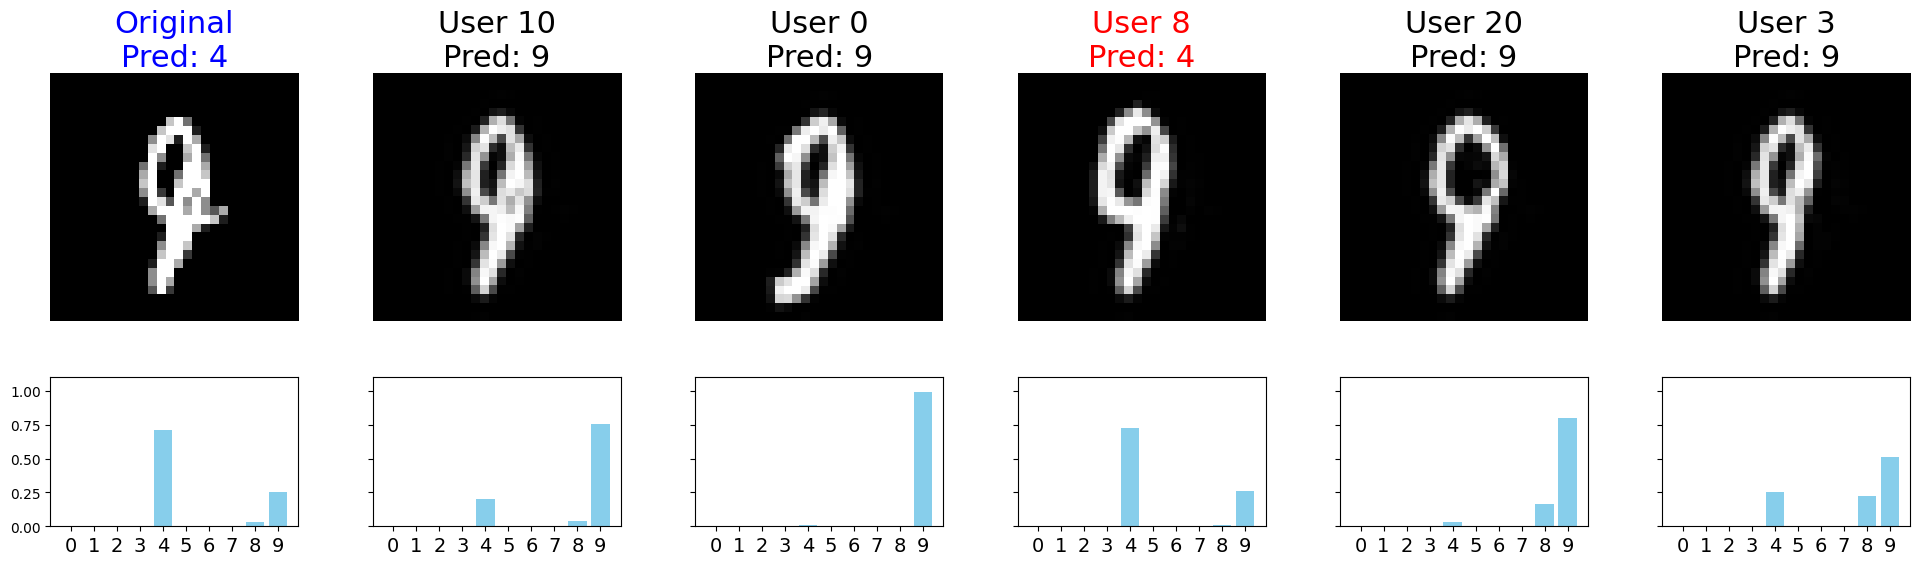

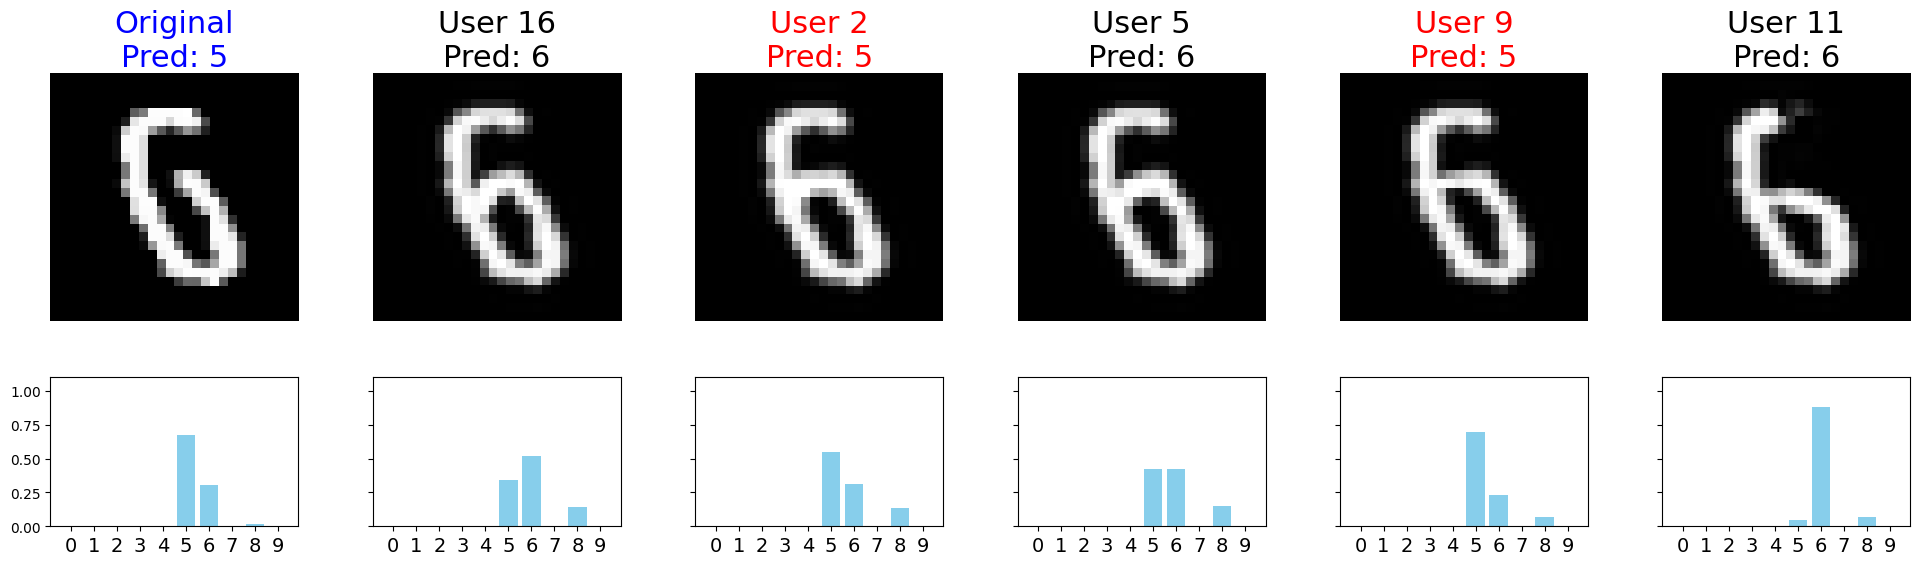

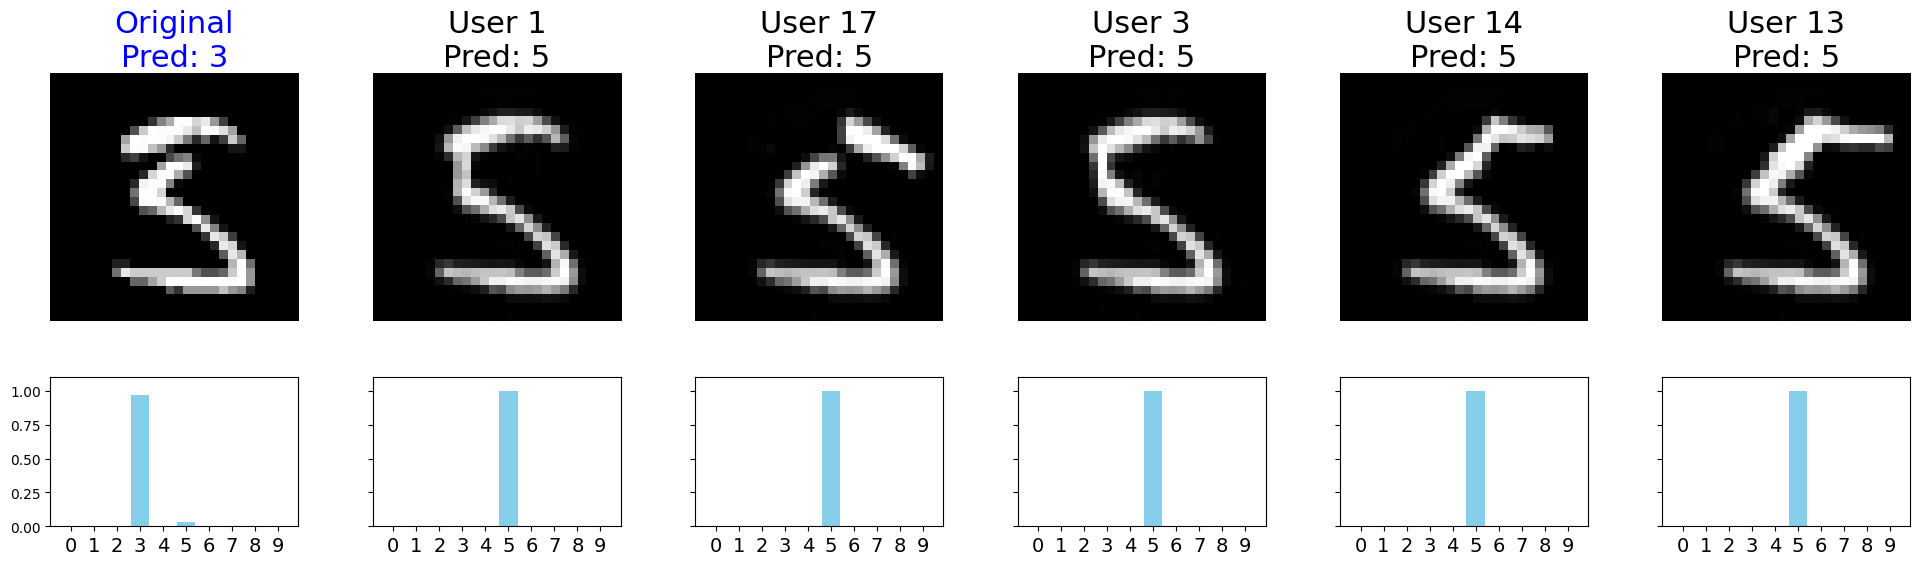

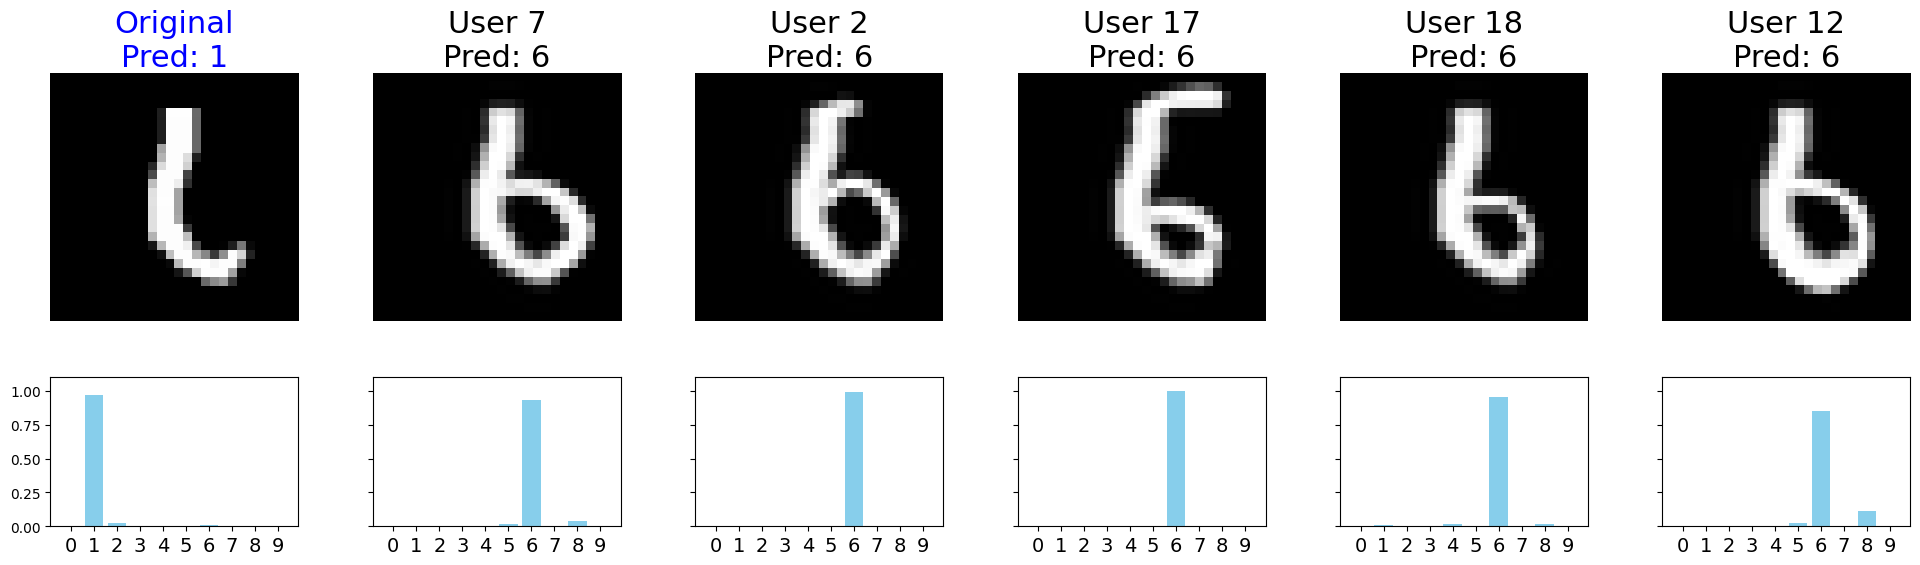

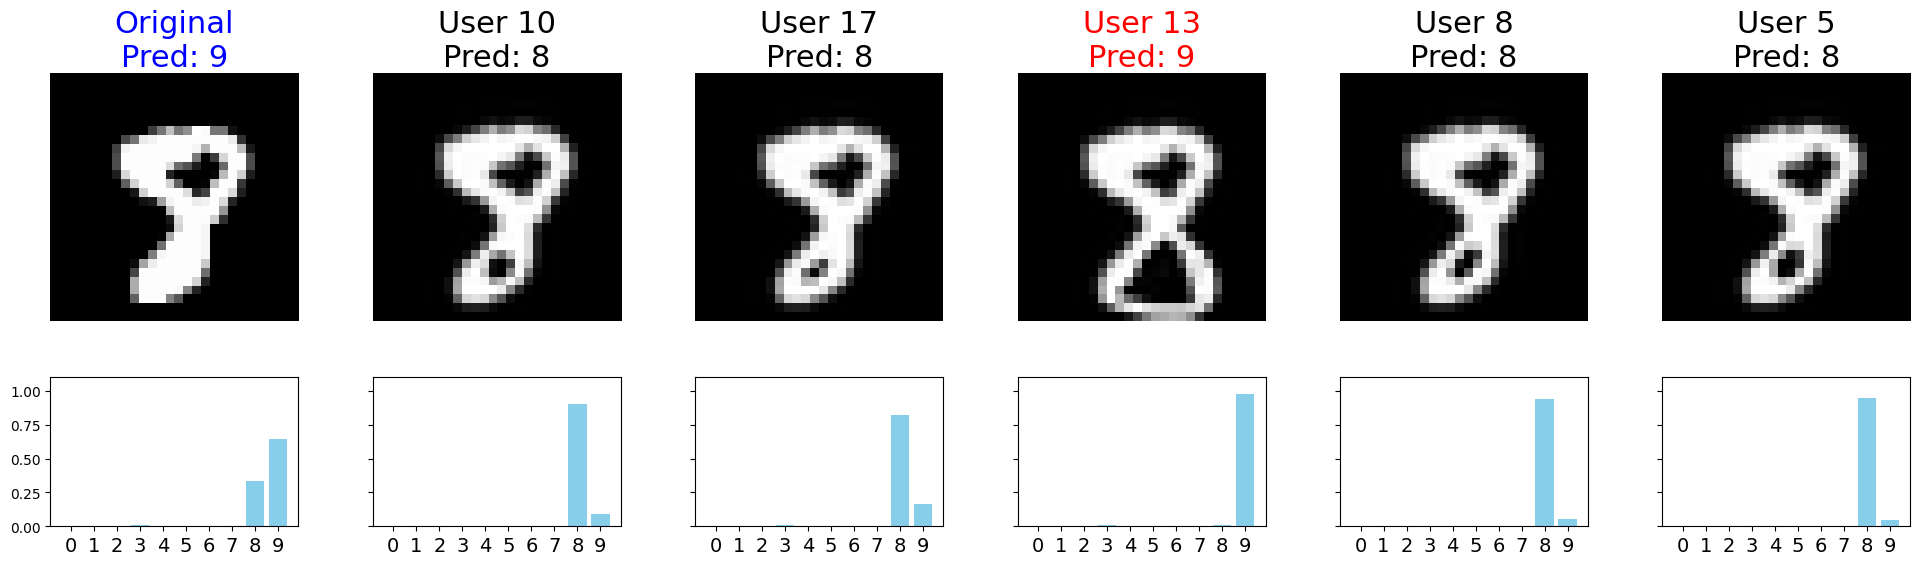

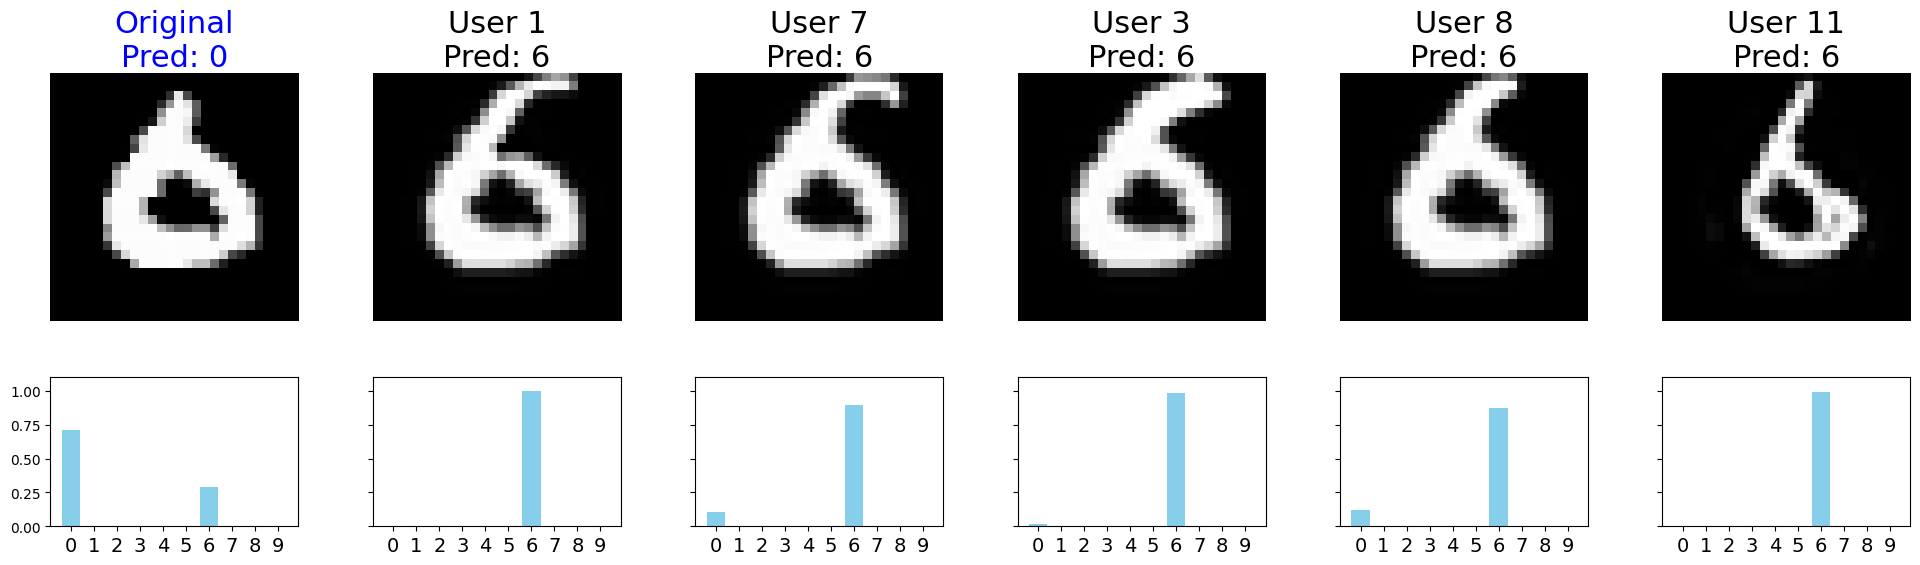

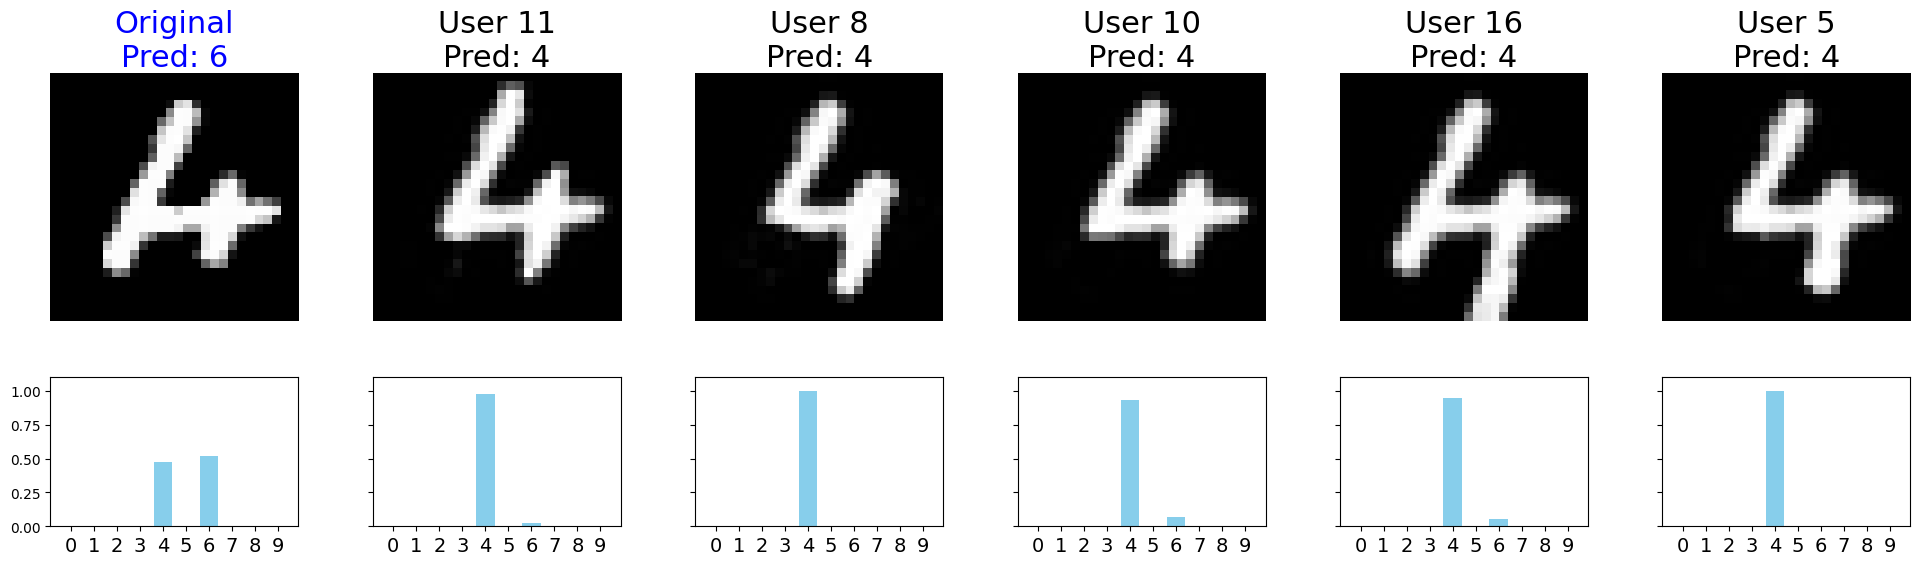

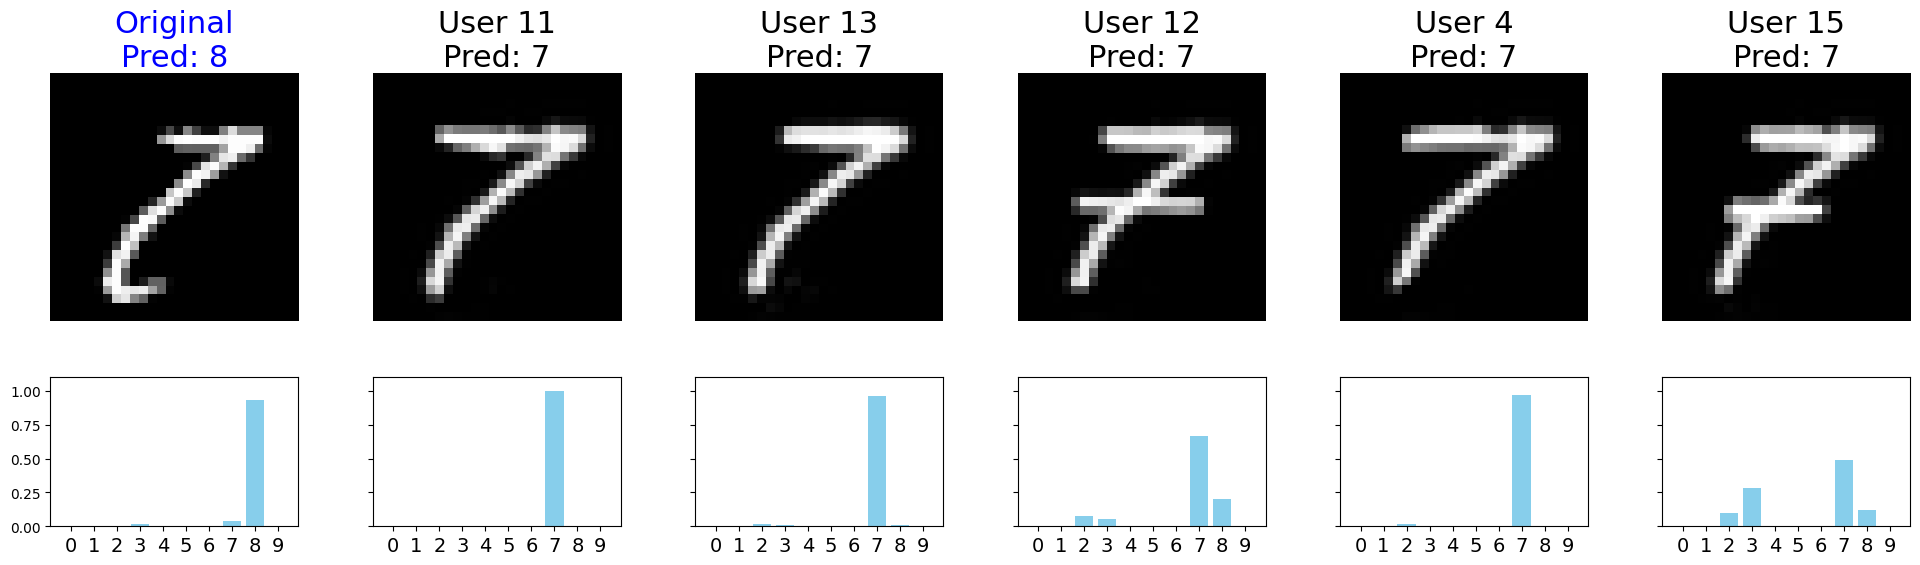

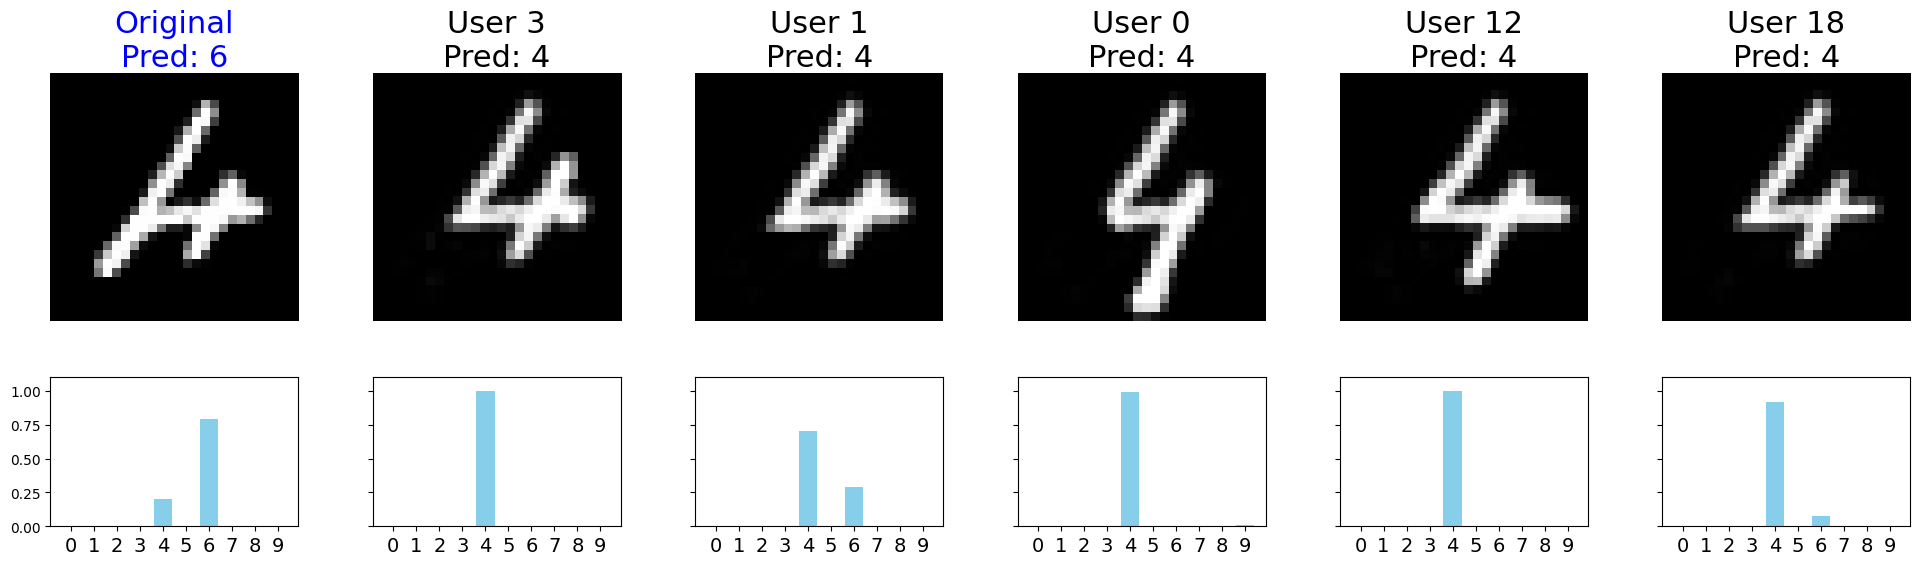

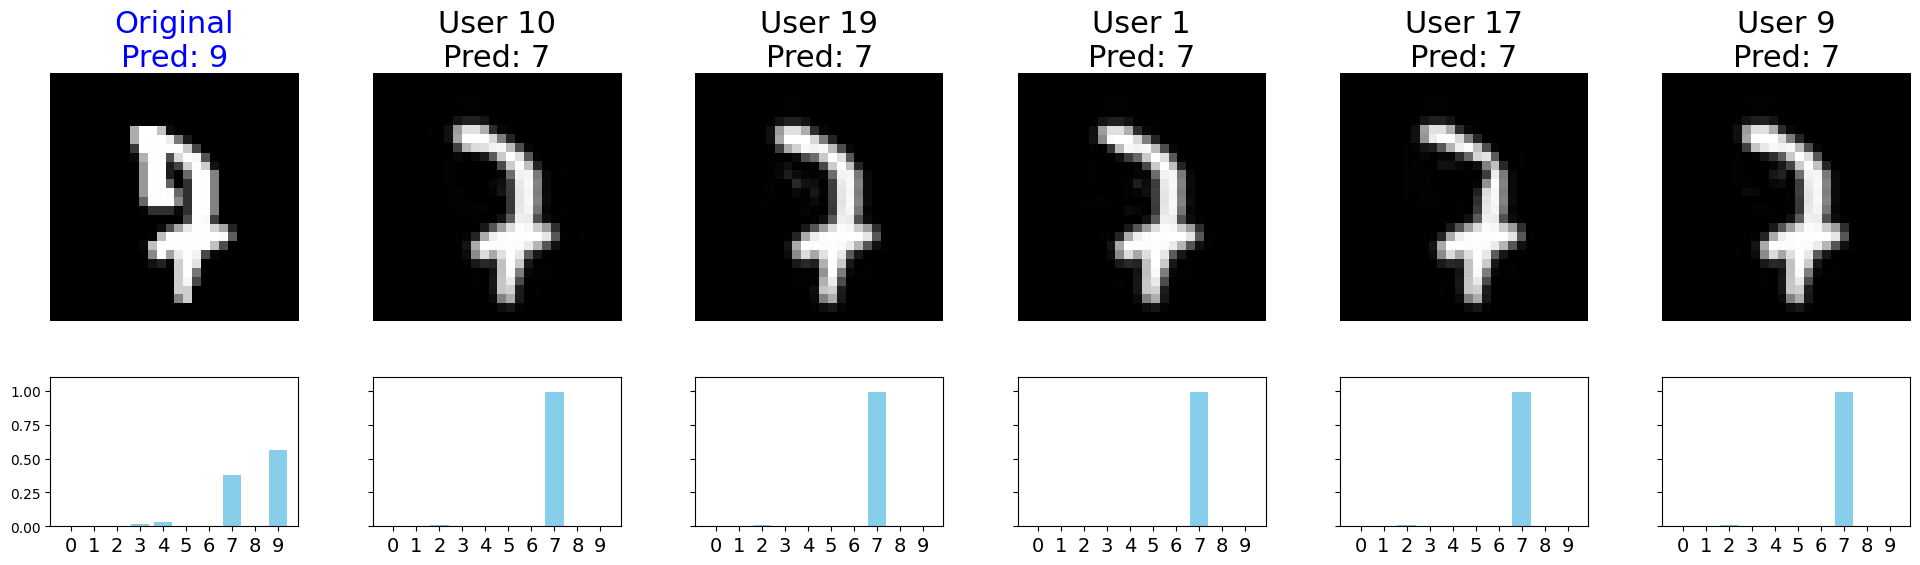

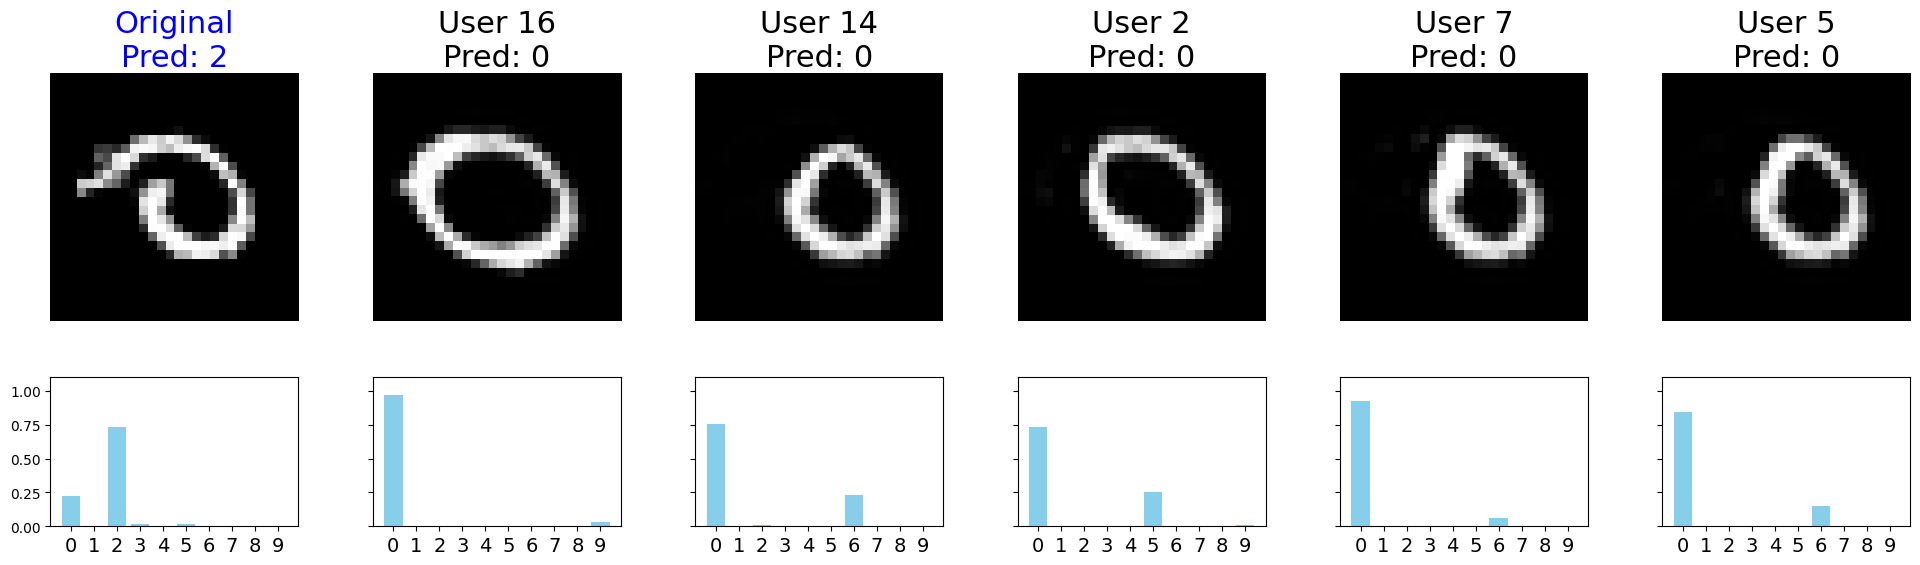

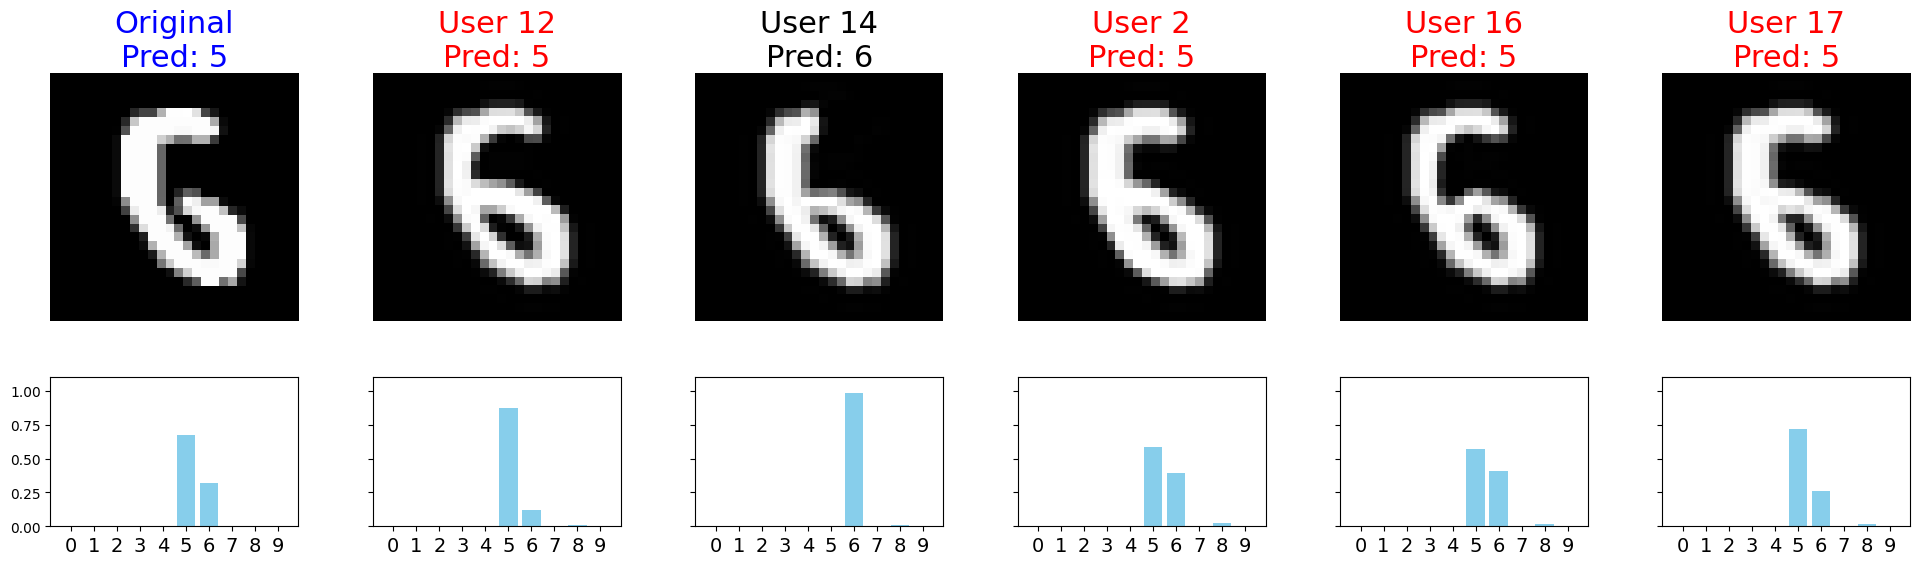

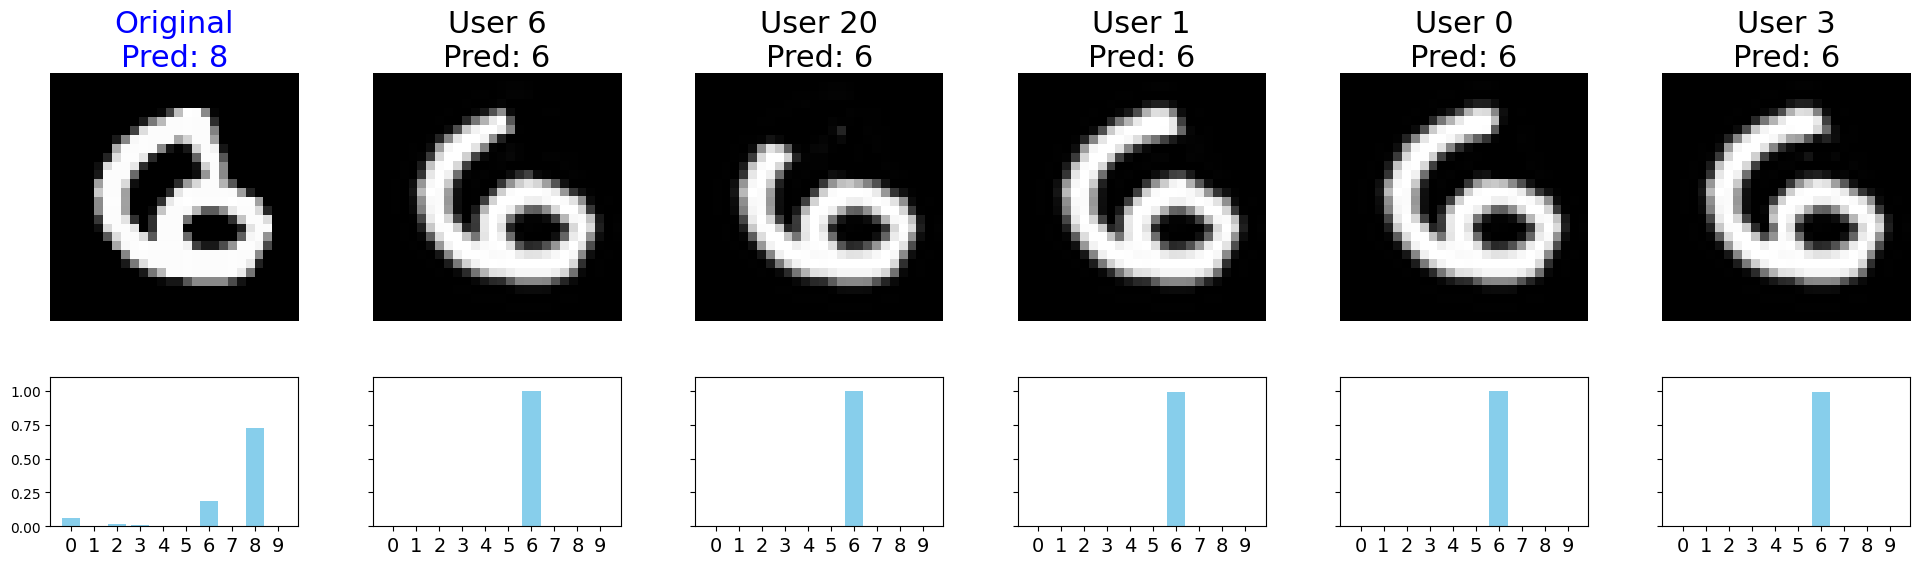

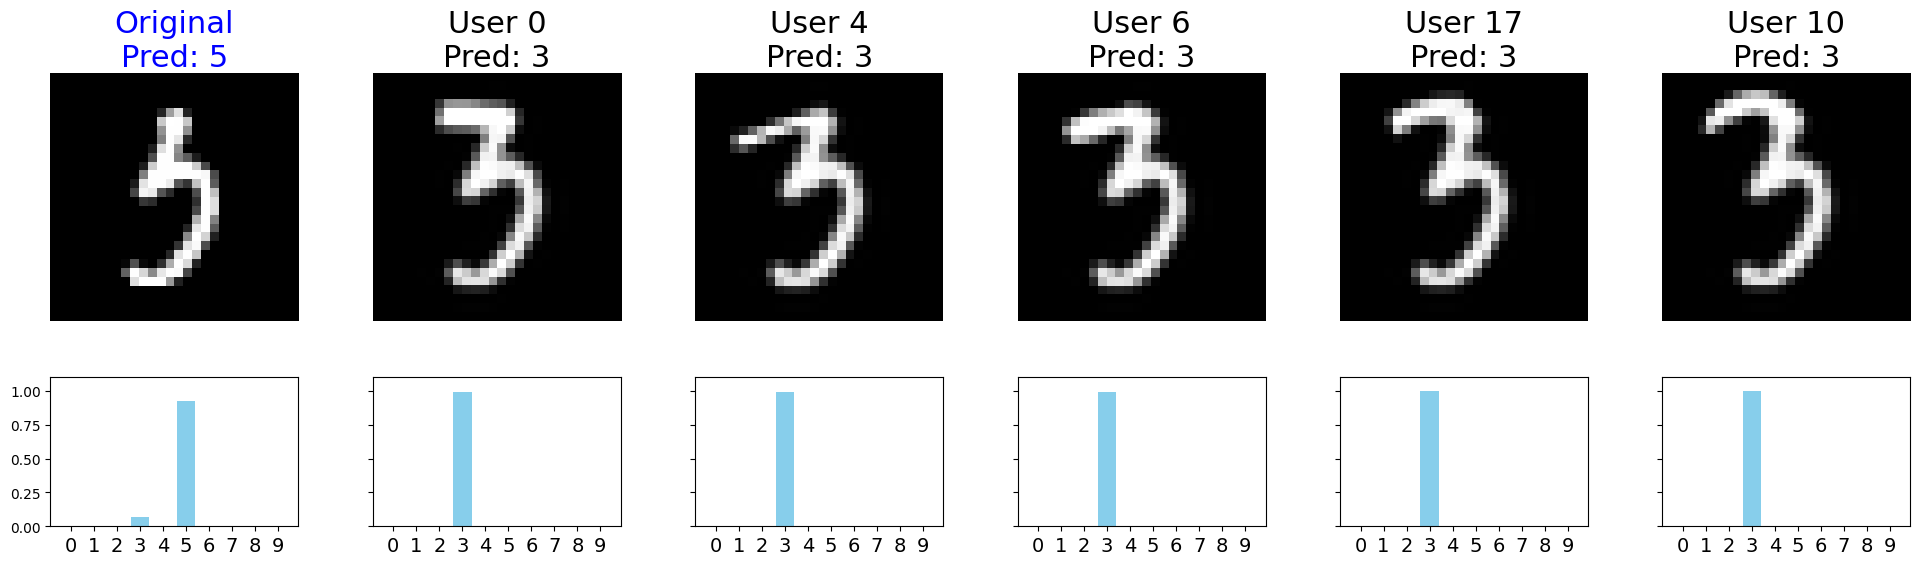

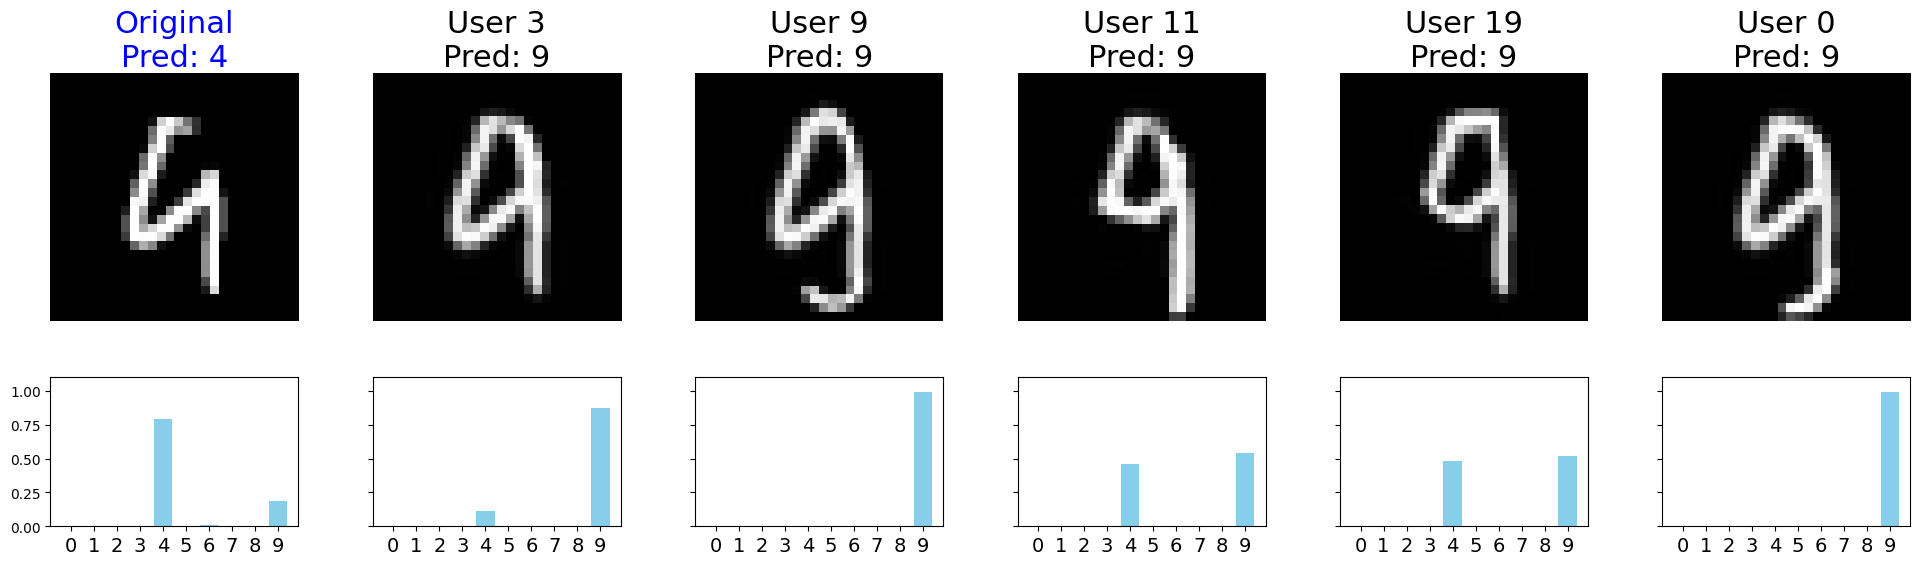

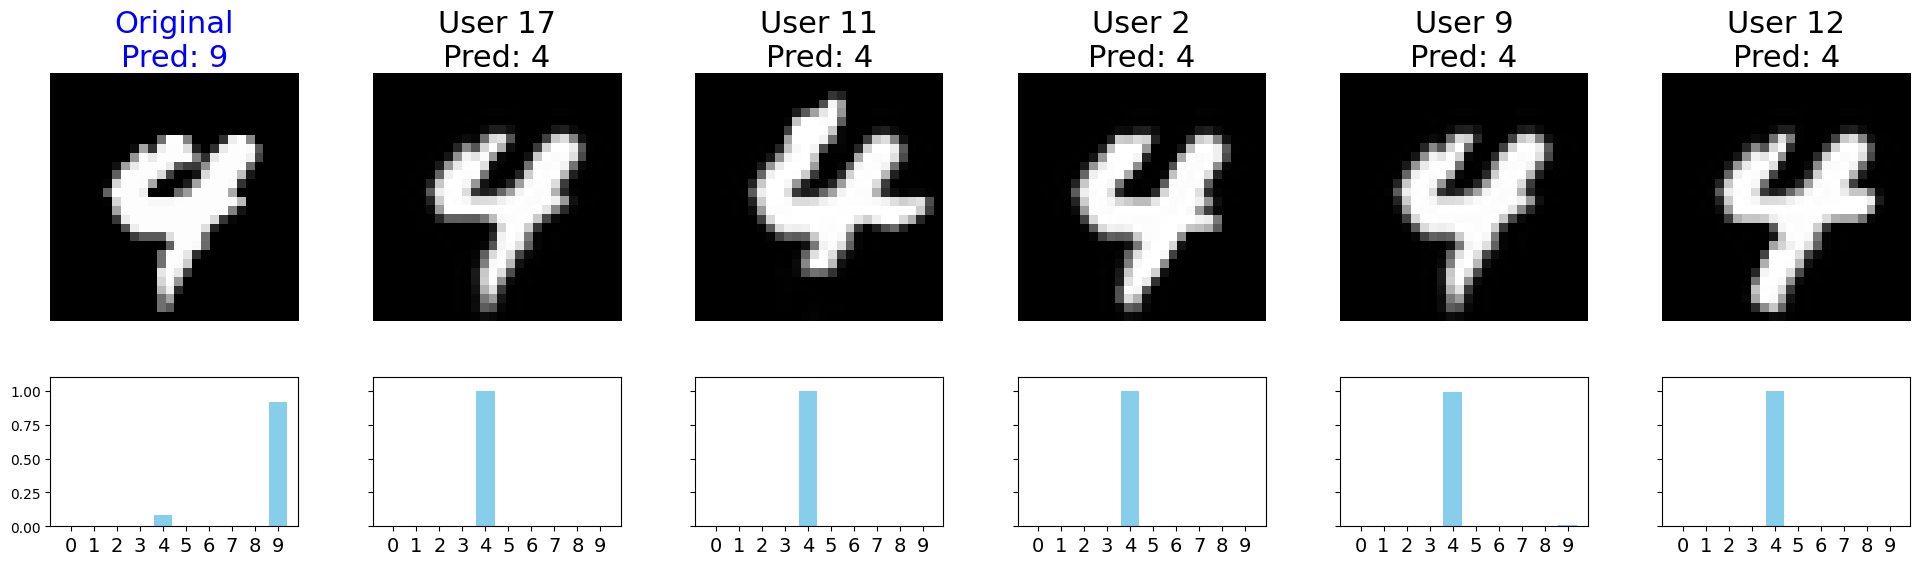

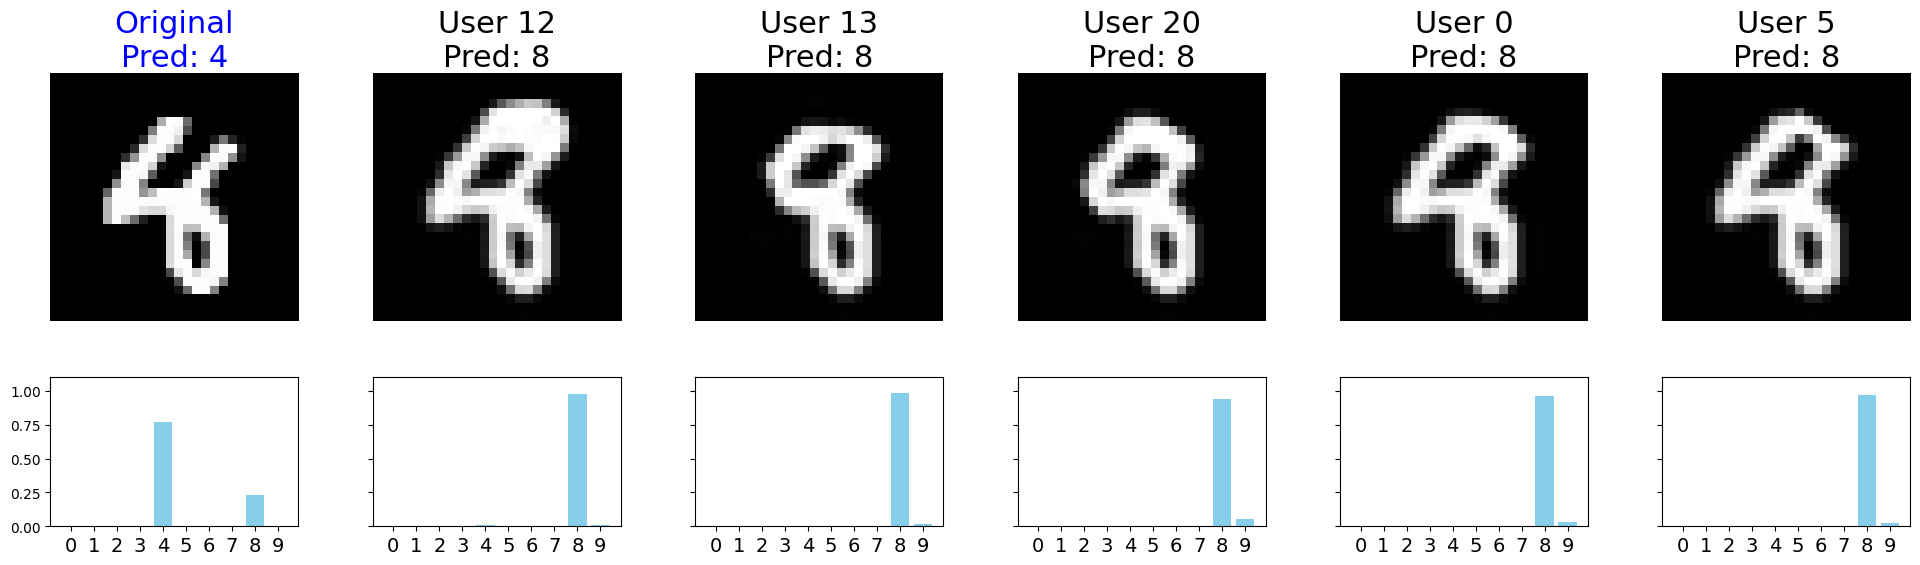

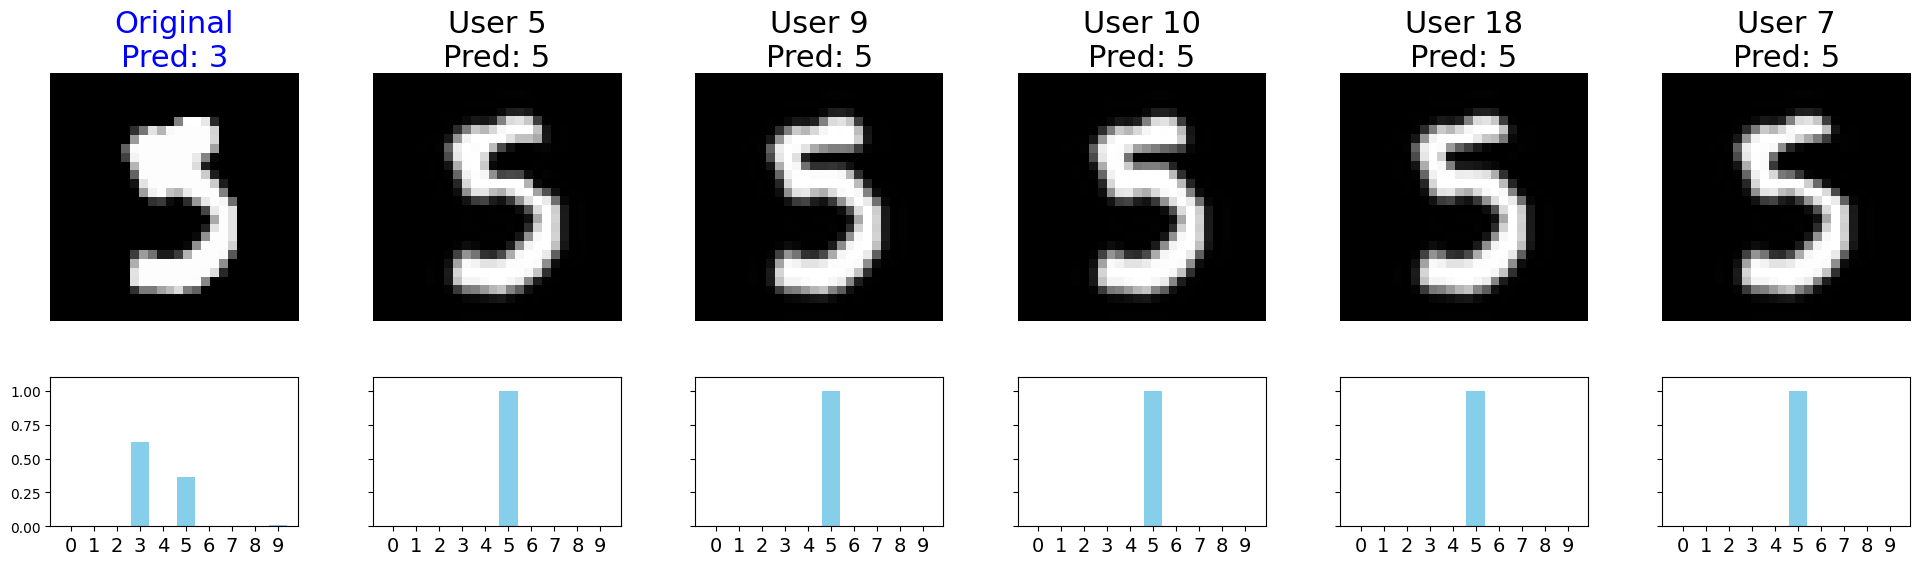

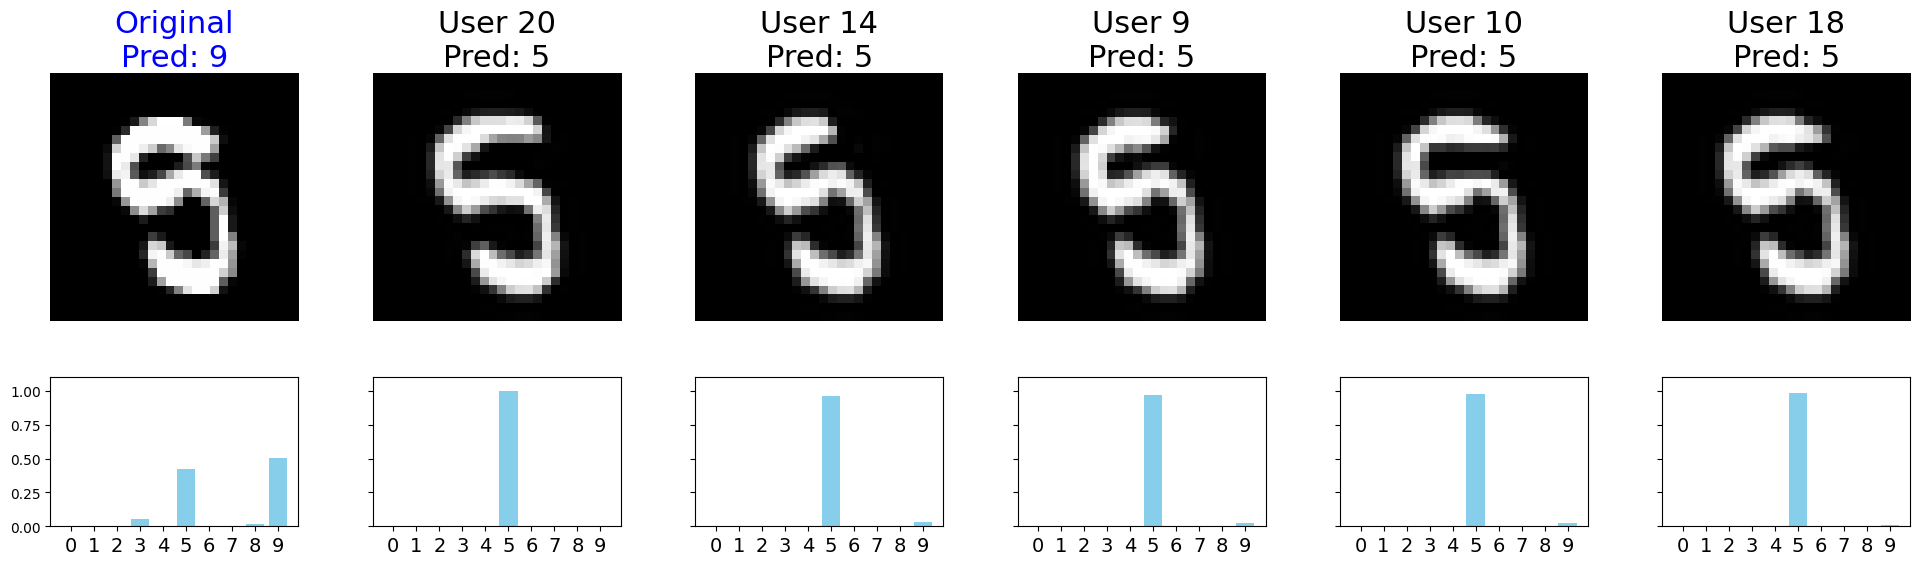

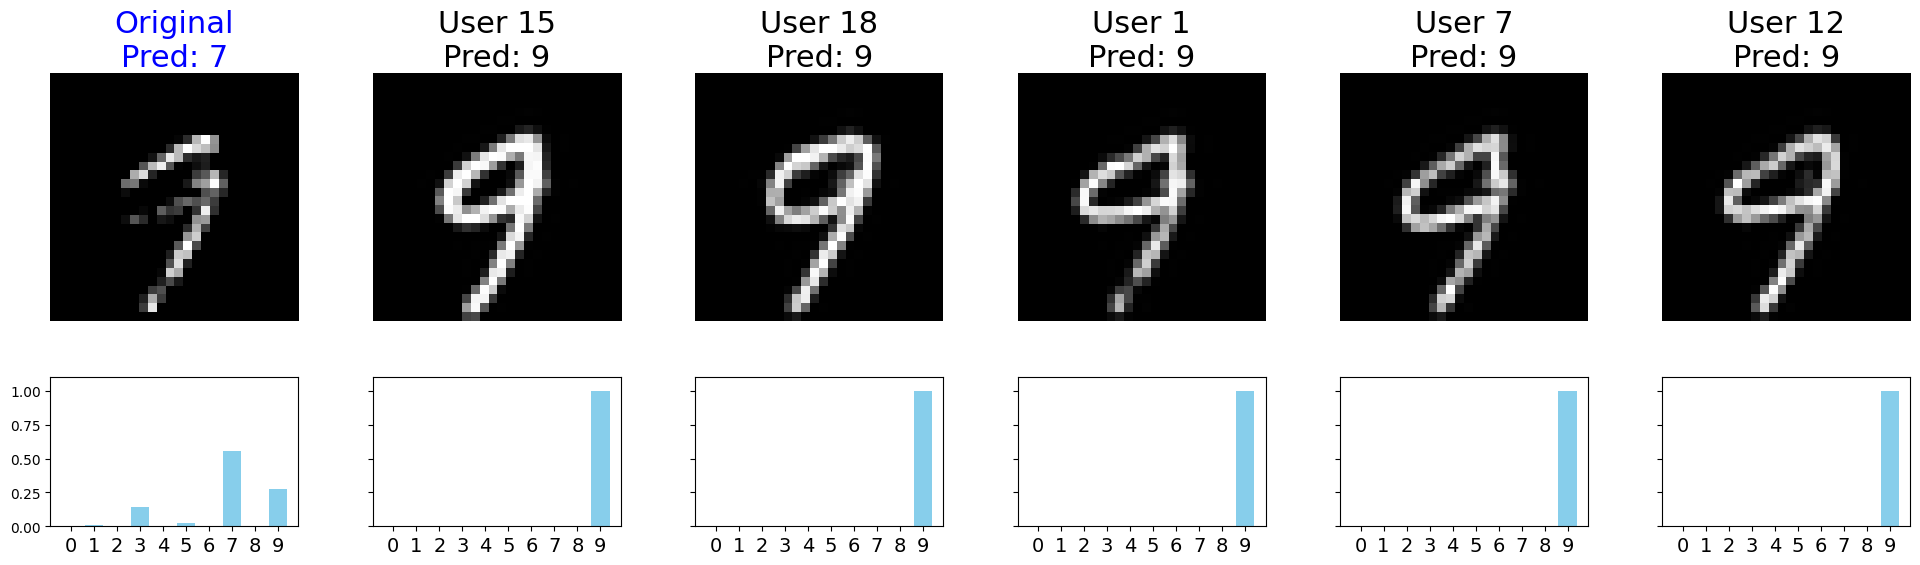

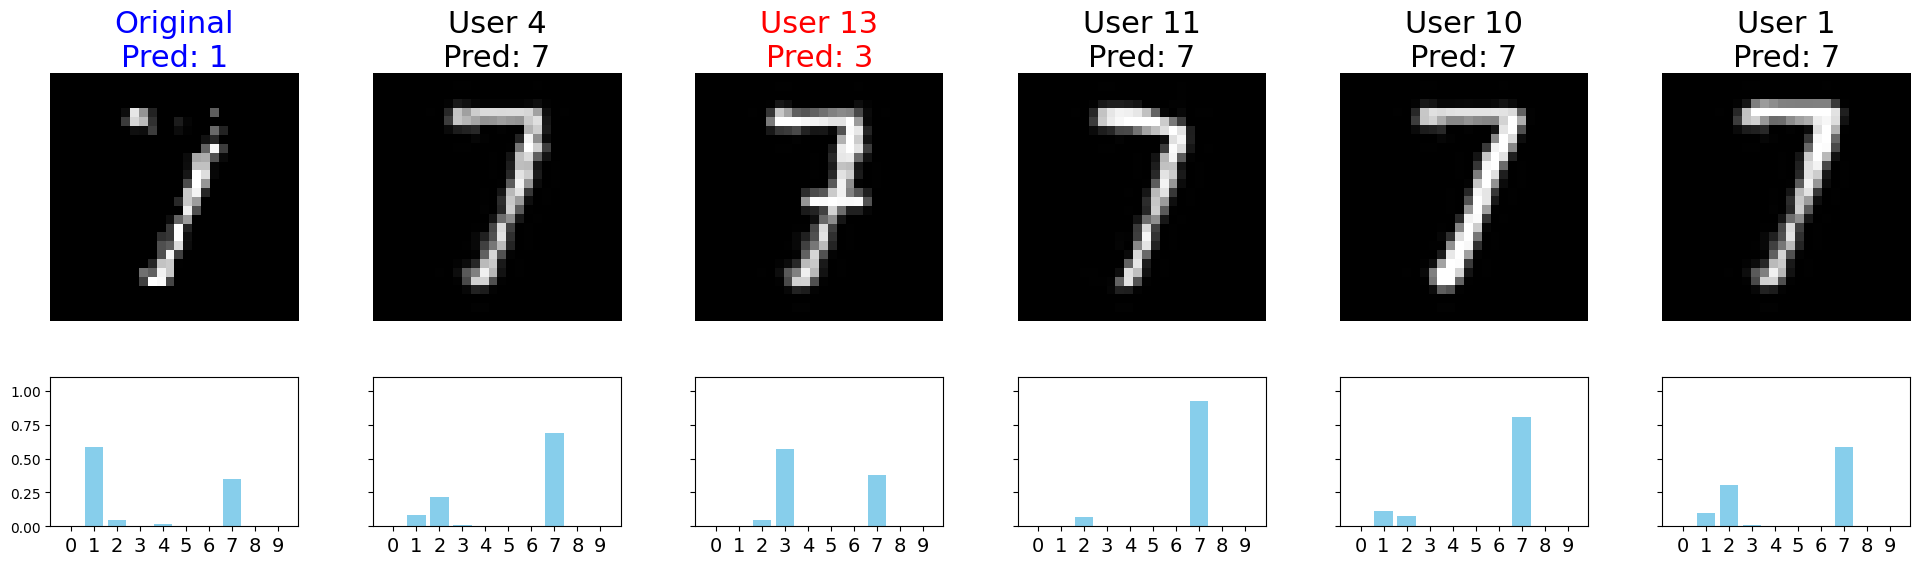

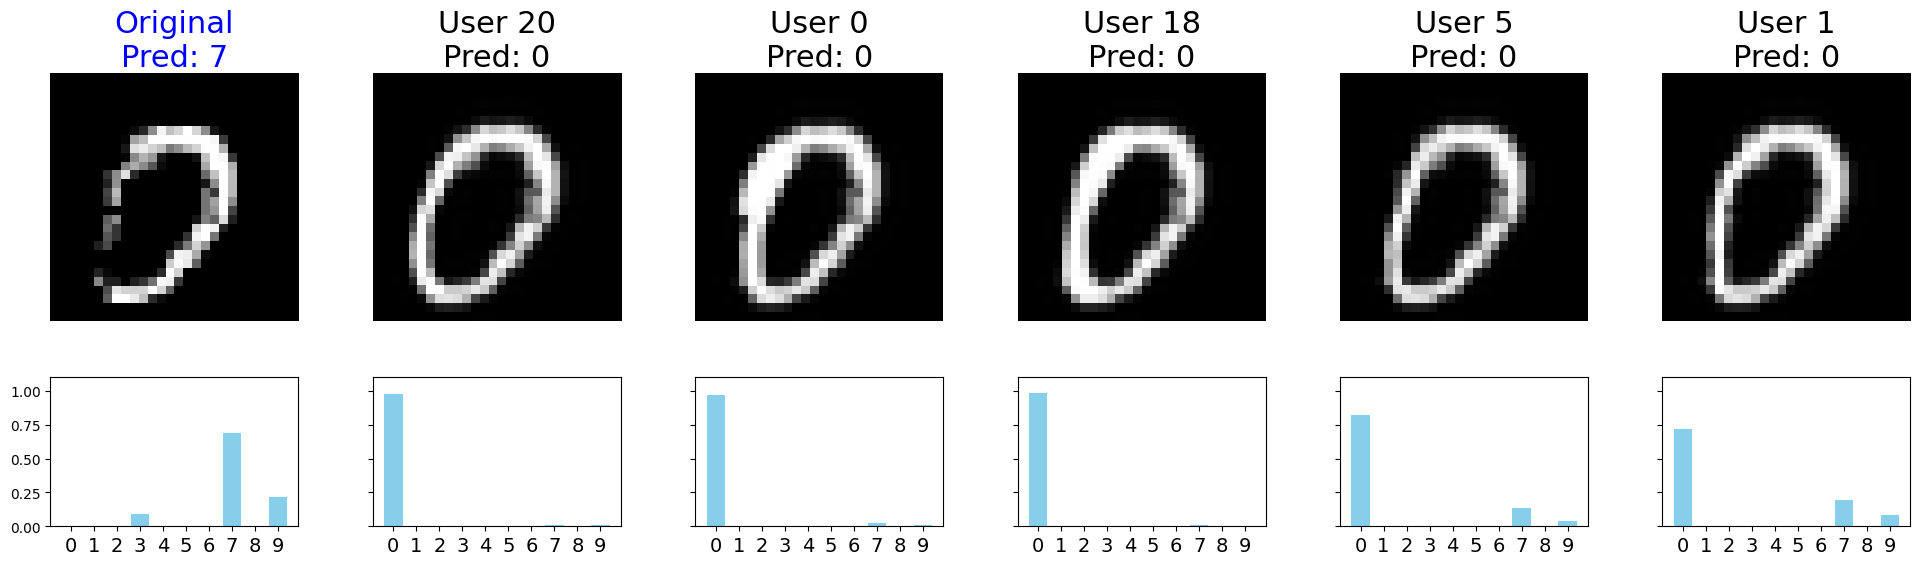

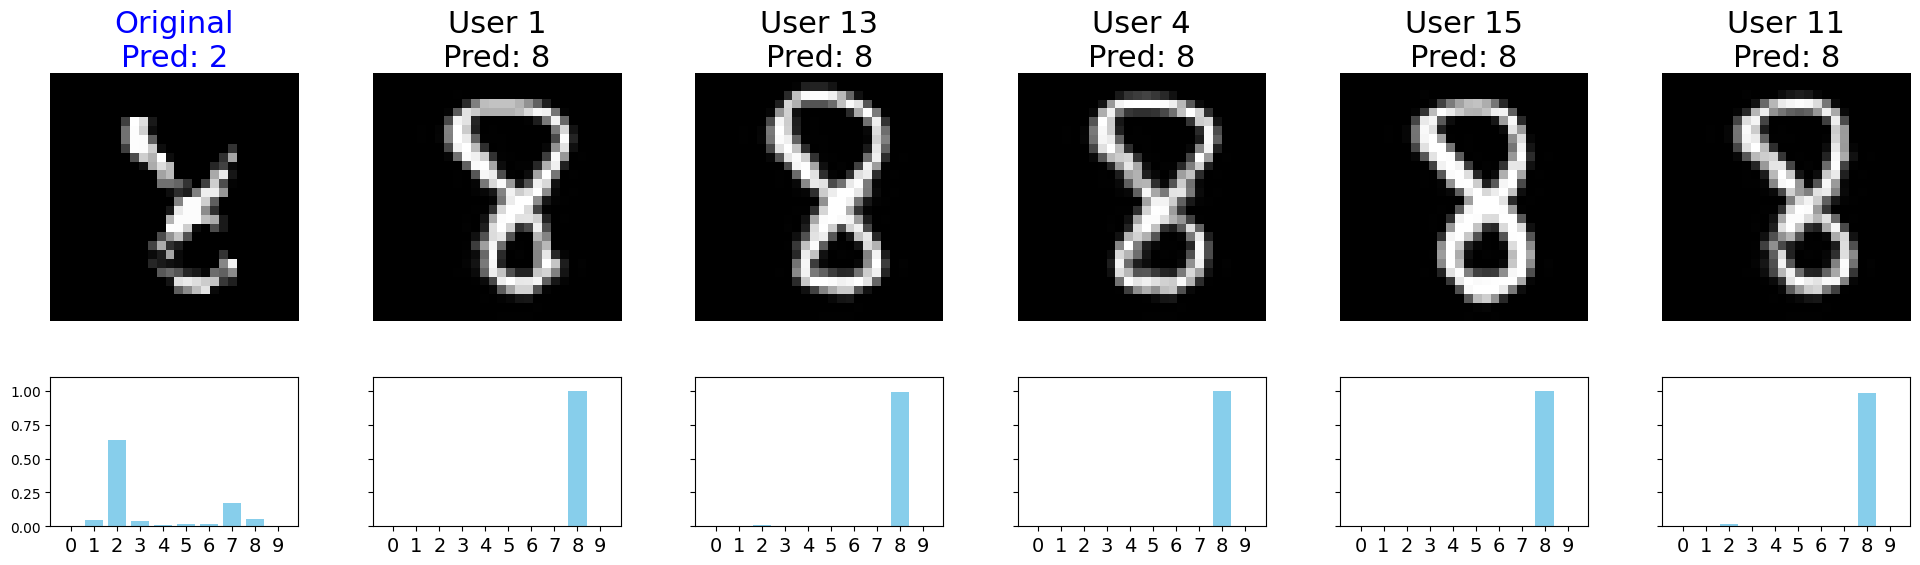

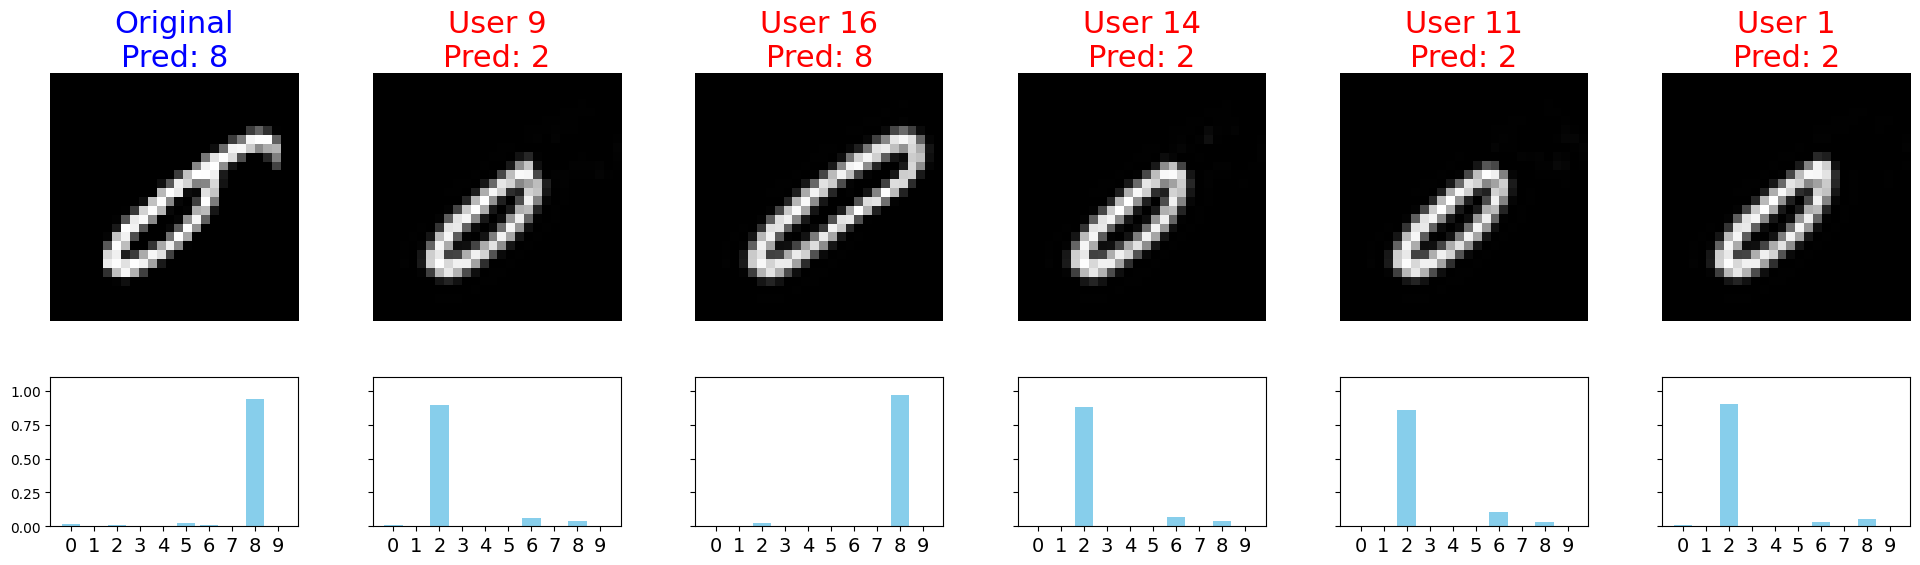

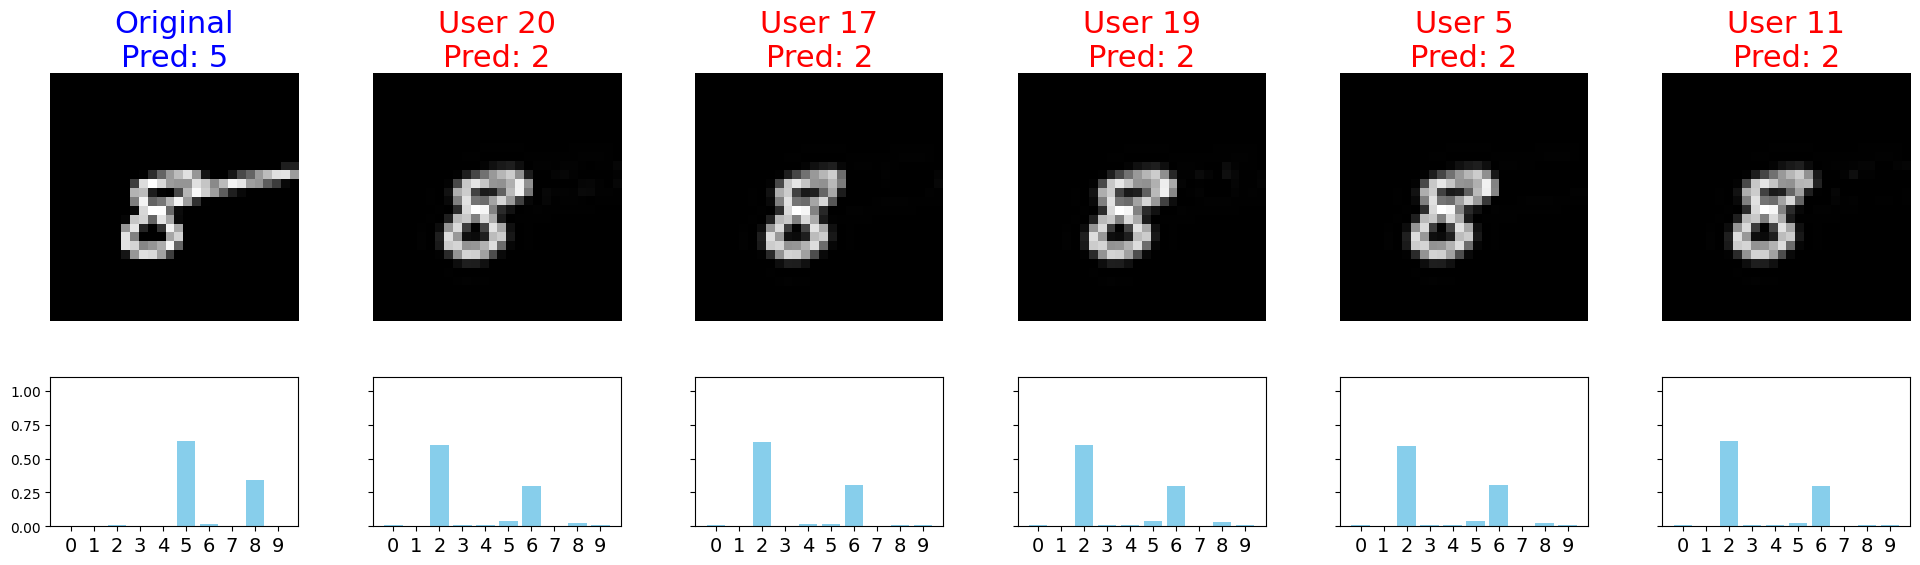

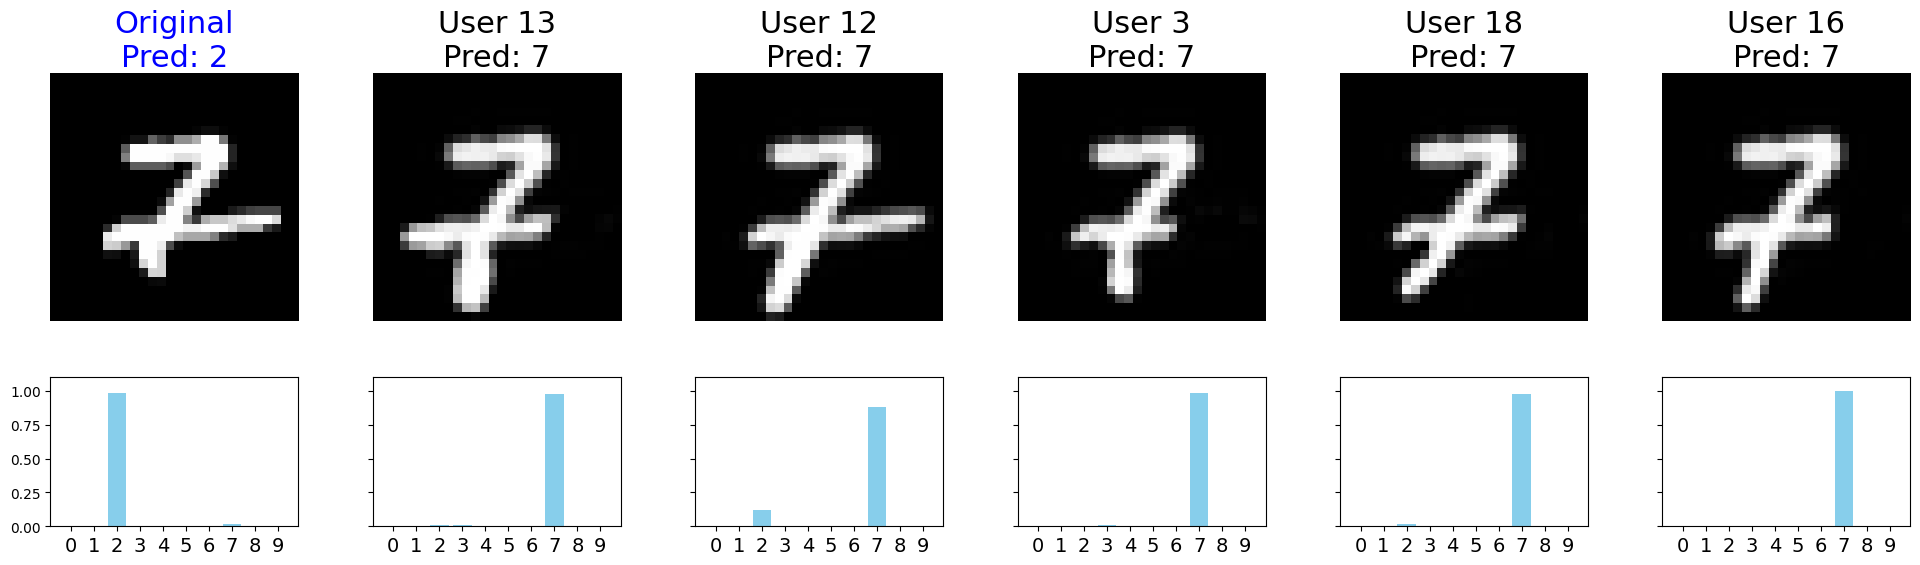

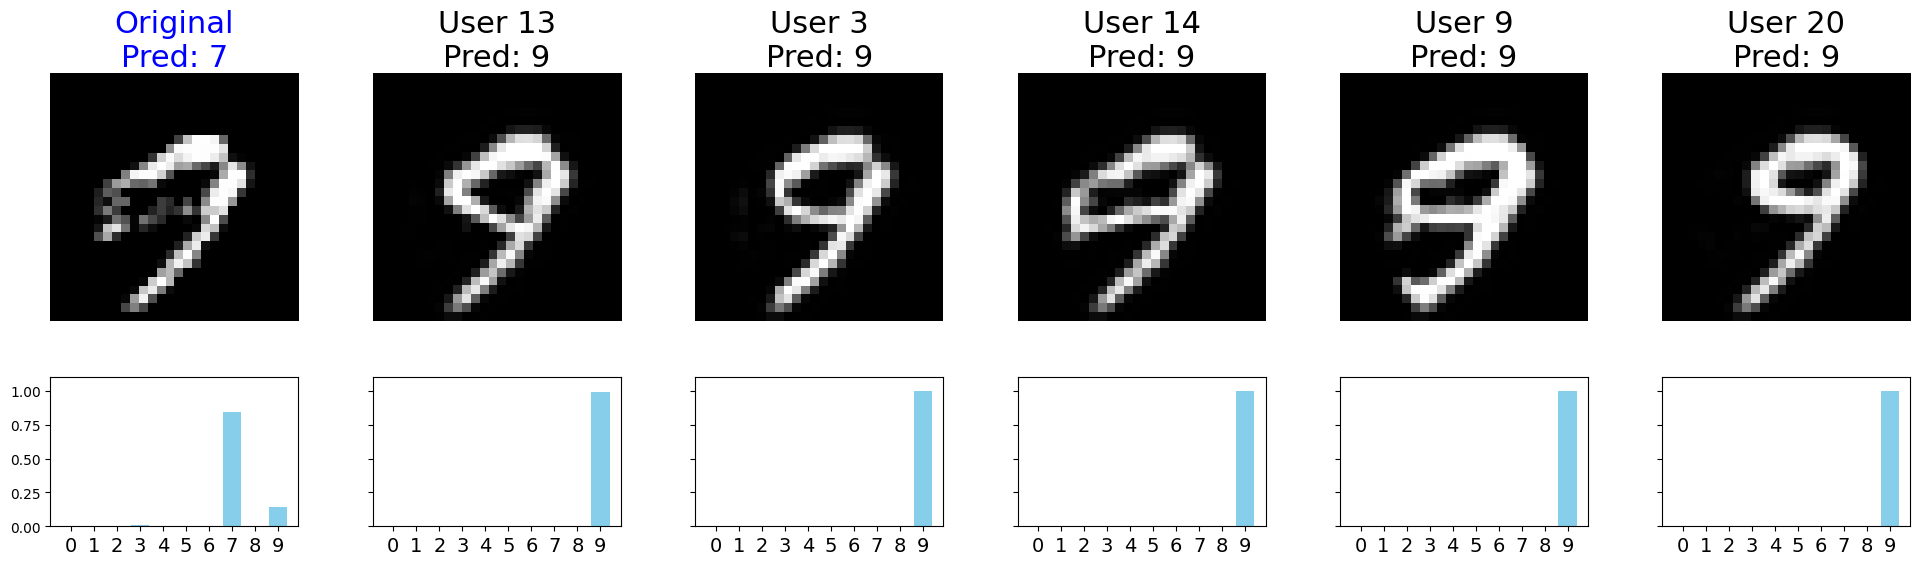

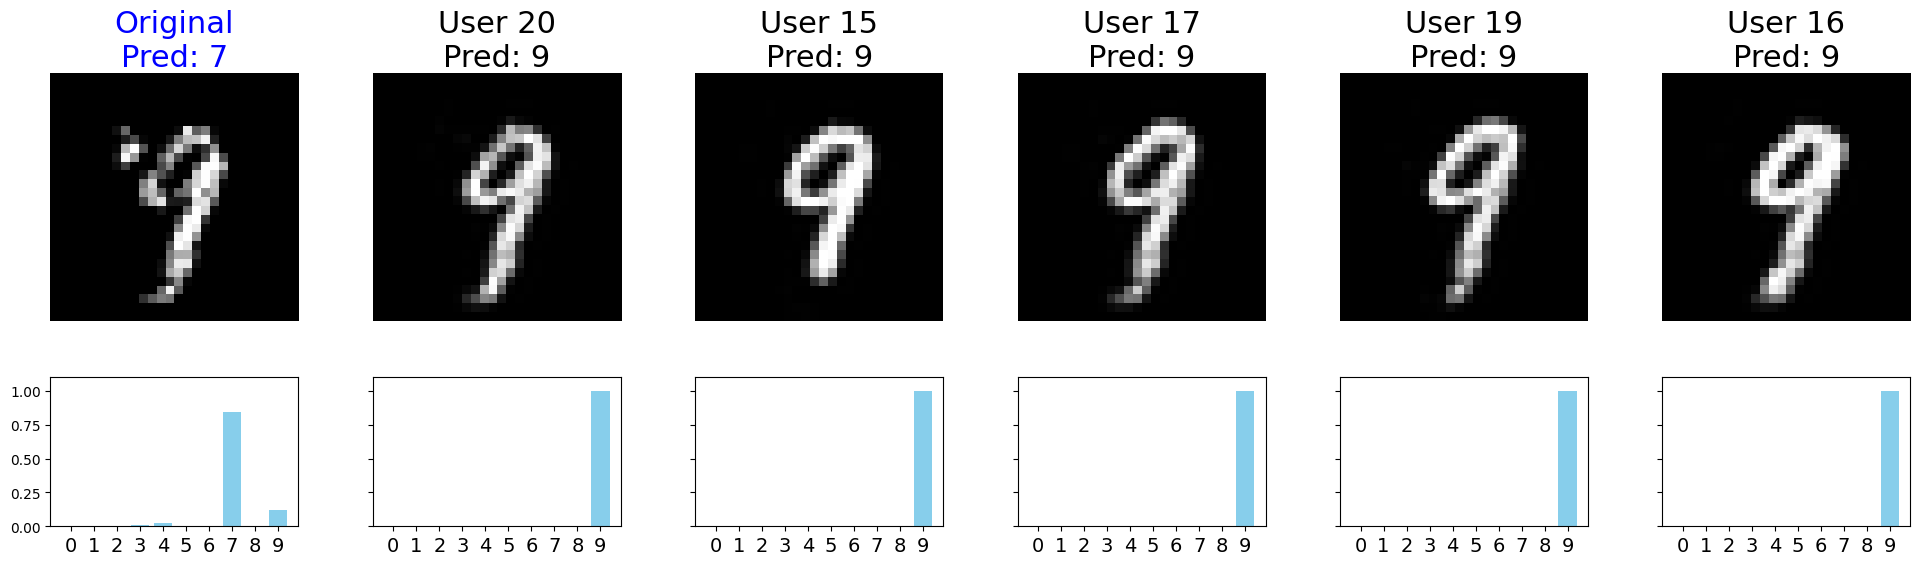

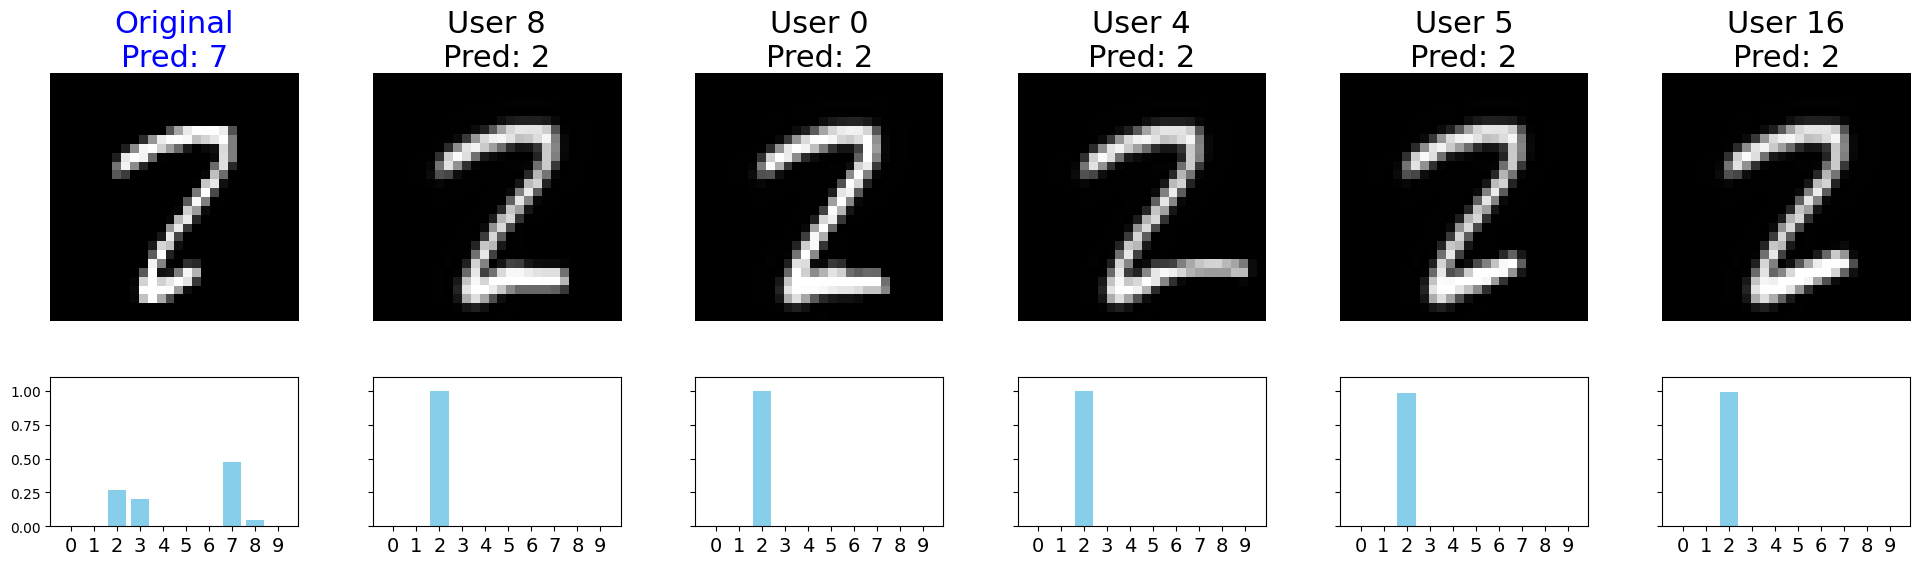

In [211]:
for idx in range(50):
    cf_indices = np.random.choice(21, 5, replace=False)  # 从 0-20 中随机选 5 个用户
    plot_6_columns(idx, cf_indices=cf_indices)

### QuickDraw

In [103]:
qd_baseline_model = tf.keras.models.load_model('../pretrained_models/cnn_quickdraw_5_classes.h5')
quickdraw_misclassified_image_user_set = np.load('../data/quickdraw_cf/quickdraw_misclassified_image_user_set.npy')
quickdraw_predicted_labels = np.load('../data/quickdraw_cf/quickdraw_predicted_labels.npy')
quickdraw_true_labels = np.load('../data/quickdraw_cf/quickdraw_true_labels.npy')
quickdraw_user_explanations = np.load('../data/quickdraw_cf/user_explanations_quickdraw.npy')
classes_names = ['giraffe', 'mushroom', 'bicycle', 'helicopter', 'pizza']

4th sample shape: (5, 28, 28, 1)


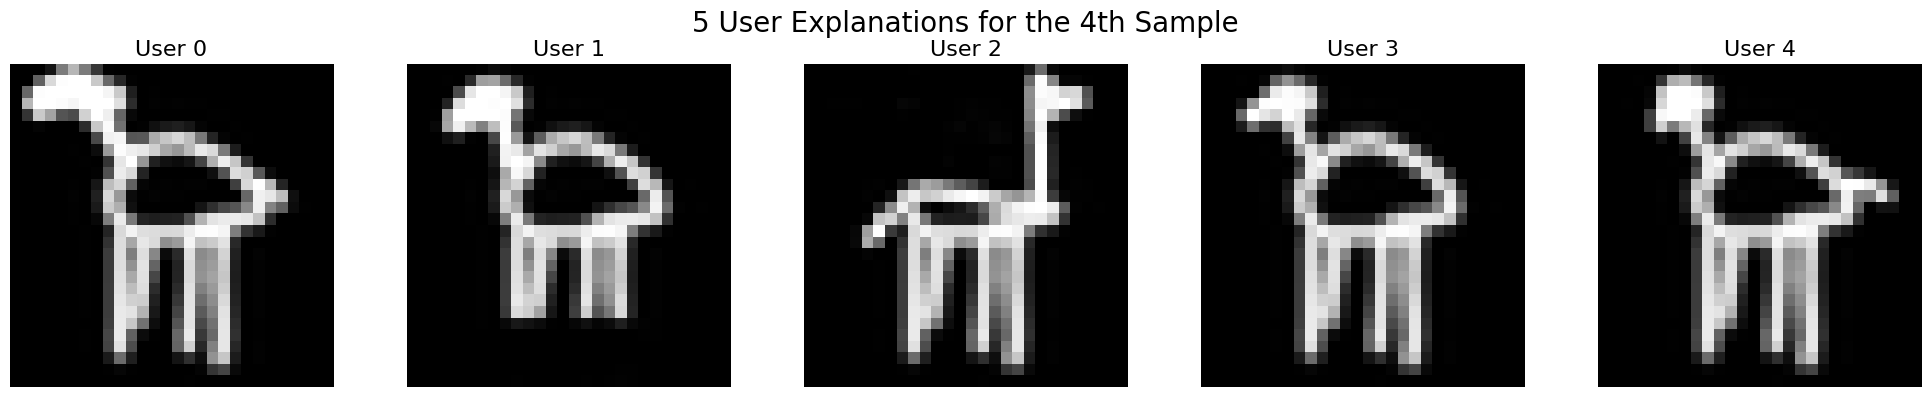

In [142]:
# Plot the 4th sample
fourth_sample = quickdraw_user_explanations[:, 4]
print("4th sample shape:", fourth_sample.shape)
# Plot all these 5 user explanations for the 4th sample
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i in range(5):
    axes[i].imshow(fourth_sample[i], cmap='gray')
    axes[i].set_title(f"User {i}", fontsize=16)
    axes[i].axis('off')
plt.suptitle("5 User Explanations for the 4th Sample", fontsize=20)
plt.tight_layout()
plt.show()

In [438]:
def plot_qd_baseline(img_idx):
    true_label = class_names[quickdraw_true_labels[img_idx]]
    pred_label = class_names[quickdraw_predicted_labels[img_idx]]
    img = quickdraw_user_explanations[0, img_idx] # 取第一个用户的解释作为示例

    fig = plt.figure(figsize=(24, 5.5)) 
    # fig.suptitle(f'Sample {img_idx} | True Label: {true_label}', fontsize=24, y=1.02)

    master_grid = fig.add_gridspec(1, 6, wspace=0.3)

    # 1st column (Original)
    original_img = quickdraw_misclassified_image_user_set[img_idx]
    original_pred_prob = qd_baseline_model.predict(original_img.reshape(1,28,28,1), verbose=0).squeeze()
    original_pred_label = class_names[np.argmax(original_pred_prob)]
    print(f"Pred label from npy: {pred_label}, Pred label from model: {original_pred_label}")

    # 调整 height_ratios，让图片占更多比重 (2.5:1)，这样给 Bar Plot 的原始区域就变扁了
    orig_col = master_grid[0, 0].subgridspec(2, 1, height_ratios=[1.5, 1], hspace=-0.1) # 尝试负 hspace
    
    title_color = 'blue'
    ax_orig_img = fig.add_subplot(orig_col[0])
    ax_orig_img.imshow(original_img, cmap='gray') 
    ax_orig_img.set_title(f"Original\nPred: {original_pred_label}", fontsize=22, pad=5, color=title_color)
    ax_orig_img.set_aspect('equal')
    ax_orig_img.axis('off')
    
    ax_orig_bar = fig.add_subplot(orig_col[1])
    ax_orig_bar.bar(range(len(class_names)), original_pred_prob, color='skyblue')
    ax_orig_bar.set_box_aspect(0.6) # 稍微再调扁一点点
    ax_orig_bar.set_xticks(range(len(class_names))) # 解决你刚才提到的 X 轴显示问题
    ax_orig_bar.set_xticklabels(class_names, rotation=45, fontsize=14, ha='right', rotation_mode='anchor')
    # ax_orig_bar.set_ylabel("Softmax Score")
    ax_orig_bar.set_ylim(0, 1.1)

    # 2th-6th columns
    # 注意：这里有一个逻辑修正，cf_data_list 取出来后，循环内应该用 enumerate 里的 i
    # 否则你的 sample = cf_data_list[cf_idx] 在 cf_idx 很大时会越界
    cf_data_list = quickdraw_user_explanations[:, img_idx]
    
    for i in range(5):
        col_idx = i + 1 
        cf_col = master_grid[0, col_idx].subgridspec(2, 1, height_ratios=[1.5, 1], hspace=-0.1)
        
        sample = cf_data_list[i]
        # cf_idx_val = cf_indices[i]
        
        sample_pred_prob = qd_baseline_model.predict(sample.reshape(1,28,28,1), verbose=0).squeeze()
        sample_pred_label = class_names[np.argmax(sample_pred_prob)]

        title_color = 'red' if sample_pred_label != true_label else 'black'
        ax_cf_img = fig.add_subplot(cf_col[0])
        ax_cf_img.imshow(sample, cmap='gray')
        ax_cf_img.set_title(f"User {i}\nPred: {sample_pred_label}", fontsize=22, pad=5, color=title_color)
        ax_cf_img.set_aspect('equal')
        ax_cf_img.axis('off')

        ax_cf_bar = fig.add_subplot(cf_col[1])
        ax_cf_bar.bar(range(len(class_names)), sample_pred_prob, color='skyblue')
        ax_cf_bar.set_box_aspect(0.6)
        ax_cf_bar.set_xticks(range(len(class_names)))
        ax_cf_bar.set_xticklabels(class_names, rotation=45, fontsize=14, ha='right', rotation_mode='anchor')
        ax_cf_bar.set_yticklabels([]) 
        ax_cf_bar.set_ylim(0, 1.1)

    plt.show()
    plt.close()

Pred label from npy: bicycle, Pred label from model: bicycle


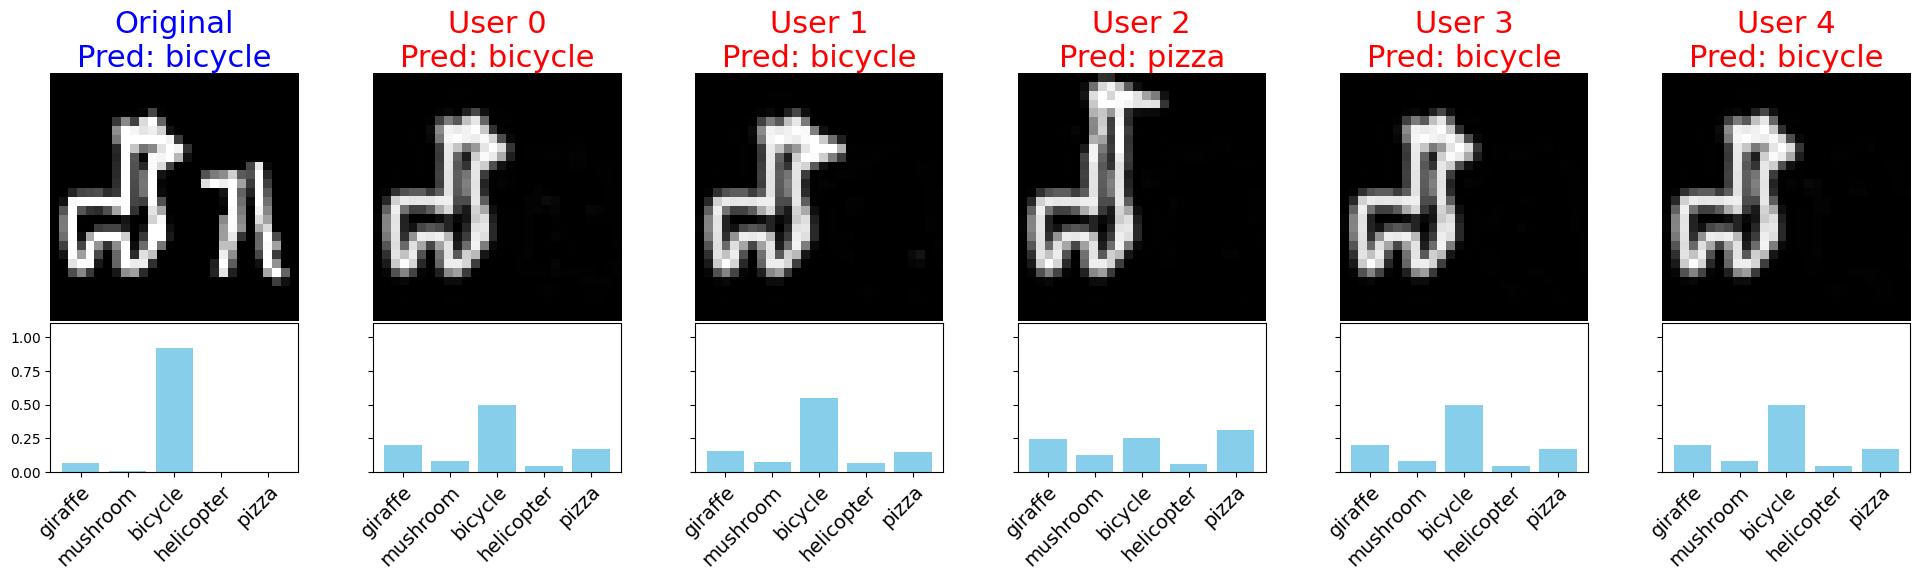

In [439]:
plot_qd_baseline(9)

Pred label from npy: giraffe, Pred label from model: giraffe


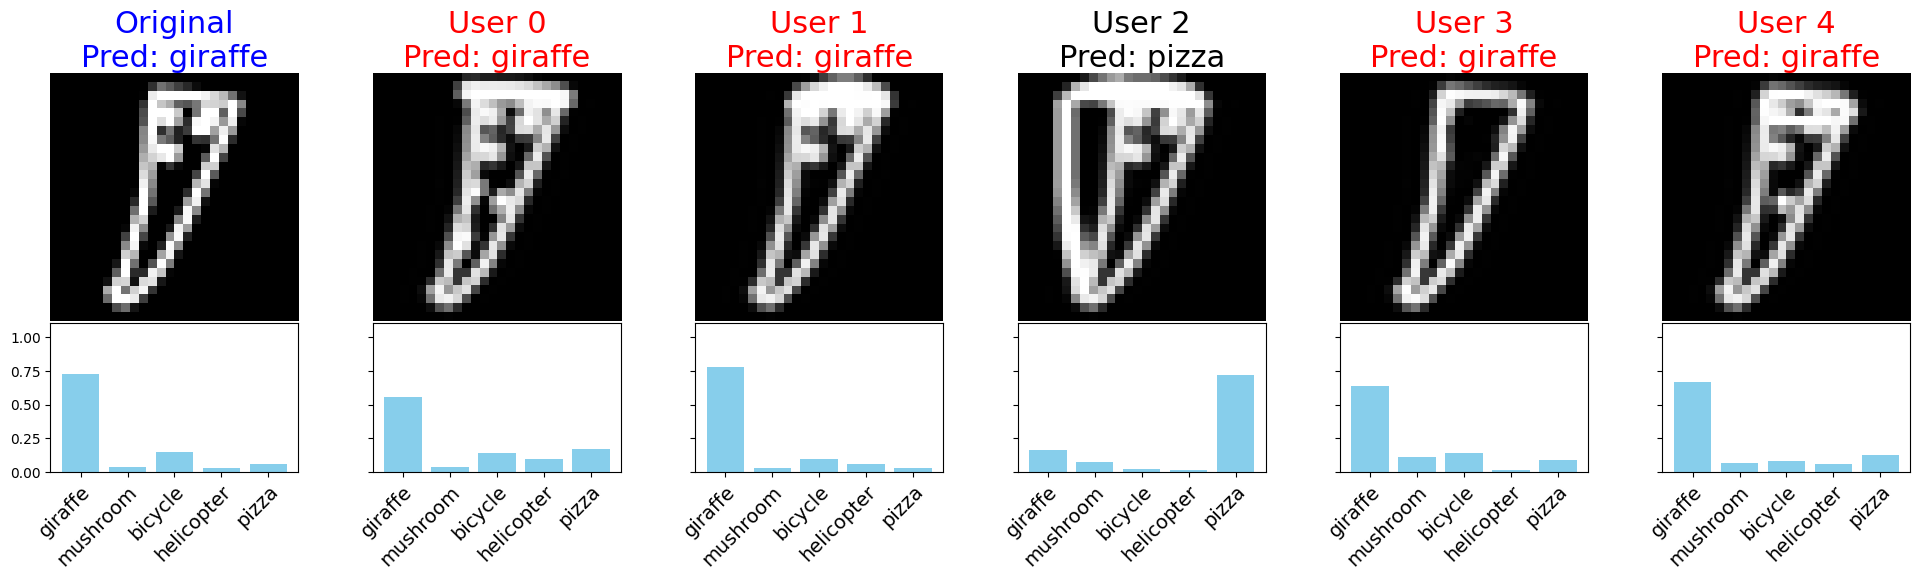

In [440]:
plot_qd_baseline(17)

Pred label from npy: pizza, Pred label from model: pizza


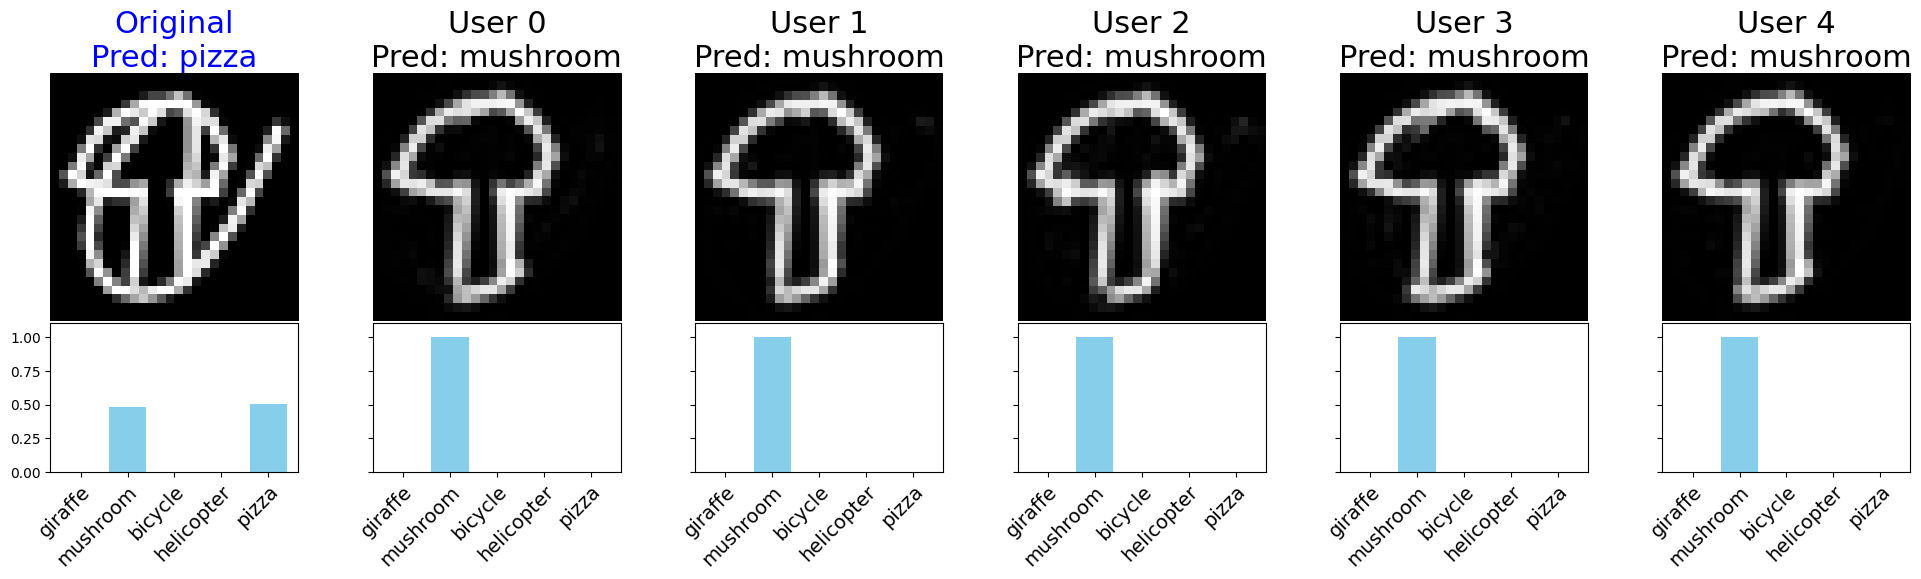

Pred label from npy: mushroom, Pred label from model: mushroom


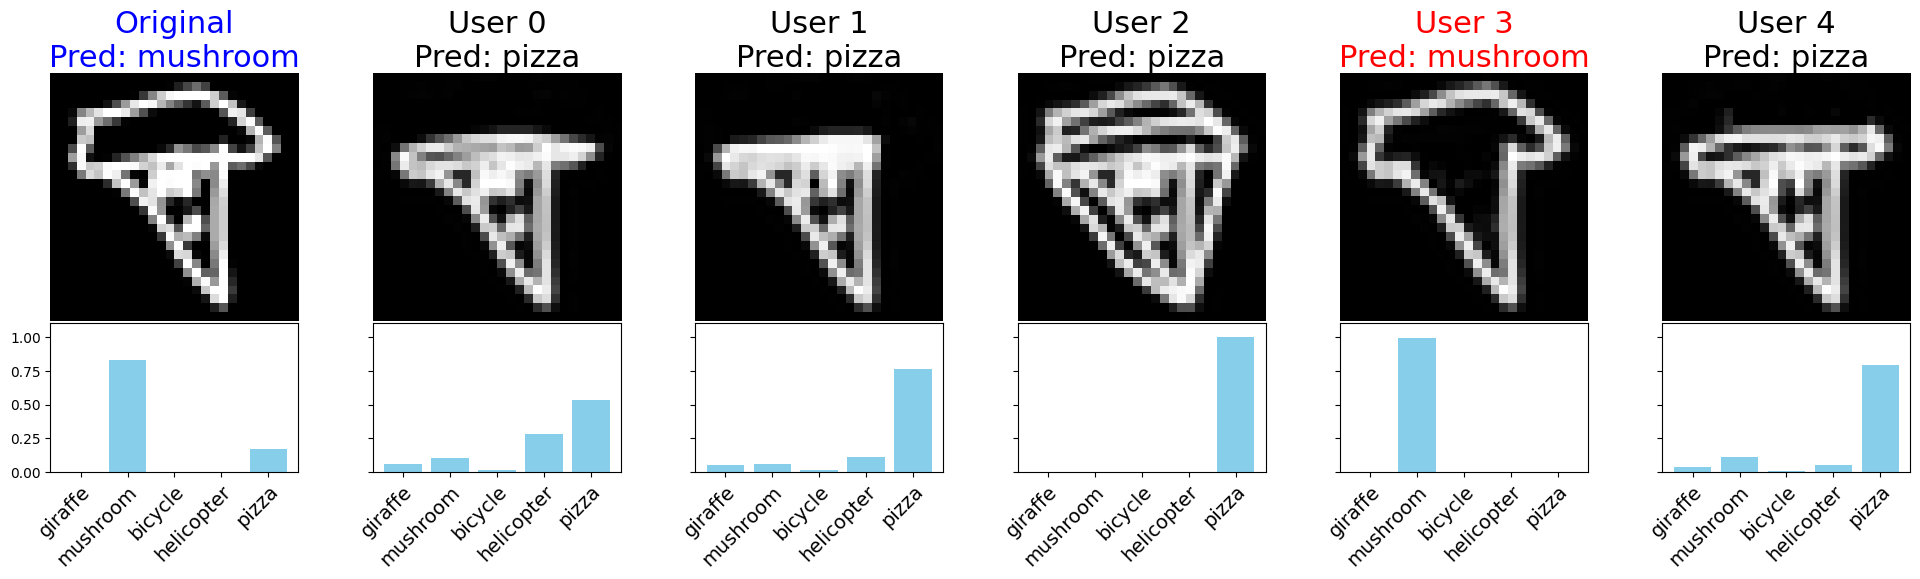

Pred label from npy: helicopter, Pred label from model: helicopter


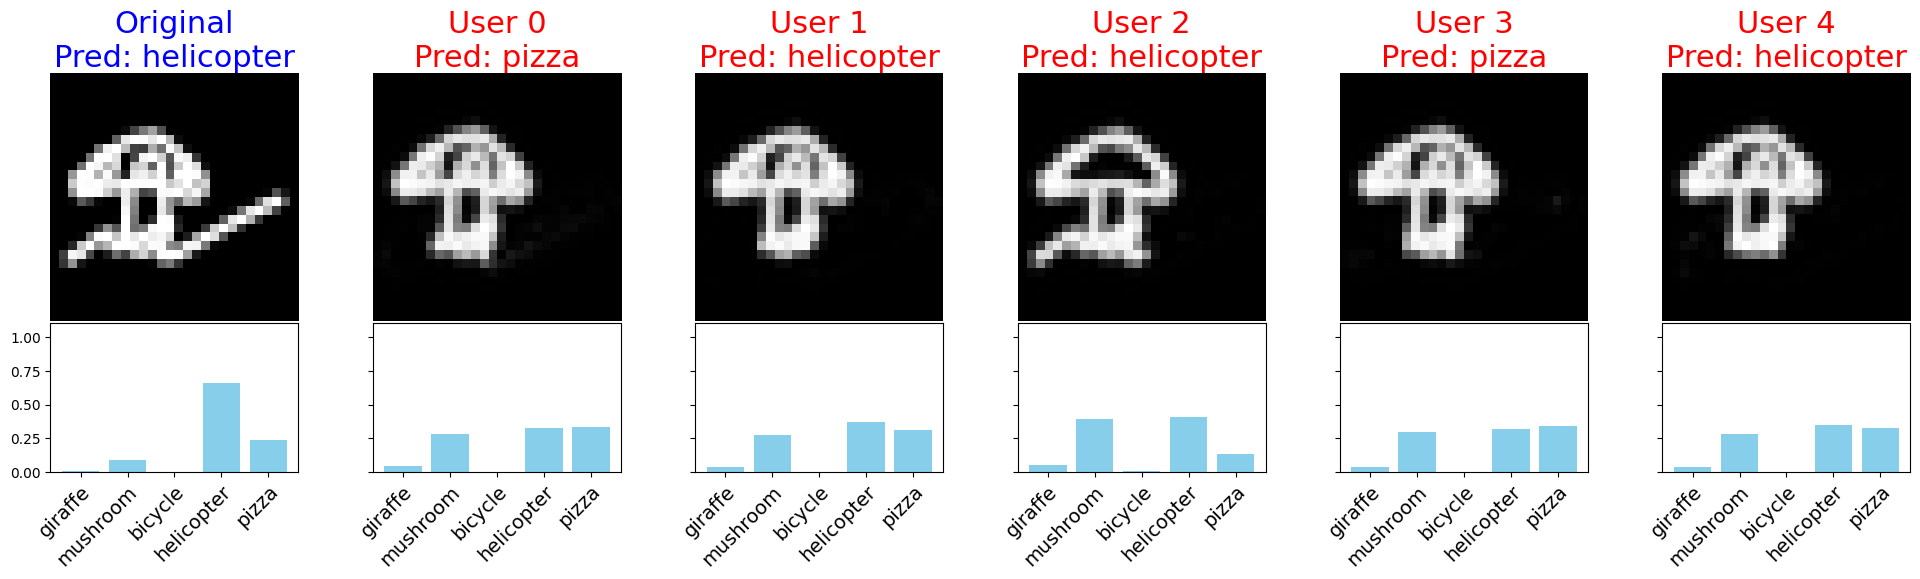

Pred label from npy: bicycle, Pred label from model: bicycle


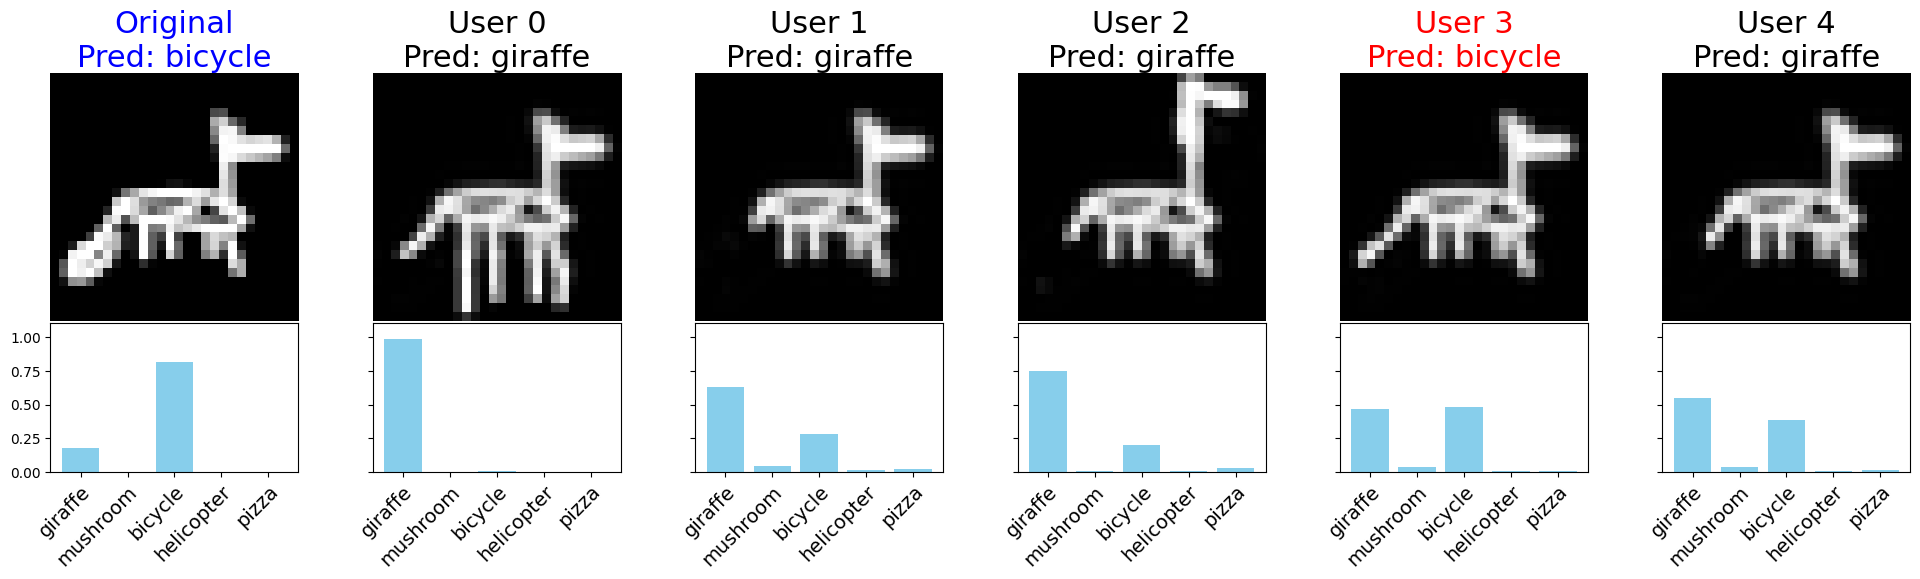

Pred label from npy: mushroom, Pred label from model: mushroom


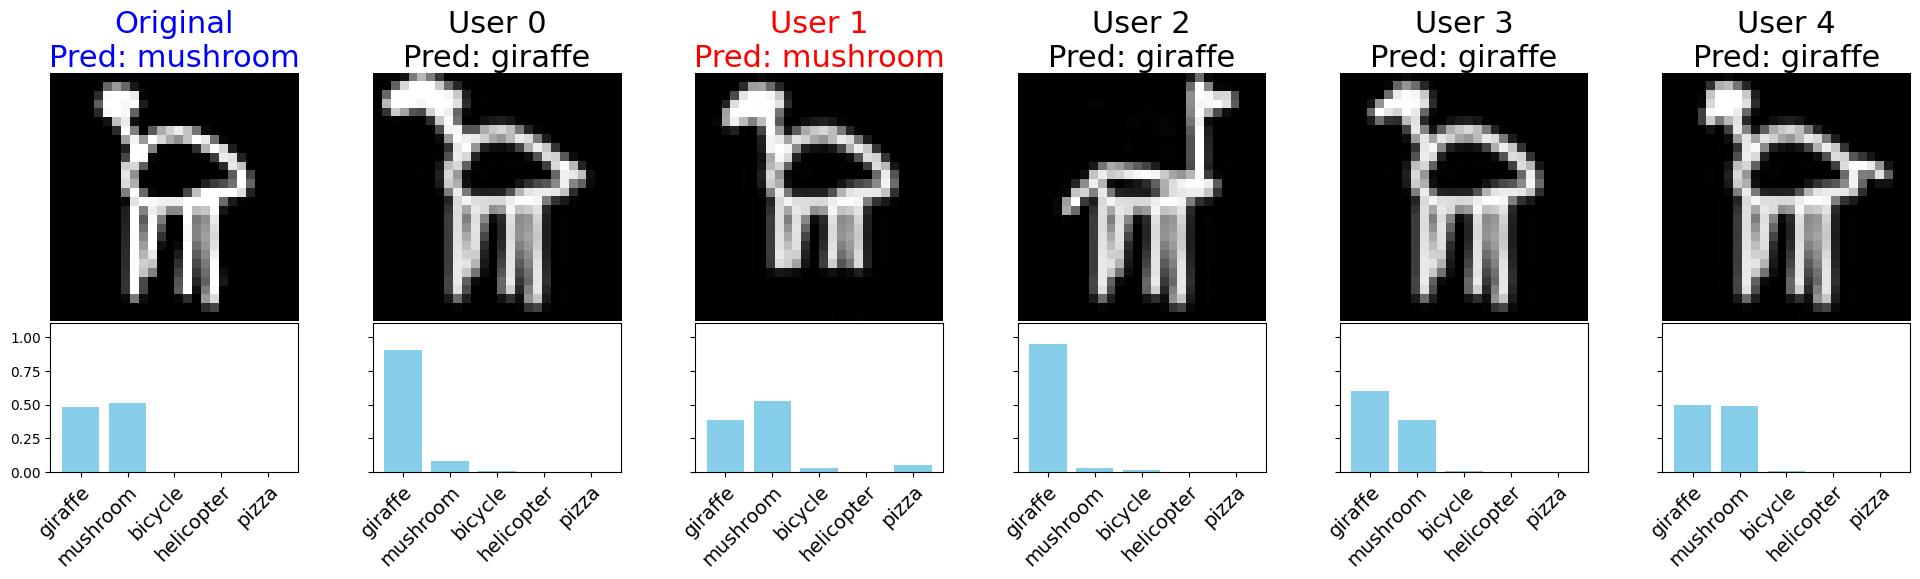

Pred label from npy: helicopter, Pred label from model: helicopter


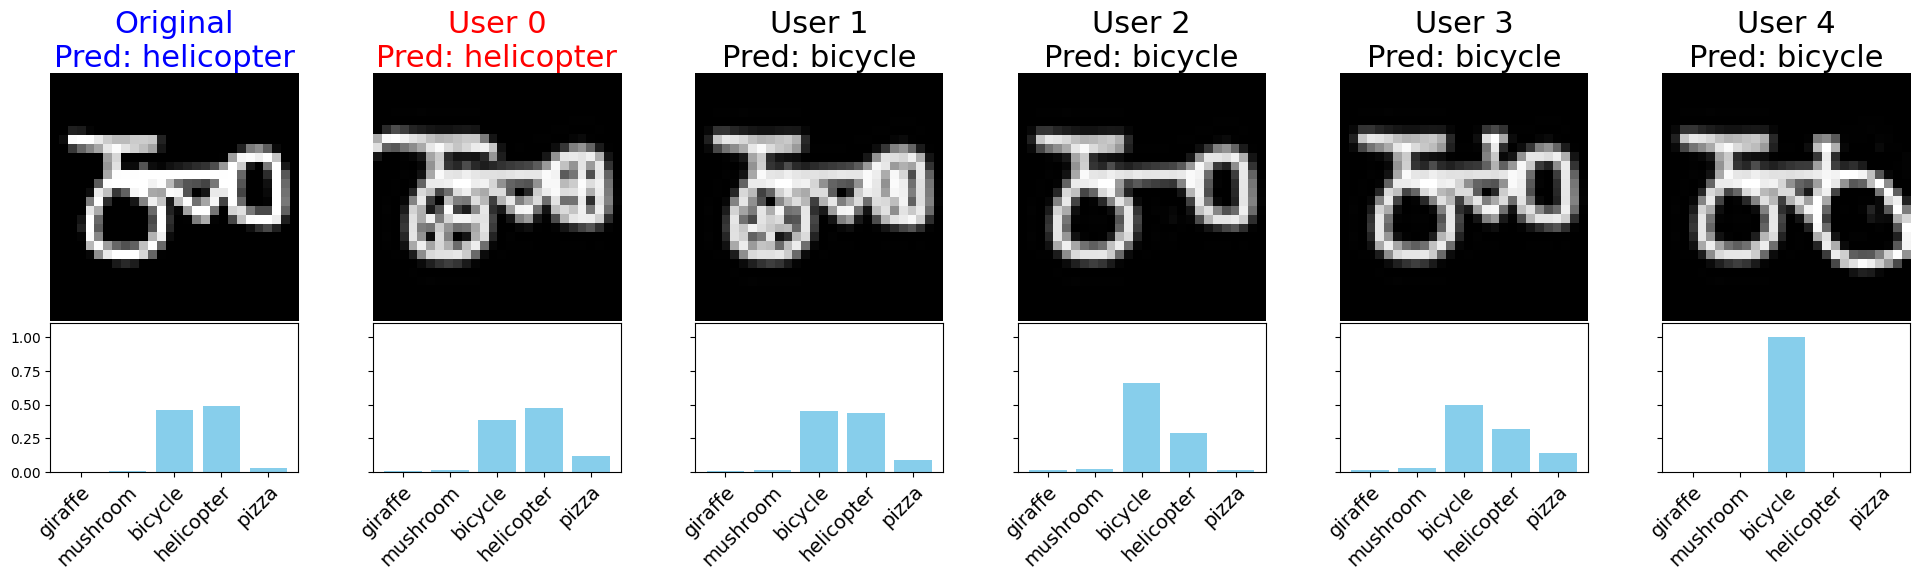

Pred label from npy: mushroom, Pred label from model: mushroom


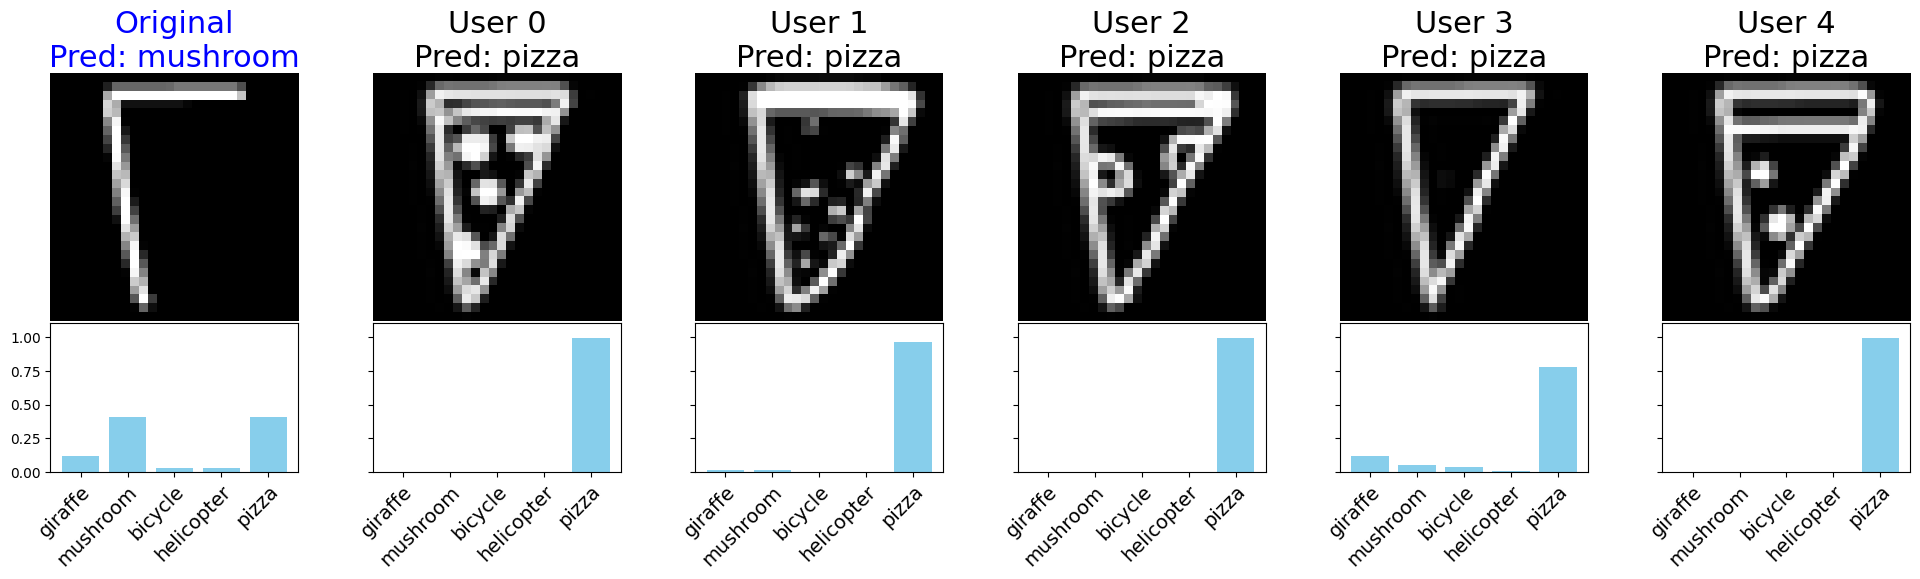

Pred label from npy: mushroom, Pred label from model: mushroom


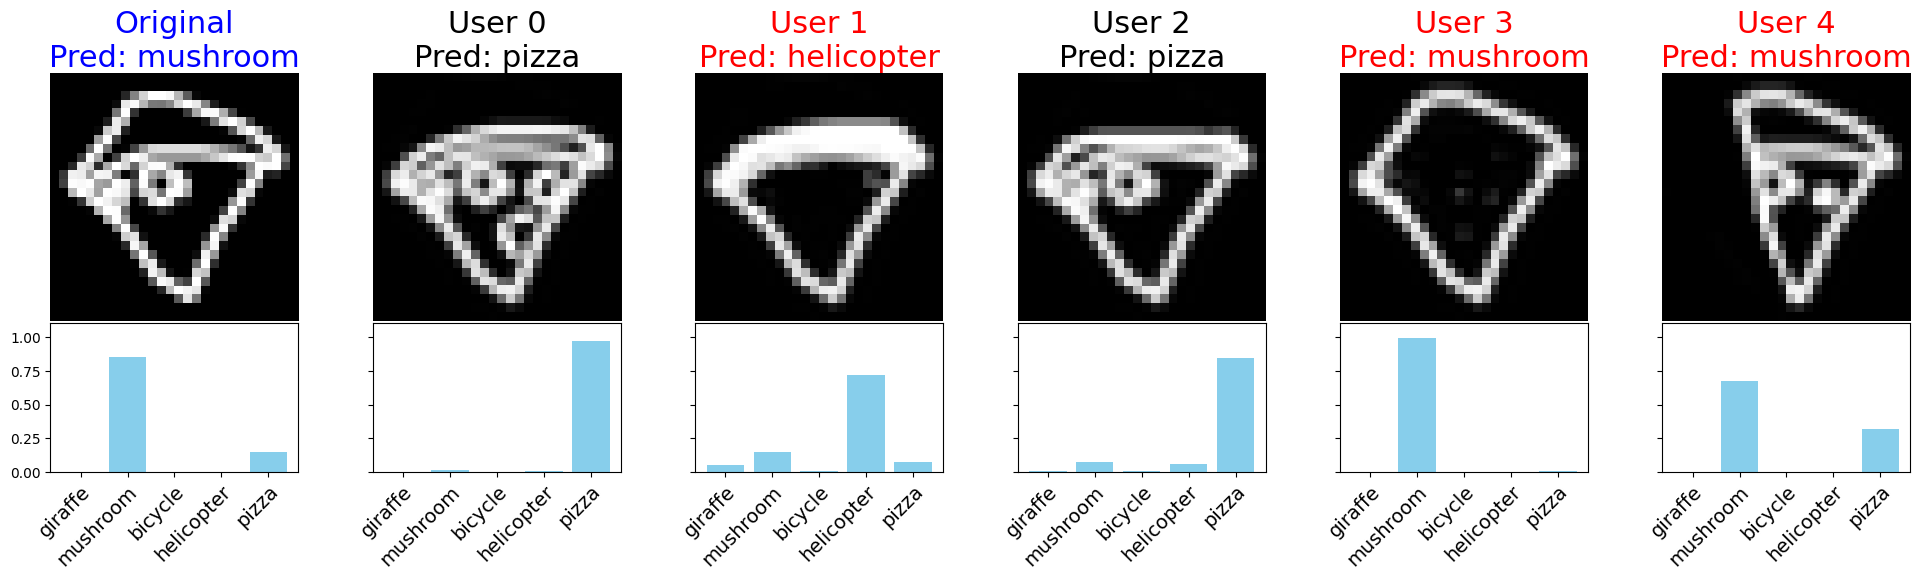

Pred label from npy: giraffe, Pred label from model: giraffe


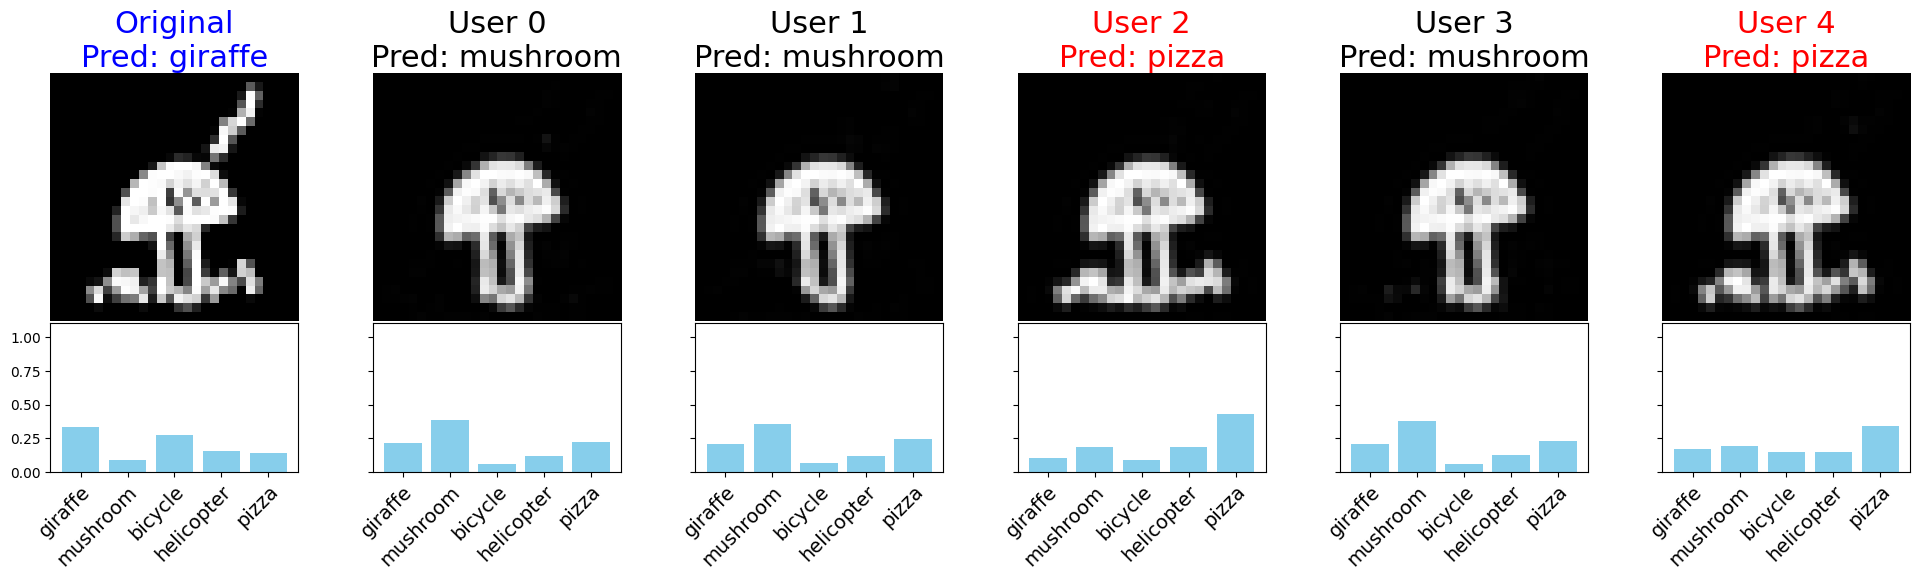

Pred label from npy: bicycle, Pred label from model: bicycle


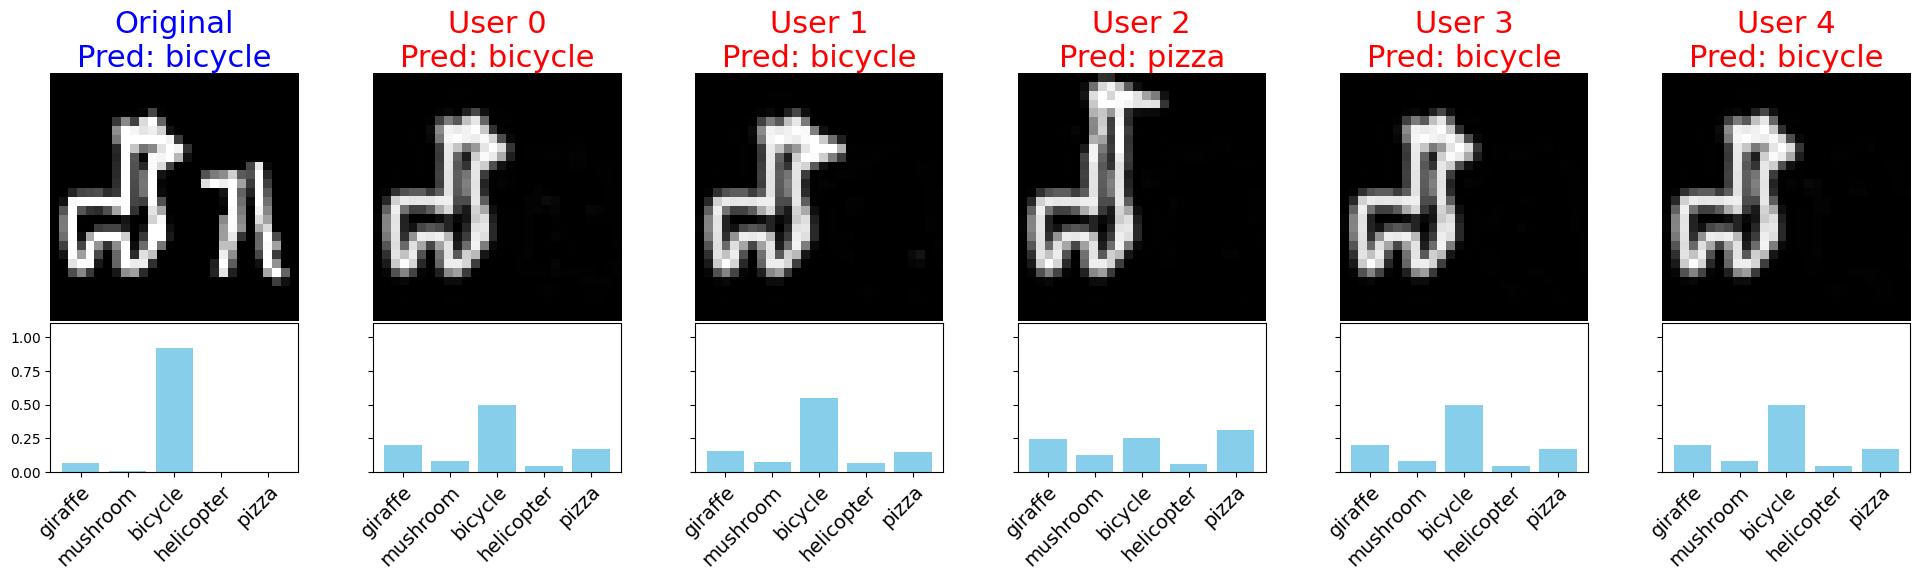

Pred label from npy: bicycle, Pred label from model: bicycle


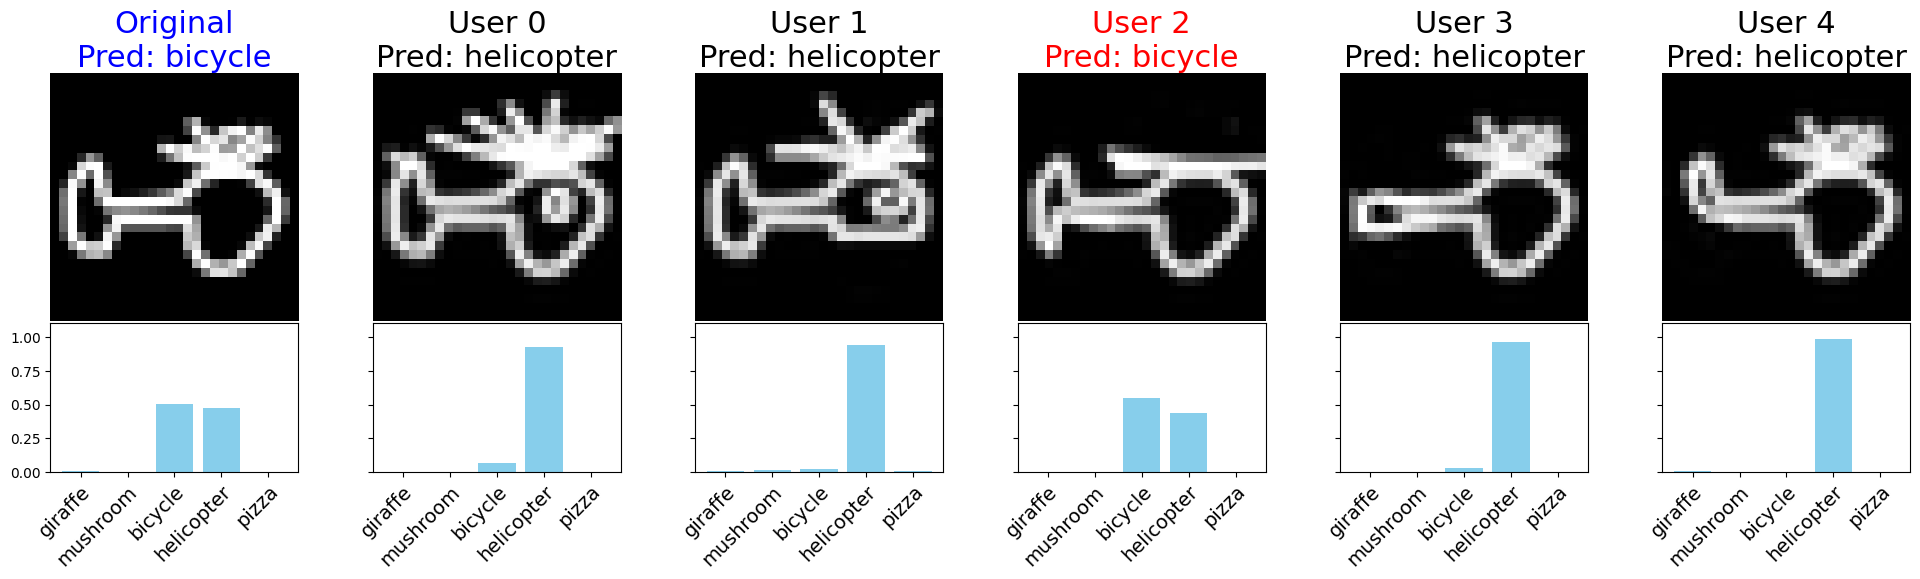

Pred label from npy: mushroom, Pred label from model: mushroom


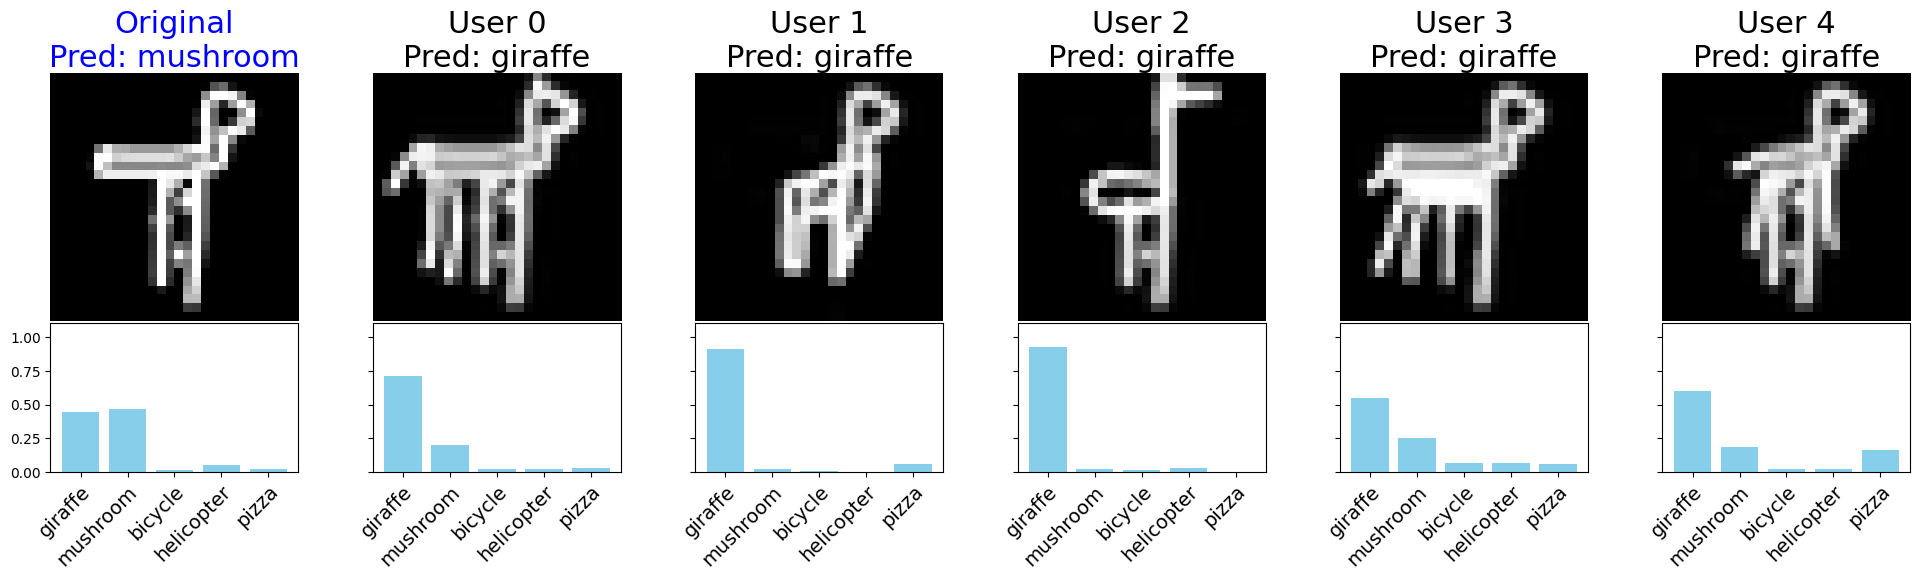

Pred label from npy: pizza, Pred label from model: pizza


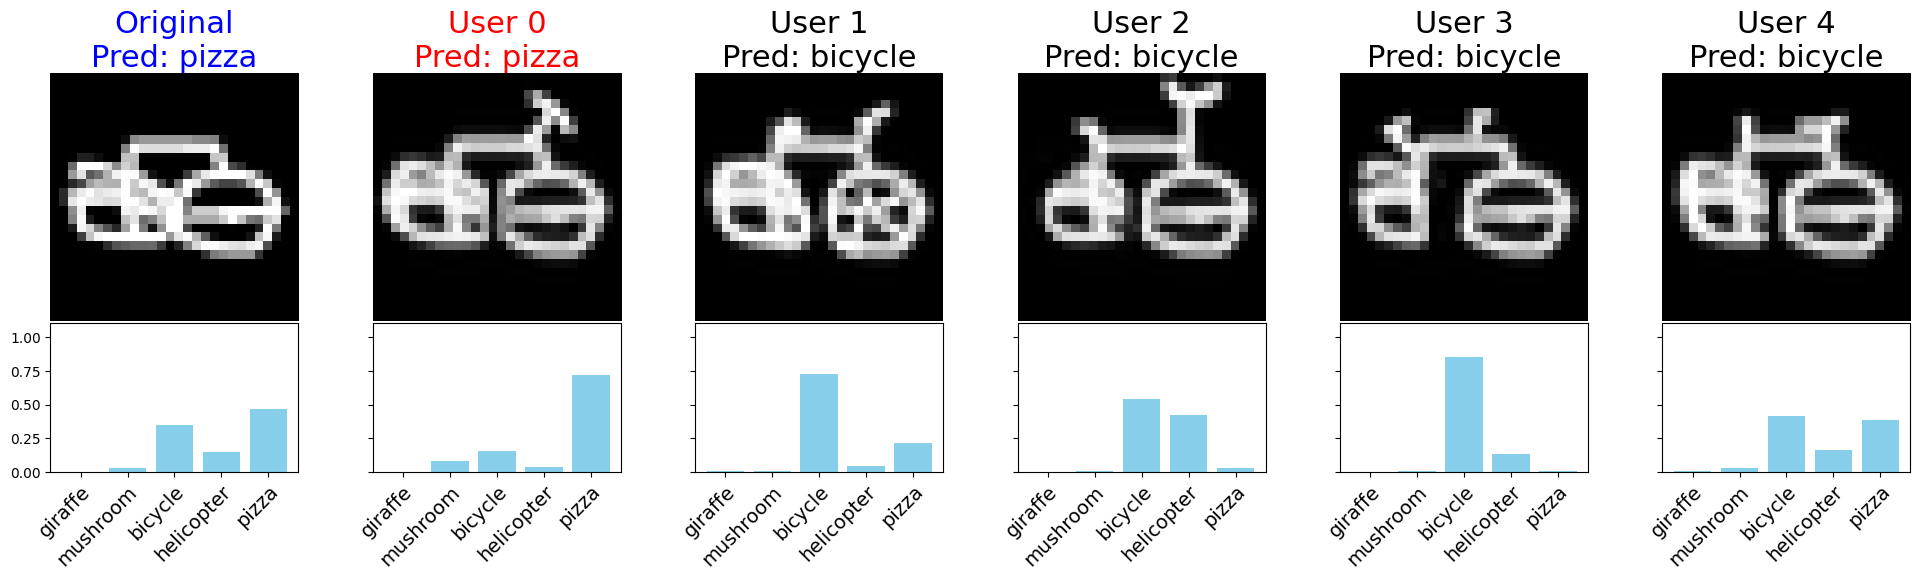

Pred label from npy: mushroom, Pred label from model: mushroom


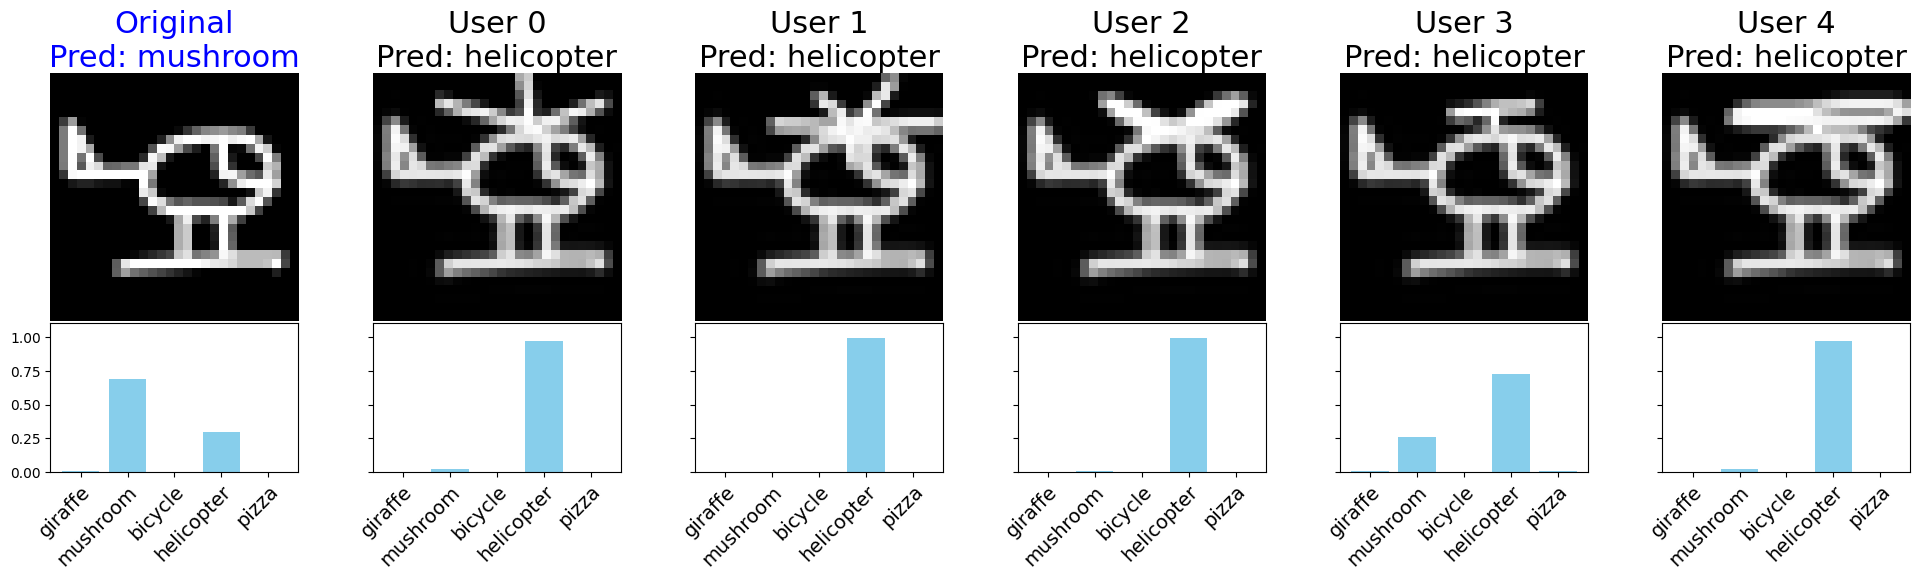

Pred label from npy: helicopter, Pred label from model: helicopter


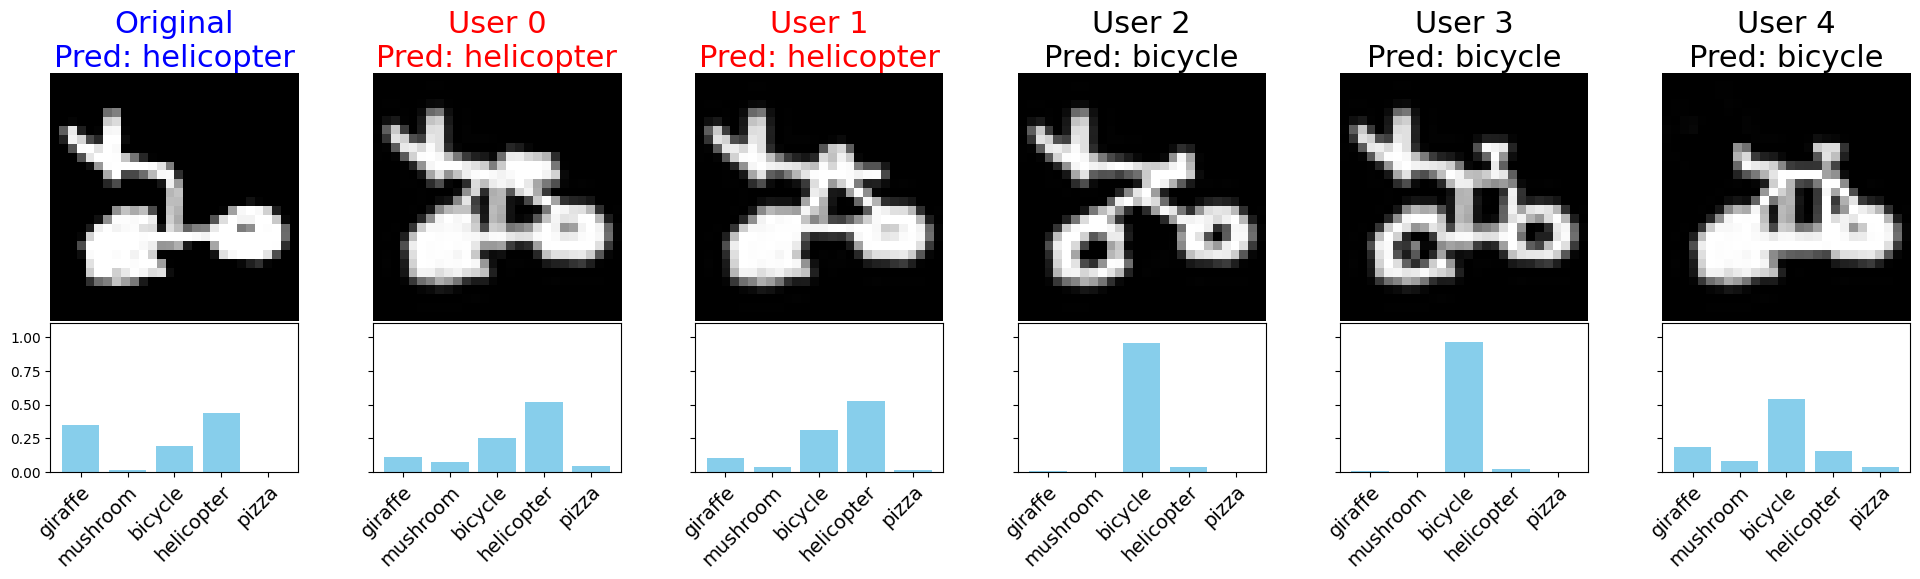

Pred label from npy: giraffe, Pred label from model: giraffe


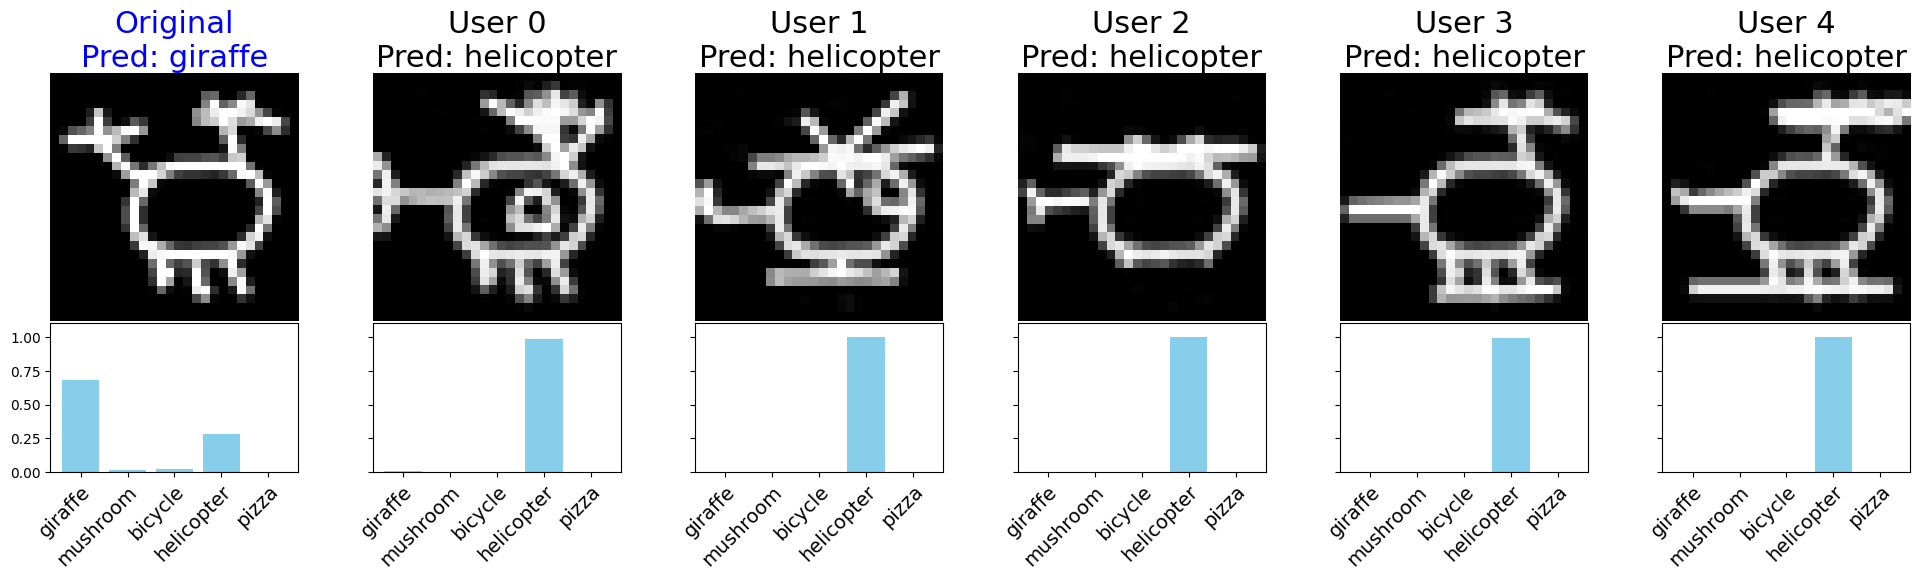

Pred label from npy: helicopter, Pred label from model: helicopter


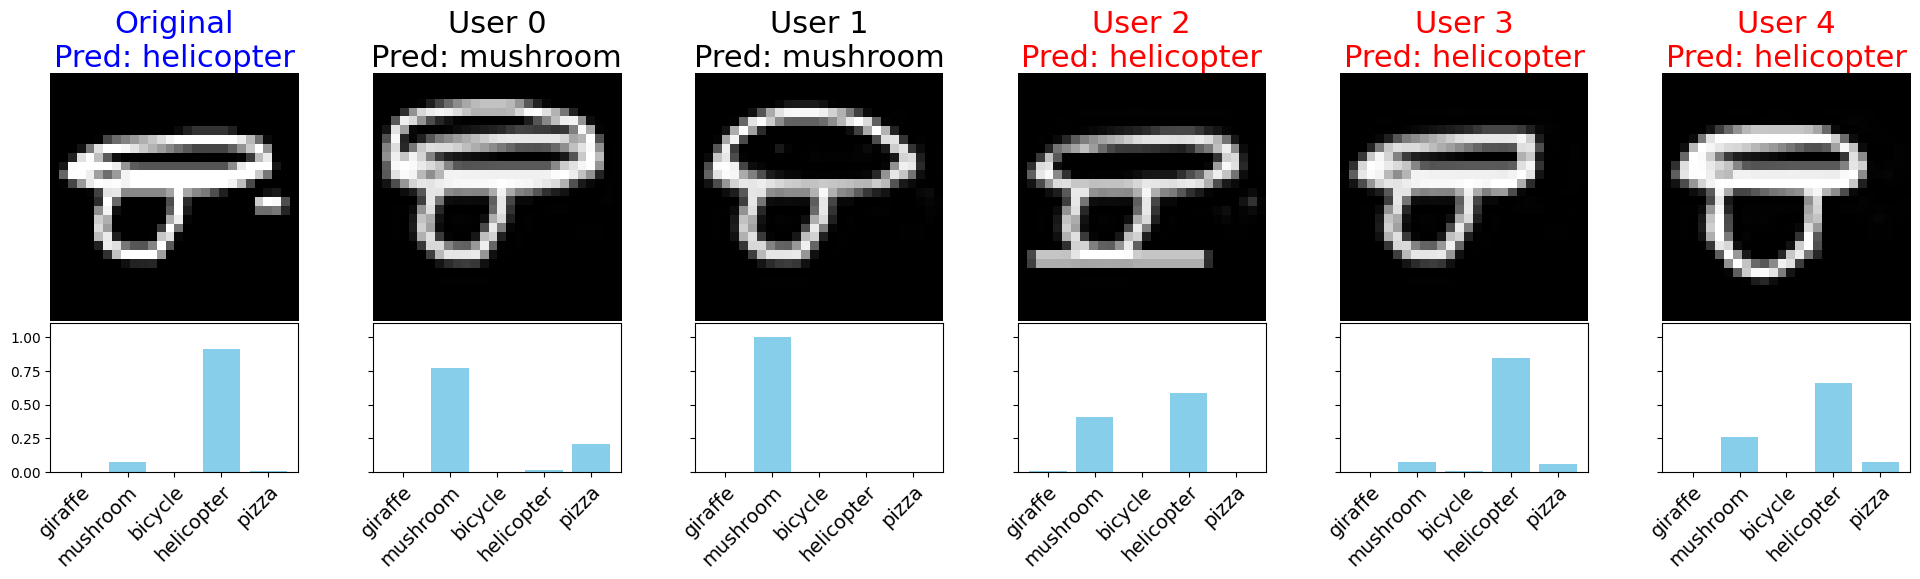

Pred label from npy: giraffe, Pred label from model: giraffe


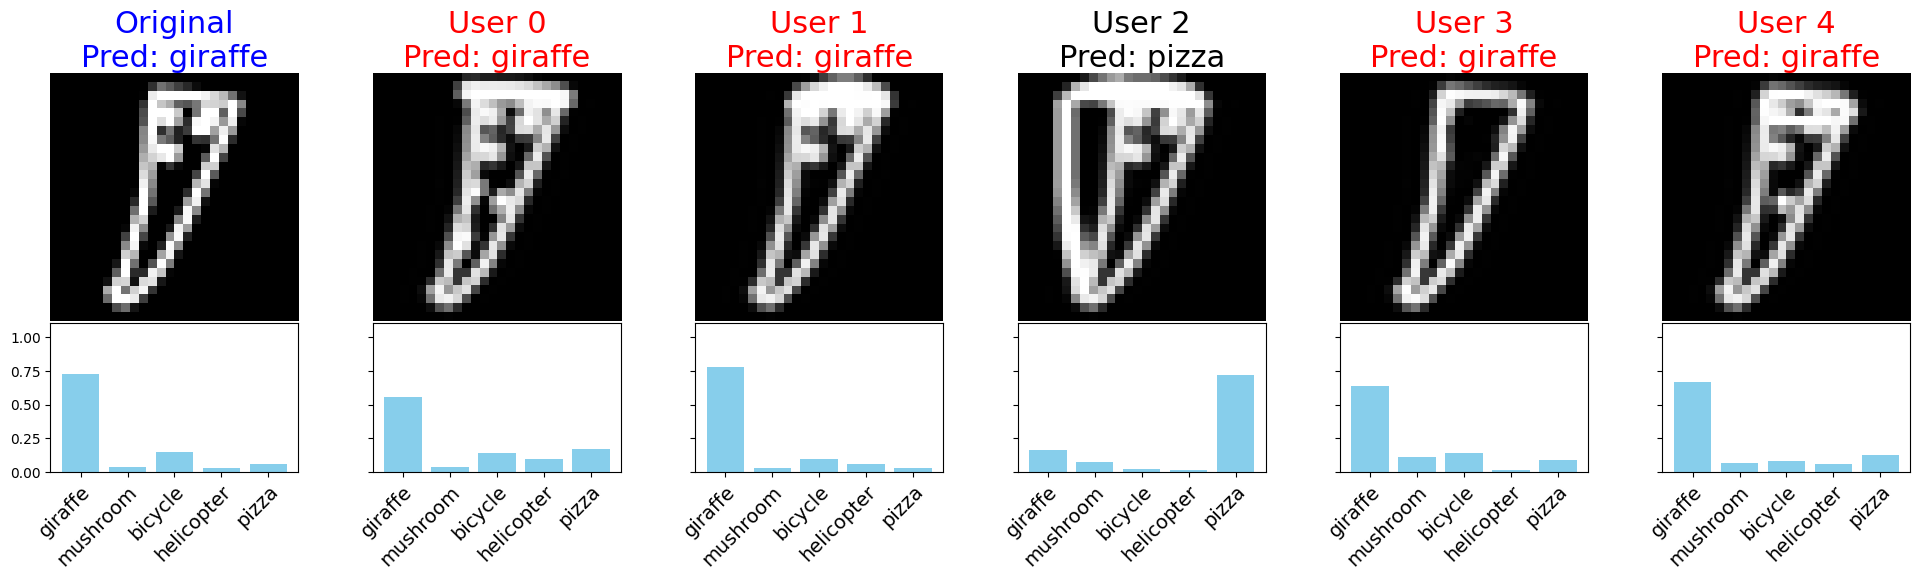

Pred label from npy: giraffe, Pred label from model: giraffe


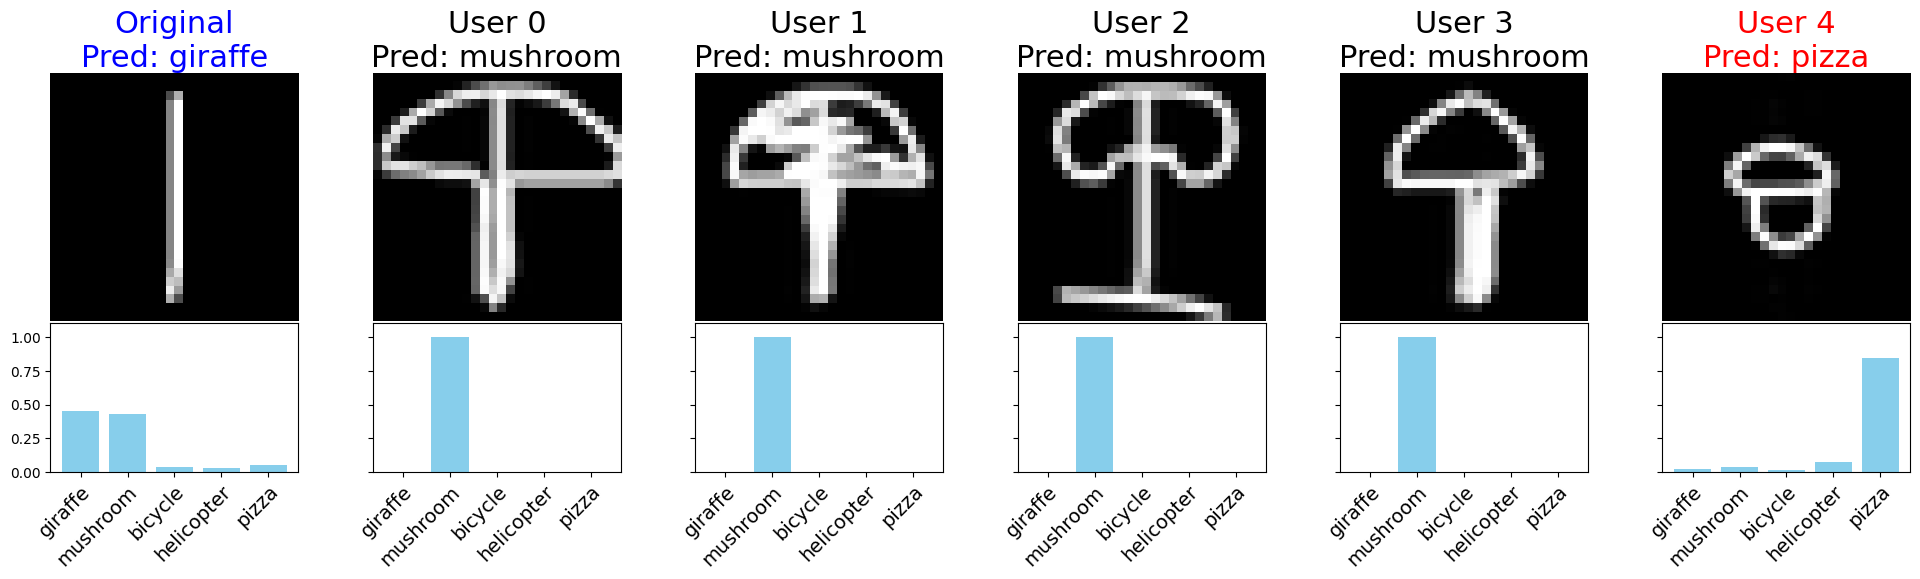

Pred label from npy: mushroom, Pred label from model: mushroom


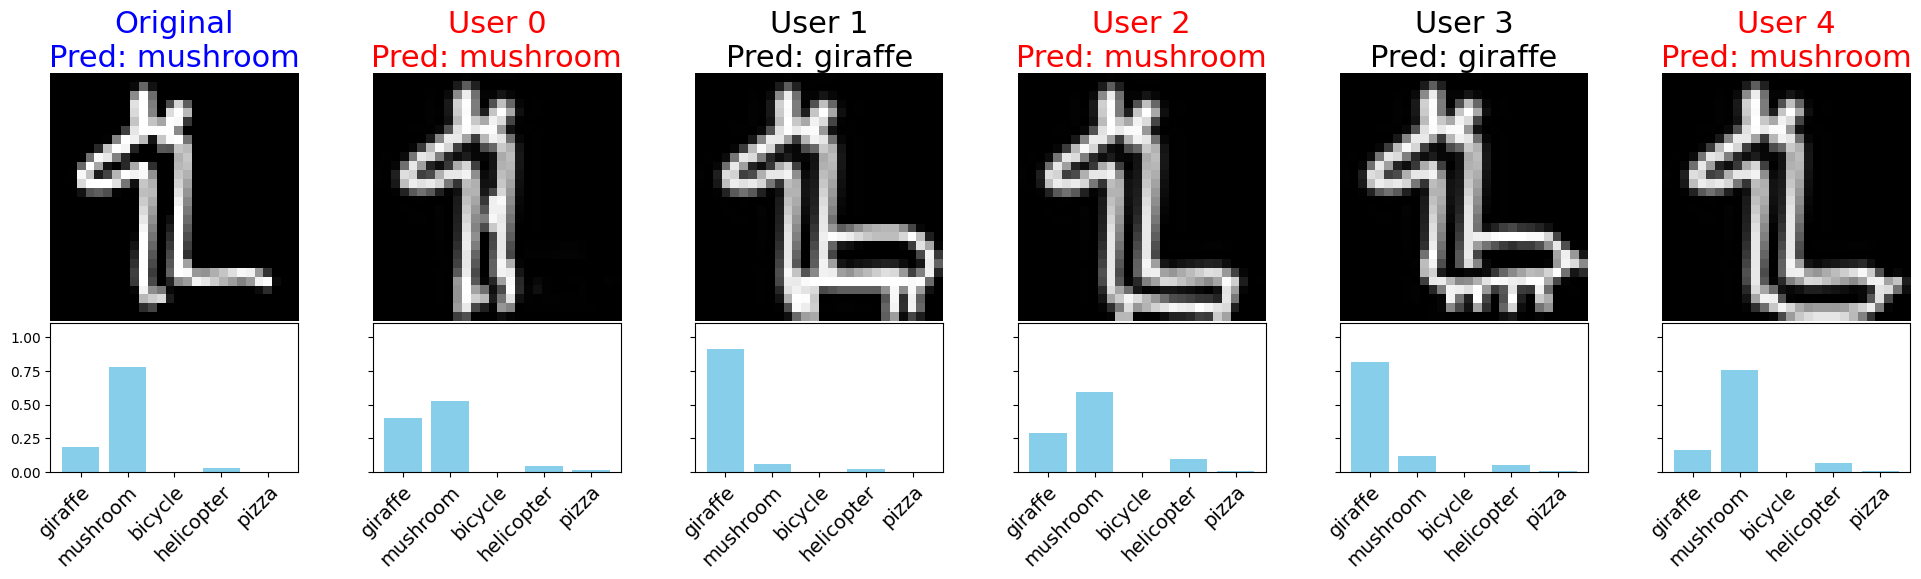

Pred label from npy: mushroom, Pred label from model: mushroom


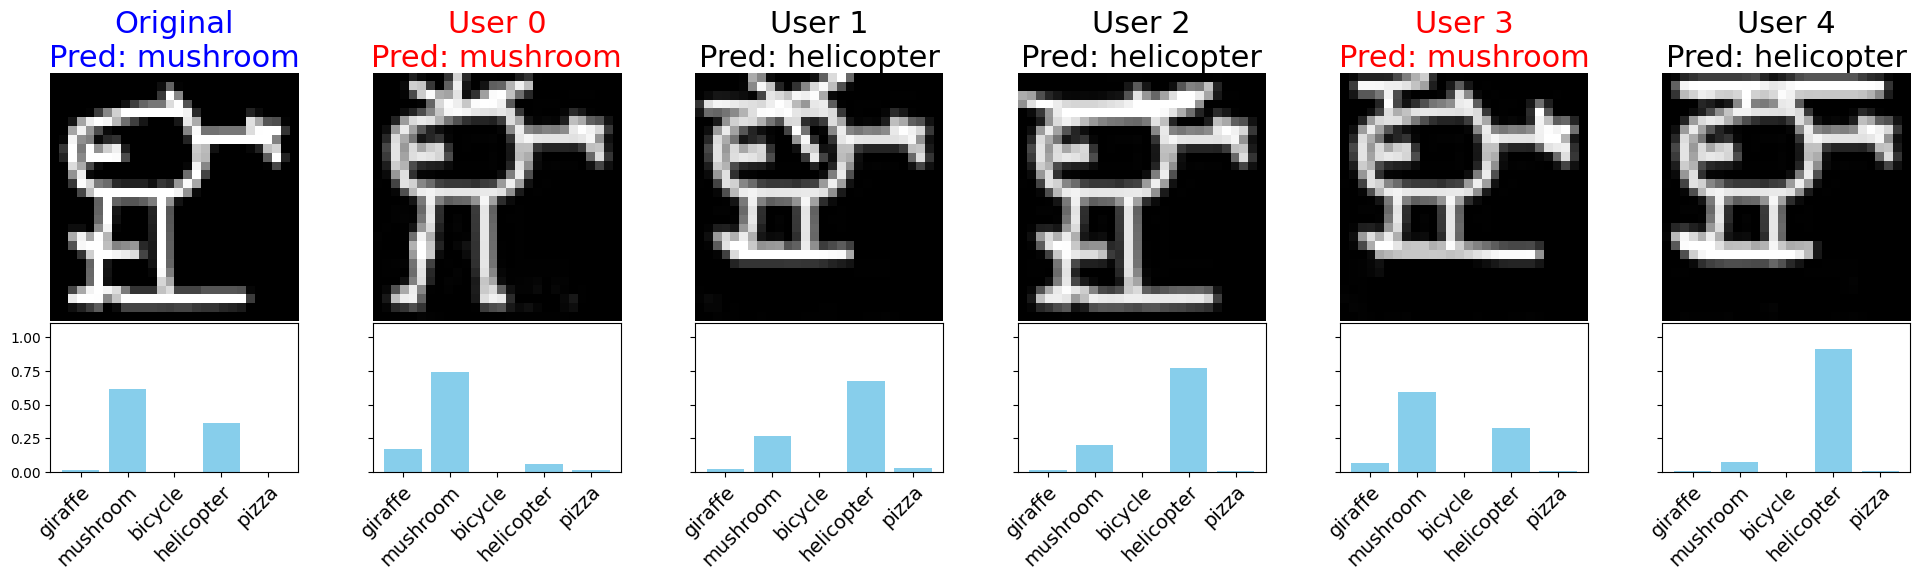

Pred label from npy: pizza, Pred label from model: pizza


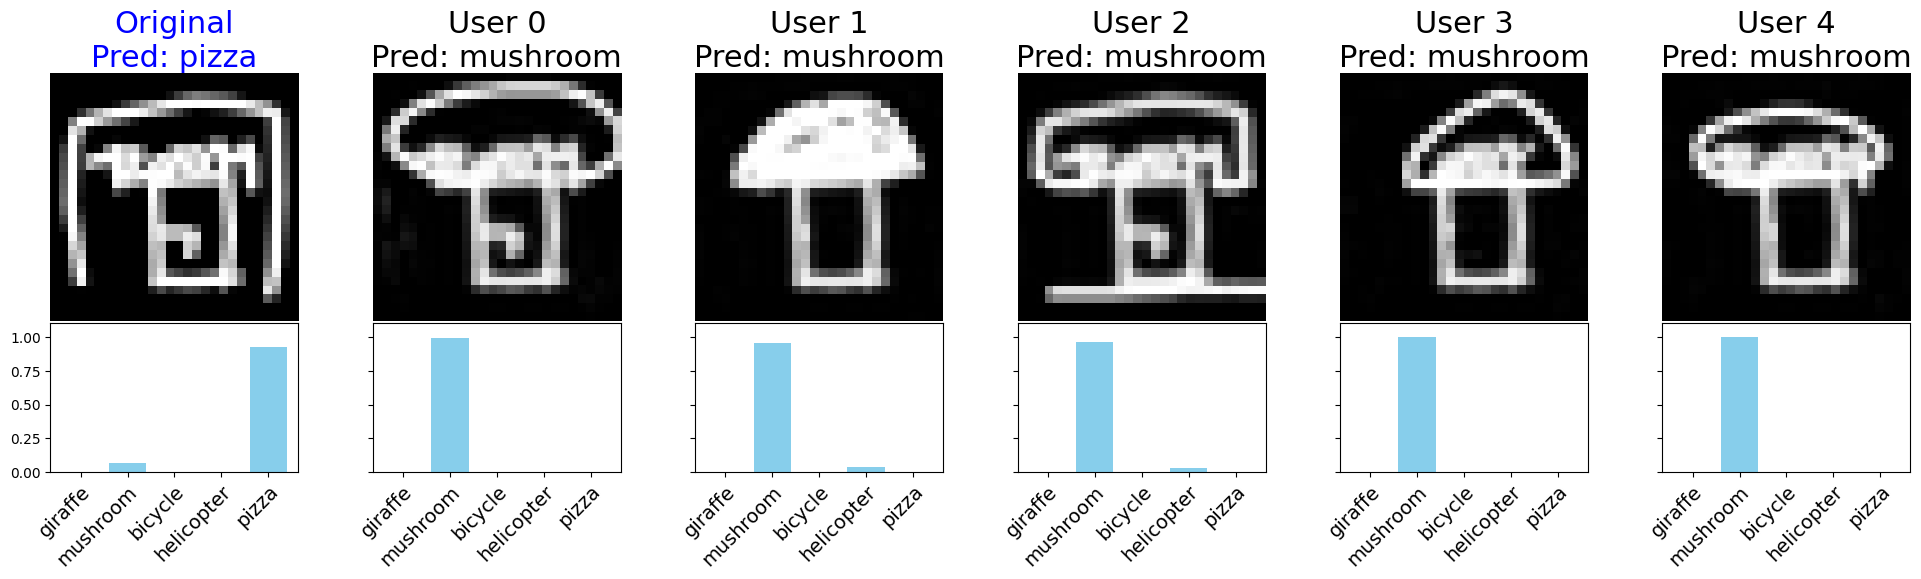

Pred label from npy: bicycle, Pred label from model: bicycle


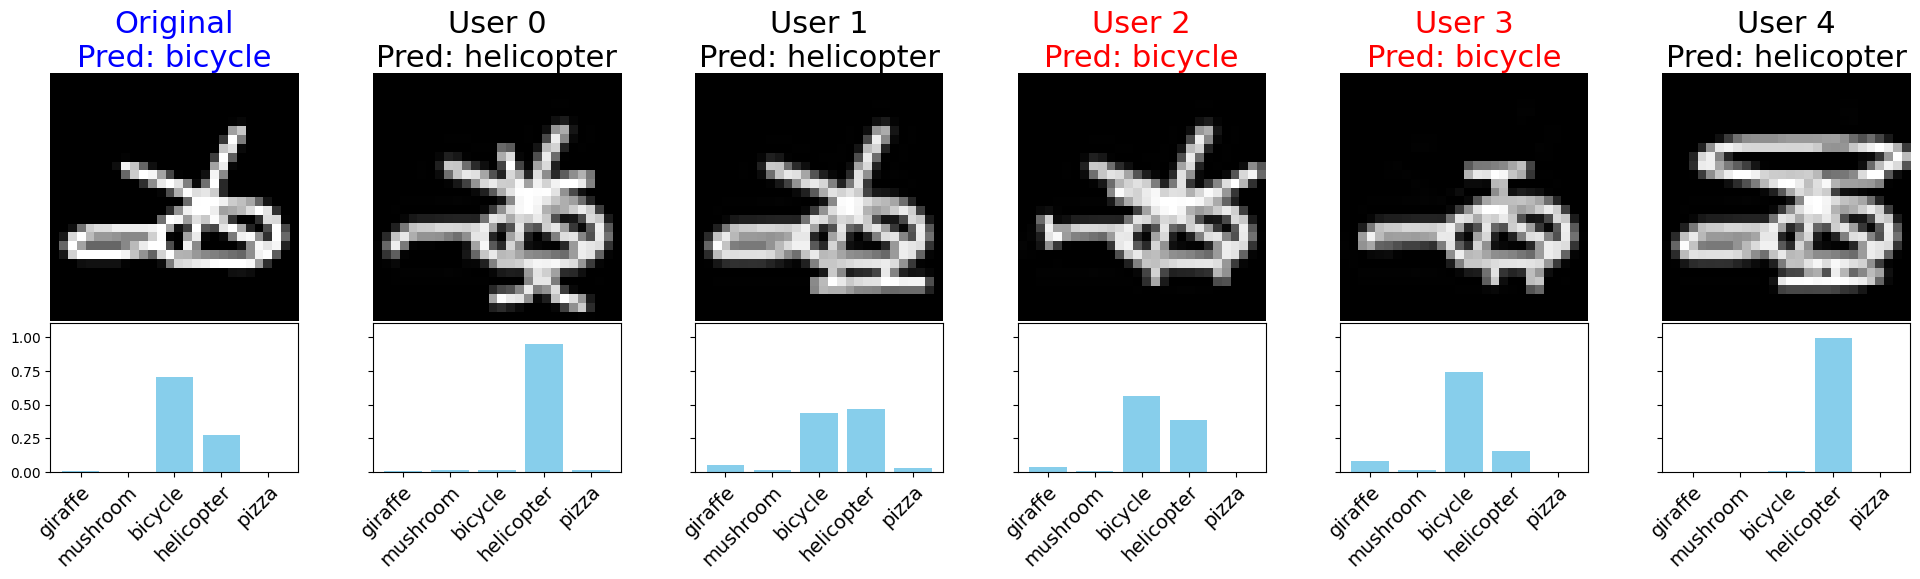

Pred label from npy: bicycle, Pred label from model: bicycle


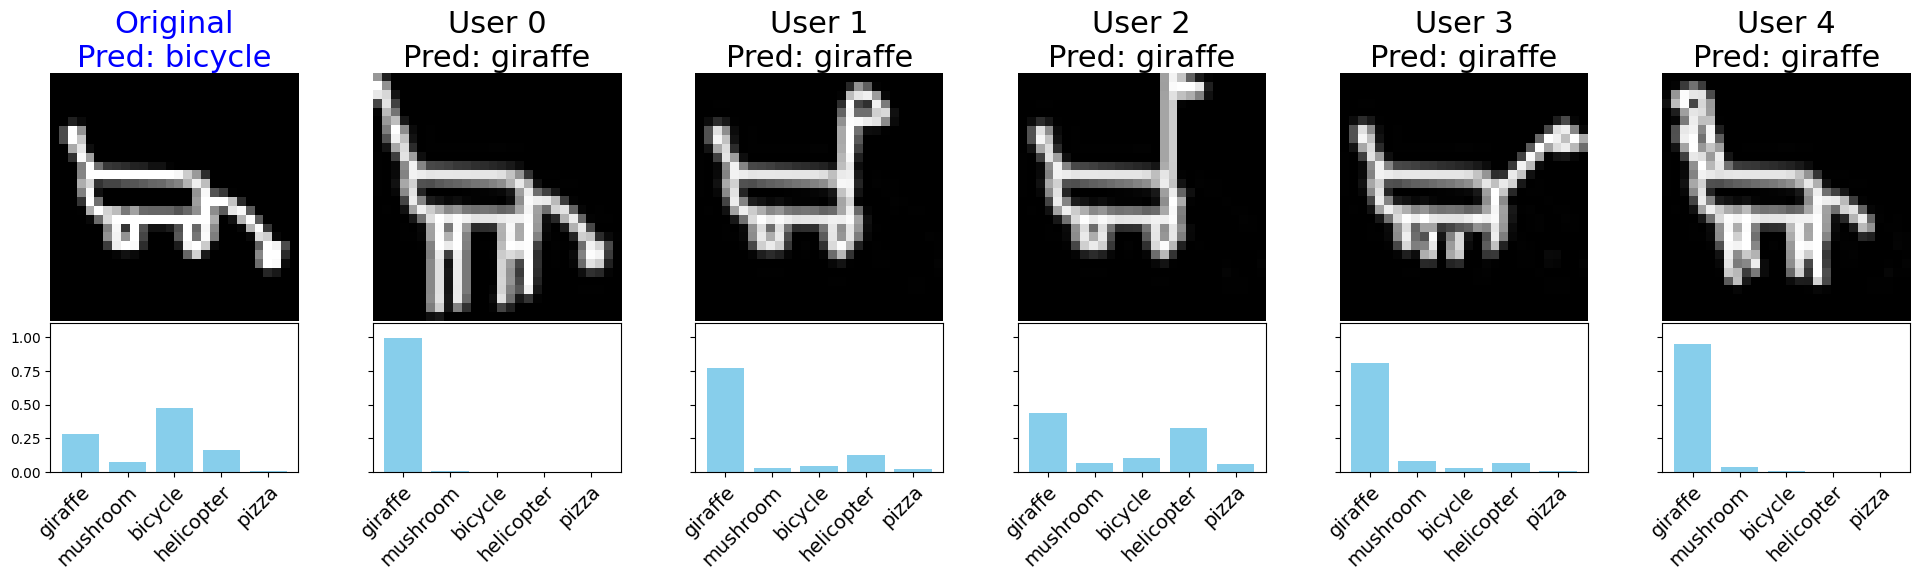

Pred label from npy: mushroom, Pred label from model: mushroom


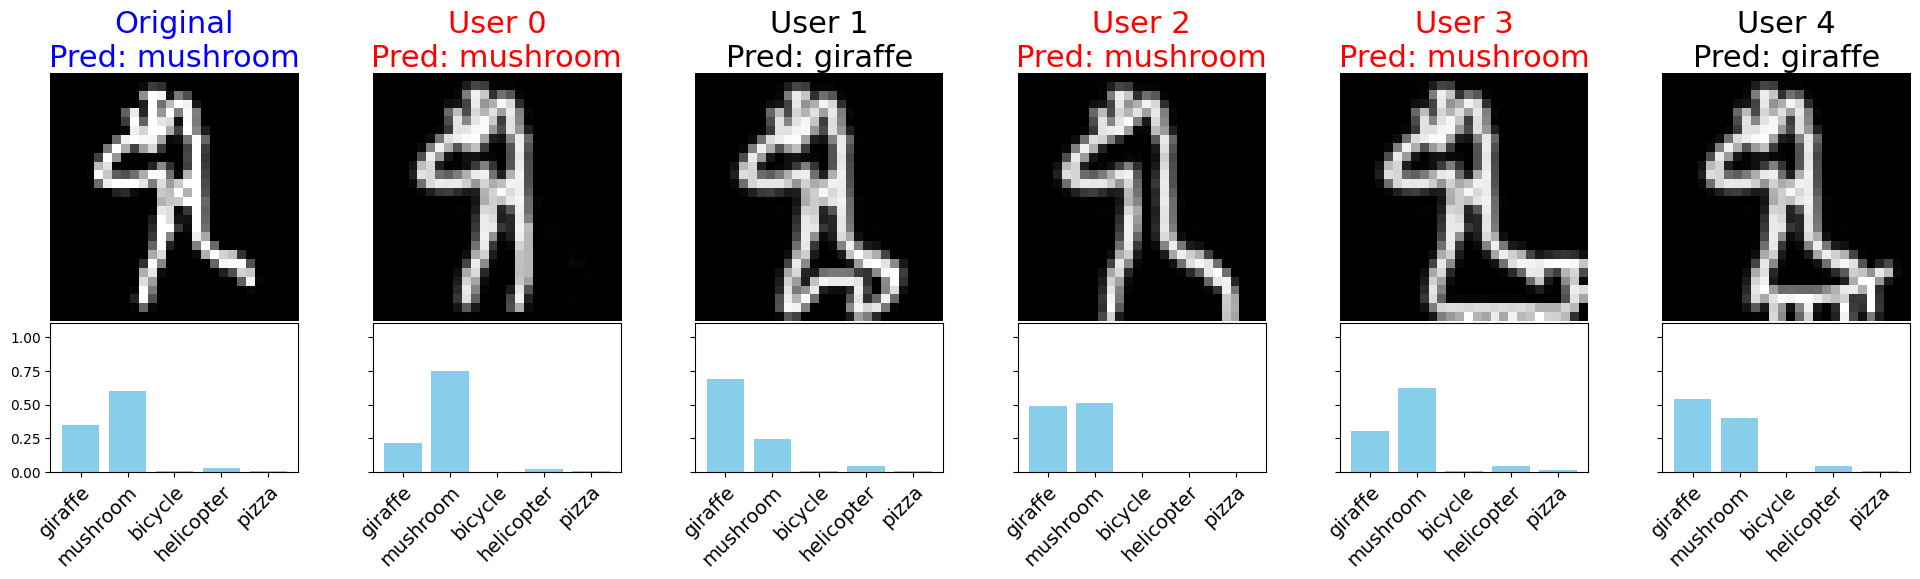

Pred label from npy: helicopter, Pred label from model: helicopter


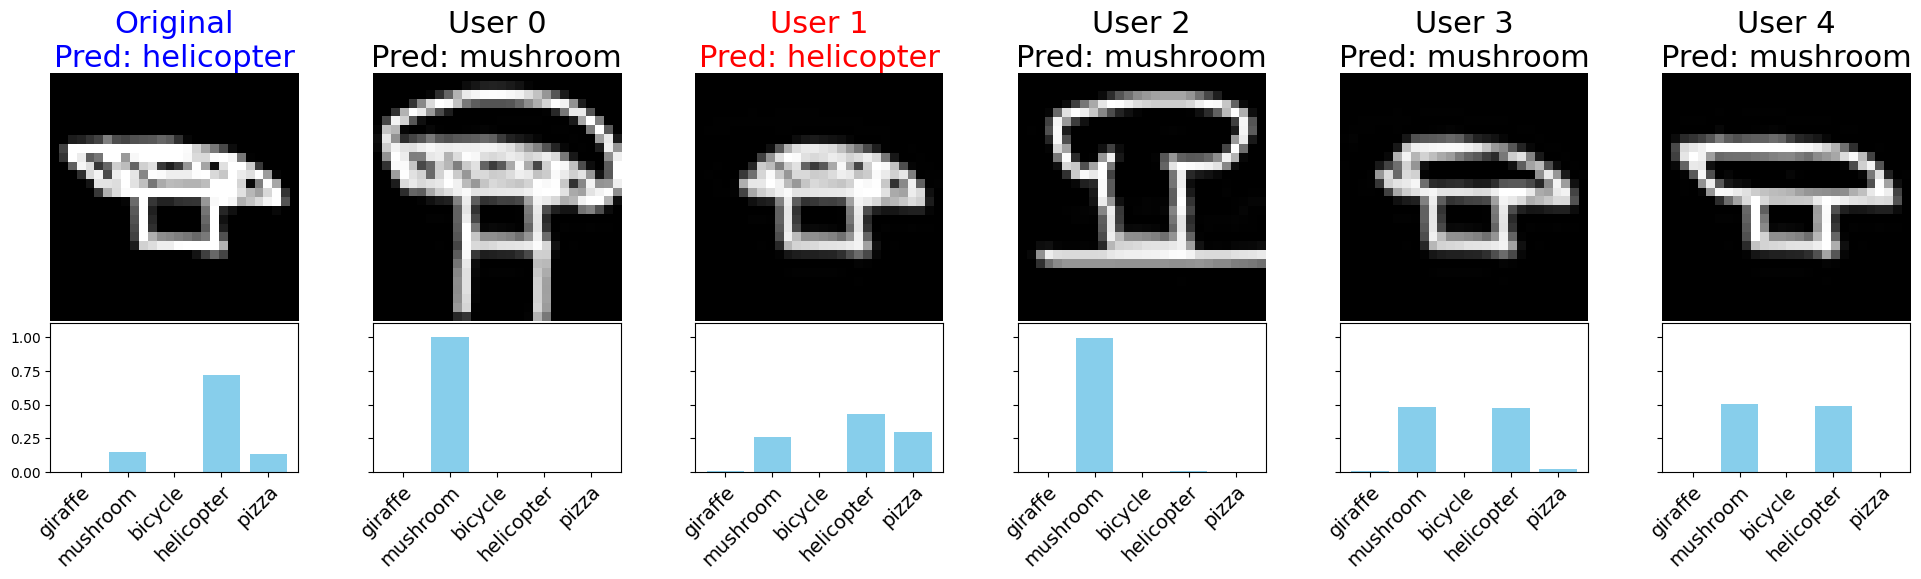

Pred label from npy: helicopter, Pred label from model: helicopter


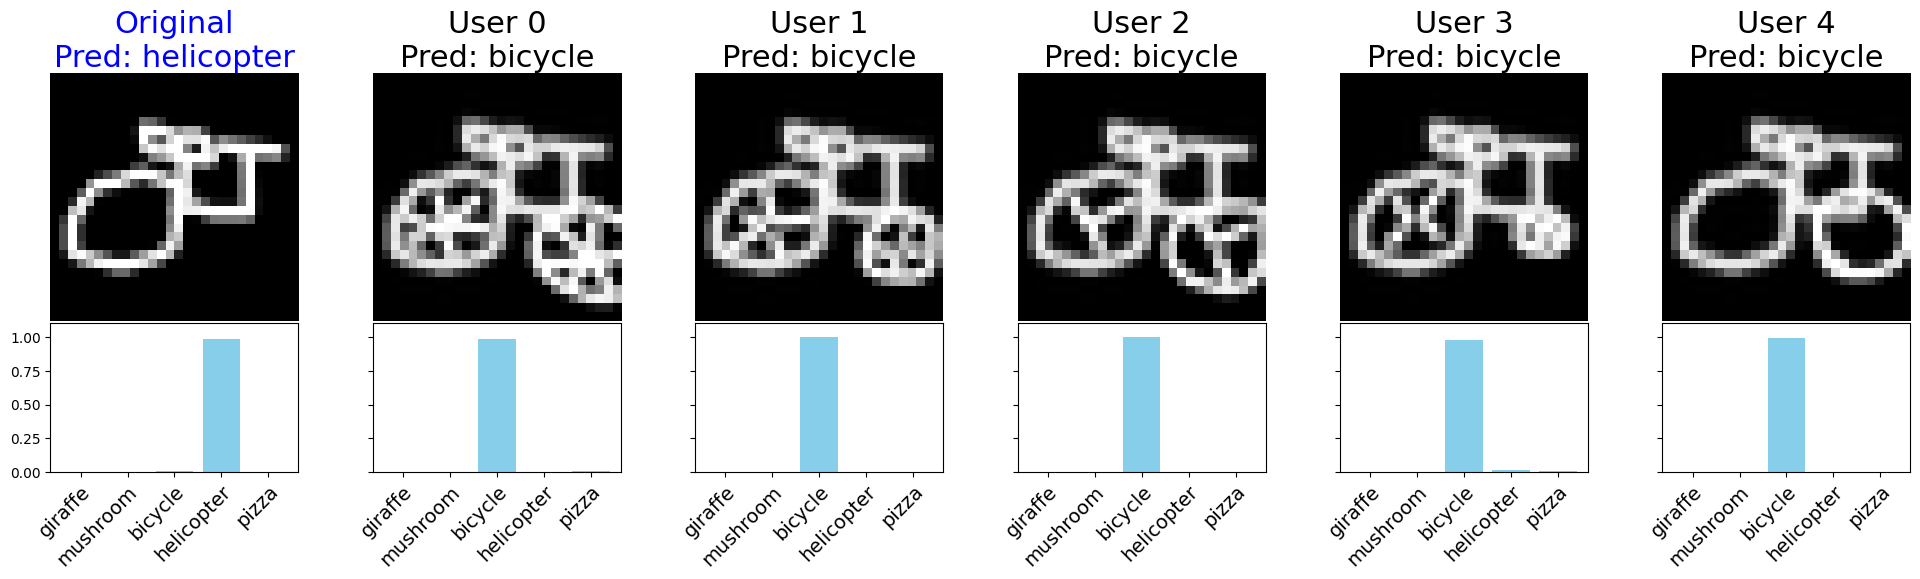

Pred label from npy: giraffe, Pred label from model: giraffe


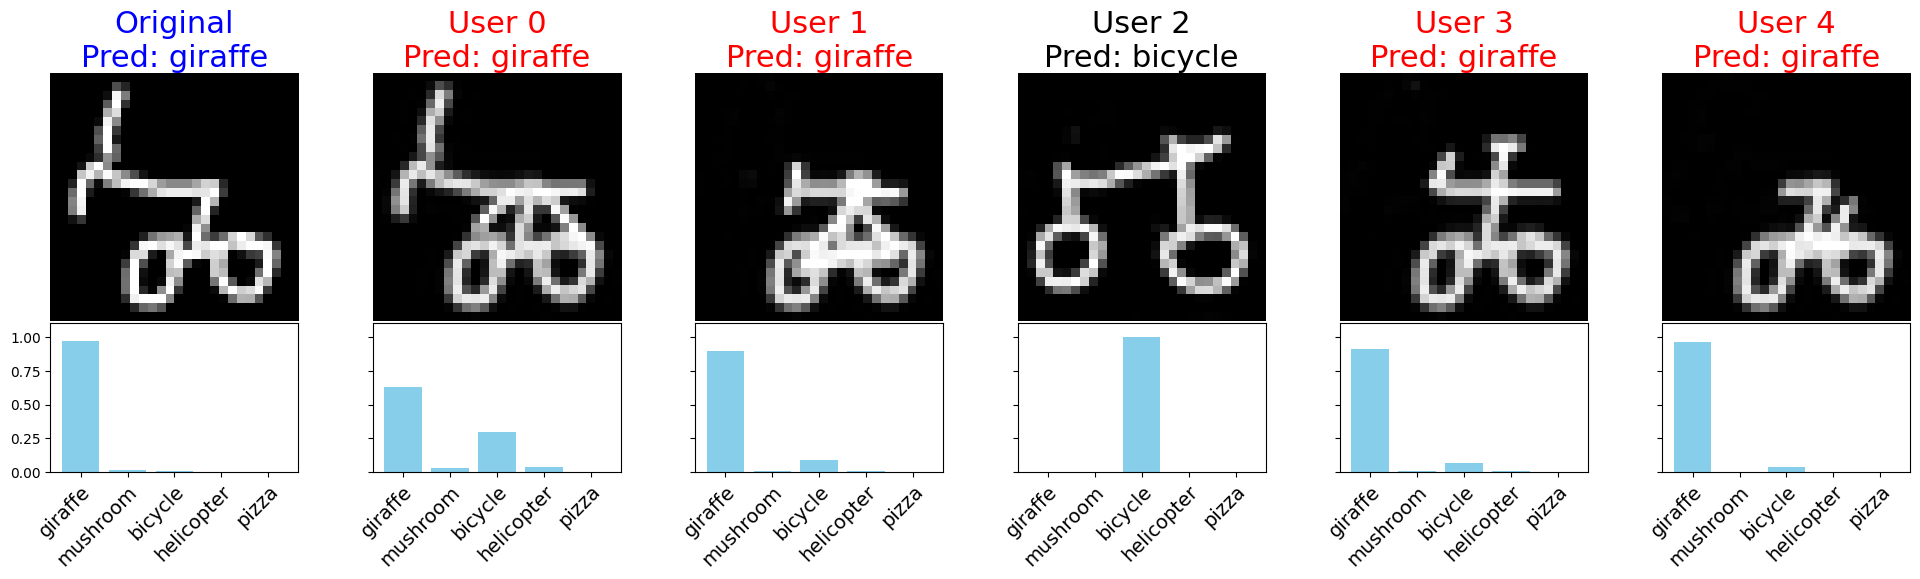

Pred label from npy: bicycle, Pred label from model: bicycle


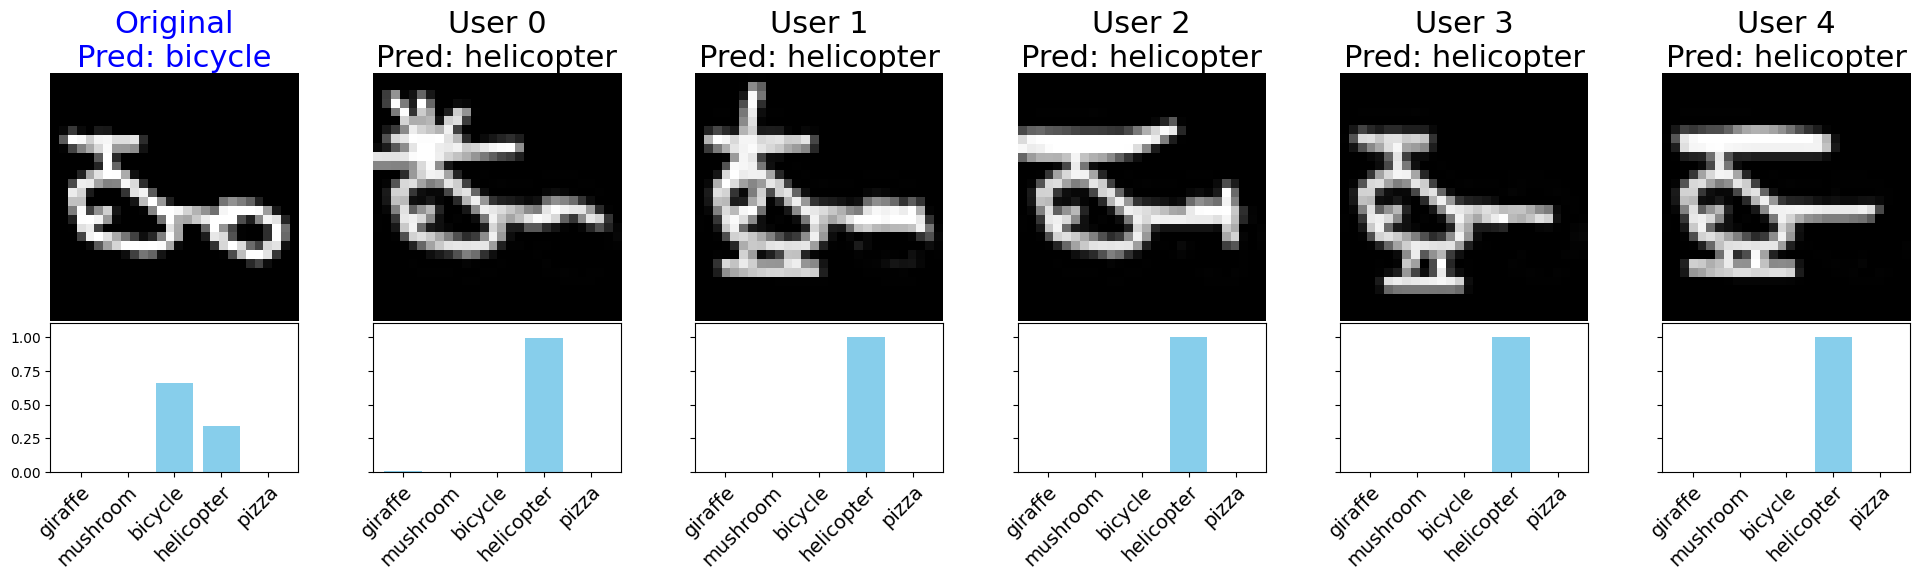

Pred label from npy: bicycle, Pred label from model: bicycle


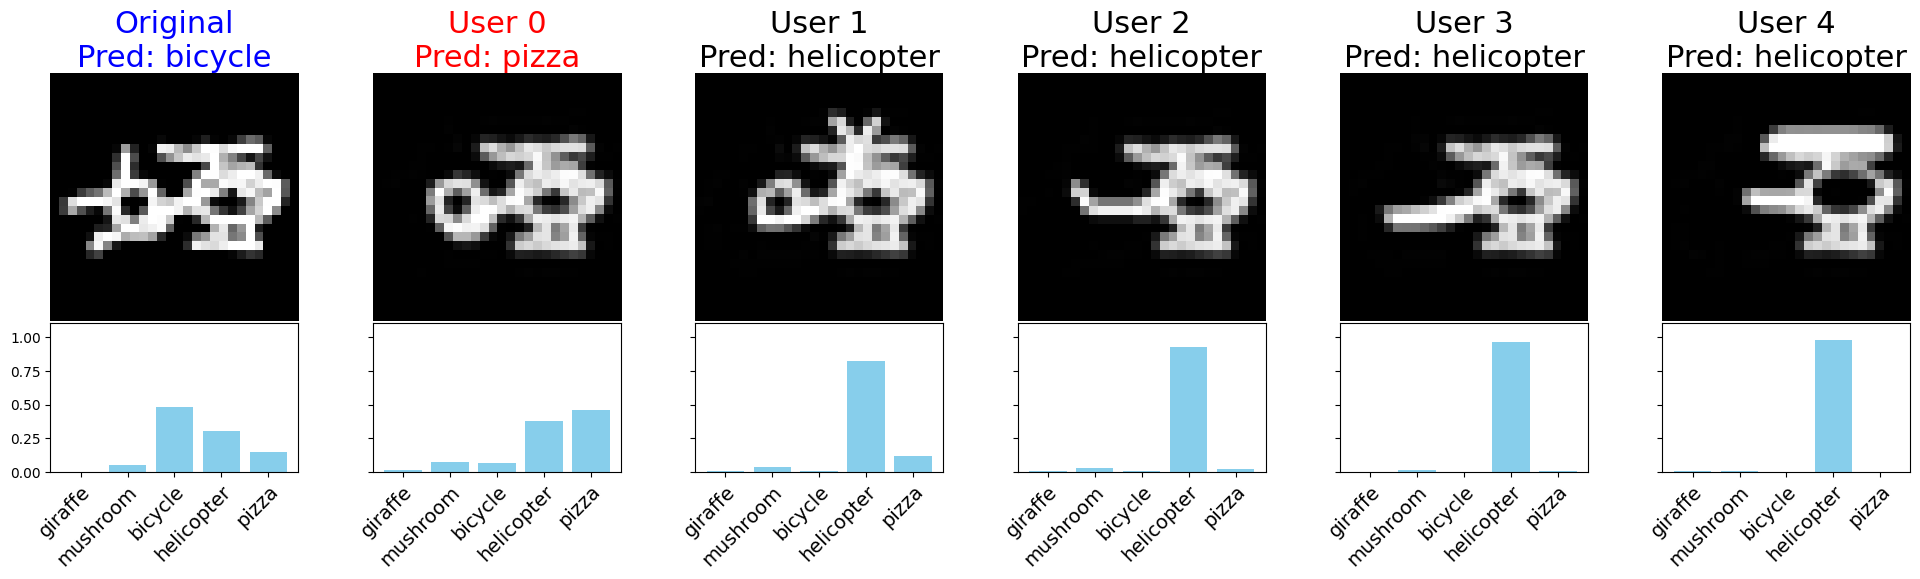

In [441]:
for img_idx in range(30):
    plot_qd_baseline(img_idx)

In [191]:
user_explanations_g1[:,0].shape

(21, 28, 28, 1)

In [219]:
def get_semi_factuals_mnist(img_idx):
    true_label = y_test[user_indices[img_idx]]
    
    cf_data_list = user_explanations_g1[:, img_idx]

    num_semi_factuals = 0

    for i in range(21):
        col_idx = i + 1 
        
        sample = cf_data_list[i]
        
        sample_pred_prob = keras_cnn.predict(sample.reshape(1,28,28,1), verbose=0).squeeze()
        sample_pred_label = np.argmax(sample_pred_prob)
        if sample_pred_label != true_label:
            num_semi_factuals += 1

    # print(f"Number of semi-factuals (model prediction changes but user explanation is the same): {num_semi_factuals}")
    return num_semi_factuals


In [220]:
len(user_indices)

50

In [221]:
all_semi_factual_counts = []
for i in range(len(user_indices)):
    curr_count = get_semi_factuals_mnist(i)
    all_semi_factual_counts.append(curr_count)

In [204]:
sum(all_semi_factual_counts)
187/1050

0.17809523809523808

### Calculate Semi-factual rates and break down for 2 cases

In [291]:
qd_preds_wrong.shape

(50,)

In [297]:
quickdraw_misclassified_image_user_set.shape

(30, 28, 28, 1)

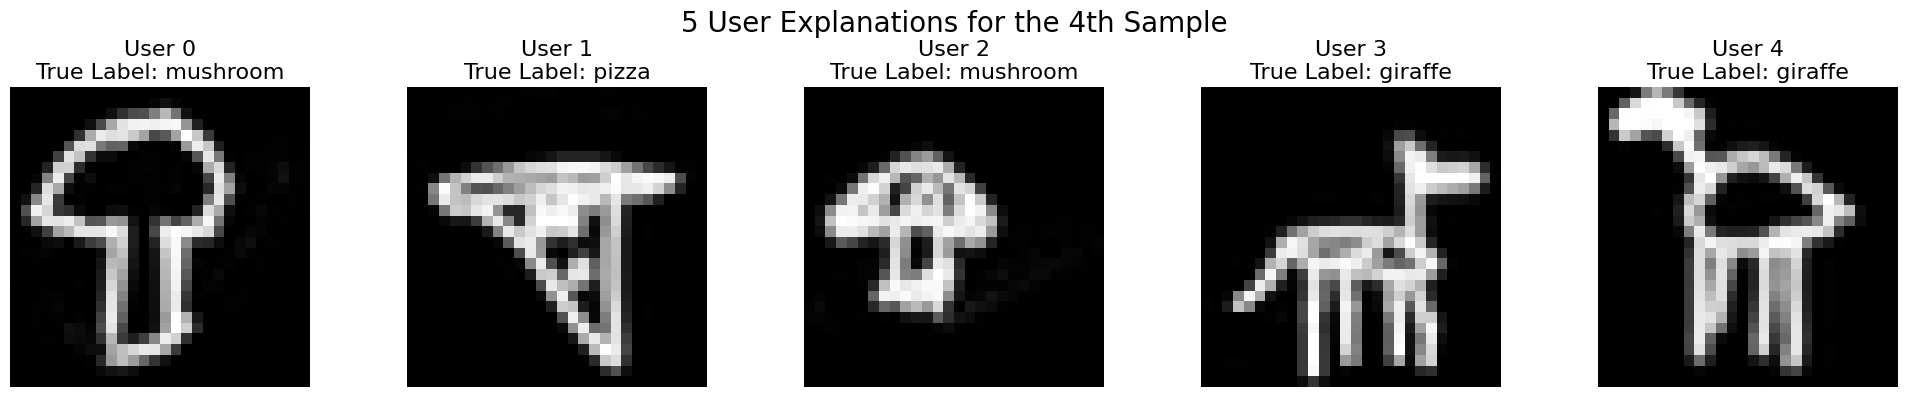

In [307]:
qd_user_explanations_flattended = quickdraw_user_explanations.reshape(-1, 28, 28, 1)
qd_true_labels_all = np.tile(quickdraw_true_labels, (5, 1)).flatten()
qd_softmax_scores = qd_baseline_model.predict(qd_user_explanations_flattended, verbose=0)
qd_preds = np.argmax(qd_softmax_scores, axis=1)
wrong_softmax_scores = qd_baseline_model.predict(quickdraw_misclassified_image_user_set, verbose=0)
qd_preds_original = np.argmax(wrong_softmax_scores, axis=1)
qd_preds_original_all = np.tile(qd_preds_wrong, (5,1)).flatten()
# visualize some of these explanations
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i in range(5):
    true_label = class_names[true_labels_all[i]]
    axes[i].imshow(qd_user_explanations_flattended[i], cmap='gray')
    axes[i].set_title(f"User {i}\nTrue Label: {true_label}", fontsize=16)
    axes[i].axis('off')

plt.suptitle("5 User Explanations for the 4th Sample", fontsize=20)
plt.tight_layout()
plt.show()

In [308]:

is_semi_factual = (qd_preds != qd_true_labels_all)

# Consistent Semi-factuals (prediction remains same as the original wrong label)
consistent_mask = is_semi_factual & (qd_preds == qd_preds_original_all)
consistent_indices = np.where(consistent_mask)[0]

# Inconsistent Semi-factuals (prediction changes but is still a wrong label)
inconsistent_mask = is_semi_factual & (qd_preds != qd_preds_original_all)
inconsistent_indices = np.where(inconsistent_mask)[0]

print(f"Total Semi-factuals: {np.sum(is_semi_factual)}")
print(f"Consistent Semi-factuals (Same Error): {len(consistent_indices)}")
print(f"Inconsistent Semi-factuals (Different Error): {len(inconsistent_indices)}")

Total Semi-factuals: 47
Consistent Semi-factuals (Same Error): 39
Inconsistent Semi-factuals (Different Error): 8


In [361]:
test = (qd_true_labels_all == qd_preds_original_all)
print(sum(test))

0


In [319]:
print(f"consistent: {39/150}, inconsistent: {8/150}")

consistent: 0.26, inconsistent: 0.05333333333333334


In [205]:
def get_semi_factuals_qd(img_idx):
    true_label = class_names[quickdraw_true_labels[img_idx]]
    pred_label = class_names[quickdraw_predicted_labels[img_idx]]
    img = quickdraw_user_explanations[0, img_idx] # 取第一个用户的解释作为示例

    original_img = quickdraw_misclassified_image_user_set[img_idx]
    original_pred_prob = qd_baseline_model.predict(original_img.reshape(1,28,28,1), verbose=0).squeeze()
    original_pred_label = class_names[np.argmax(original_pred_prob)]

    cf_data_list = quickdraw_user_explanations[:, img_idx]

    num_semi_factuals = 0
    
    for i in range(5):
        col_idx = i + 1 
        
        sample = cf_data_list[i]
        
        sample_pred_prob = qd_baseline_model.predict(sample.reshape(1,28,28,1), verbose=0).squeeze()
        sample_pred_label = class_names[np.argmax(sample_pred_prob)]

        if sample_pred_label != true_label:
            num_semi_factuals += 1

    print(f"Number of semi-factuals (model prediction changes but user explanation is the same): {num_semi_factuals}")
    return num_semi_factuals

In [206]:
len(quickdraw_misclassified_image_user_set)

30

In [207]:
all_semi_factual_counts_qd = []
for i in range(len(quickdraw_misclassified_image_user_set)):
    curr_count = get_semi_factuals_qd(i)
    all_semi_factual_counts_qd.append(curr_count)

Number of semi-factuals (model prediction changes but user explanation is the same): 0
Number of semi-factuals (model prediction changes but user explanation is the same): 1
Number of semi-factuals (model prediction changes but user explanation is the same): 5
Number of semi-factuals (model prediction changes but user explanation is the same): 1
Number of semi-factuals (model prediction changes but user explanation is the same): 1
Number of semi-factuals (model prediction changes but user explanation is the same): 1
Number of semi-factuals (model prediction changes but user explanation is the same): 0
Number of semi-factuals (model prediction changes but user explanation is the same): 3
Number of semi-factuals (model prediction changes but user explanation is the same): 2
Number of semi-factuals (model prediction changes but user explanation is the same): 5
Number of semi-factuals (model prediction changes but user explanation is the same): 1
Number of semi-factuals (model prediction c

In [208]:
sum(all_semi_factual_counts_qd)

47

In [209]:
47/150

0.31333333333333335

### Add augmentation to human CF and evaluate

In [224]:
import torch
from torchvision import transforms

def apply_aligned_transform(image, noise_sigma=0.02):
    """
    对齐训练阶段的 RandomAffine 参数，并加入针对 [-0.5, 0.5] 范围的噪声
    """
    # 1. 转换为 Tensor (假设输入是 numpy array)
    # 如果已经是 Tensor 且在 [-0.5, 0.5]，直接用
    img_tensor = torch.tensor(image, dtype=torch.float32).reshape(1, 28, 28)

    # 2. 定义对齐训练的变换序列
    # 注意：Normalize 这里不需要重复做，因为你图像已经是 [-0.5, 0.5] 了
    affine_trans = transforms.RandomAffine(
        degrees=20, 
        translate=(0.1, 0.1), 
        scale=(0.9, 1.1)
    )

    # 3. 以概率 p 应用变换
    # if np.random.rand() < p:
    #     img_tensor = affine_trans(img_tensor)
    img_tensor = affine_trans(img_tensor)  # 直接应用，不用概率控制，这样每个样本都能看到变换后的版本

    # 4. 加入高斯噪声
    # 因为你的范围只有 1.0 (从 -0.5 到 0.5)，noise_sigma 建议设小一点，比如 0.02
    noise = torch.randn_like(img_tensor) * noise_sigma
    img_tensor = img_tensor + noise

    # 5. 裁剪防止越界
    img_tensor = torch.clamp(img_tensor, -0.5, 0.5)

    return img_tensor.numpy()

In [406]:
qd_preds_wrong.shape

(30,)

In [413]:
def get_semi_factuals_qd_robust(img_idx,):
    true_label = class_names[quickdraw_true_labels[img_idx]]
    cf_data_list = quickdraw_user_explanations[:, img_idx]
    wrong_original = class_names[qd_preds_wrong[img_idx]]

    num_semi_factuals = 0
    consistent_sf = 0
    inconsistent_sf = 0
    
    for i in range(5):
        sample = cf_data_list[i]
        
        # --- Add random transformation ---
        transformed_sample = apply_aligned_transform(sample)
        
        # 使用变换后的图片进行预测
        sample_pred_prob = qd_baseline_model.predict(transformed_sample.reshape(1,28,28,1), verbose=0).squeeze()
        sample_pred_label = class_names[np.argmax(sample_pred_prob)]

        # 如果模型预测仍然不是 true_label，说明它是一个 Semi-factual
        if sample_pred_label != true_label:
            num_semi_factuals += 1
            if sample_pred_label == wrong_original:
                consistent_sf += 1
            elif sample_pred_label != wrong_original:
                inconsistent_sf += 1

    return num_semi_factuals, consistent_sf, inconsistent_sf

In [417]:
all_robust_semi_factual_counts = []
all_consistent_sf_counts = []
all_inconsistent_sf_counts = []

# 建议运行多次取平均，或者固定随机种子以保证实验可重复
np.random.seed(42) 
torch.manual_seed(42)

for i in range(len(quickdraw_misclassified_image_user_set)):
    # 在这里调用你修改后的 get_semi_factuals_qd
    # 确保函数内部使用了 apply_aligned_transform
    curr_count, consistent_sf, inconsistent_sf = get_semi_factuals_qd_robust(i)
    all_robust_semi_factual_counts.append(curr_count)
    all_consistent_sf_counts.append(consistent_sf)
    all_inconsistent_sf_counts.append(inconsistent_sf)

In [424]:
# 计算最终的 Robust Semi-factual Rate
robust_rate = np.mean(all_robust_semi_factual_counts) / 5.0
consistent_rate = sum(all_consistent_sf_counts) / 150
inconsistent_rate = sum(all_inconsistent_sf_counts) / 150
print(f"Robust Semi-factual Rate: {robust_rate:.2%}\nconsistent: {consistent_rate:.2%}\ninconsistent: {inconsistent_rate:.2%}")
print(f"num of sf counts: {sum(all_robust_semi_factual_counts)} \nconsistent counts: {sum(all_consistent_sf_counts)} \ninconsistentc counts: {sum(all_inconsistent_sf_counts)}")

Robust Semi-factual Rate: 38.00%
consistent: 25.33%
inconsistent: 12.67%
num of sf counts: 57 
consistent counts: 38 
inconsistentc counts: 19


In [228]:
sum(all_robust_semi_factual_counts)

57

In [229]:
57/150

0.38

In [234]:
quickdraw_user_explanations.shape

(5, 30, 28, 28, 1)

In [426]:
mnist_preds_original.shape

(50,)

In [436]:
def get_semi_factuals_mnist_robust(img_idx,):
    true_label = y_test[user_indices[img_idx]]
    cf_data_list = user_explanations_g1[:, img_idx]
    original_wrong = mnist_preds_original[img_idx]

    num_semi_factuals = 0
    consistent_sf = 0
    inconsistent_sf = 0
    
    for i in range(21):
        sample = cf_data_list[i]
        
        # --- Add random transformation ---
        transformed_sample = apply_aligned_transform(sample)
        
        # 使用变换后的图片进行预测
        sample_pred_prob = keras_cnn.predict(transformed_sample.reshape(1,28,28,1), verbose=0).squeeze()
        sample_pred_label = np.argmax(sample_pred_prob)

        # 如果模型预测仍然不是 true_label，说明它是一个 Semi-factual
        if sample_pred_label != true_label:
            num_semi_factuals += 1
            if sample_pred_label != original_wrong:
                inconsistent_sf += 1
            elif sample_pred_label == original_wrong:
                consistent_sf += 1


    return num_semi_factuals, consistent_sf, inconsistent_sf

In [437]:
all_robust_semi_factual_counts_mnist = []
all_consistent_counts = []
all_inconsistent_counts = []

np.random.seed(42) 
torch.manual_seed(42)

for i in range(len(user_indices)):
    # 在这里调用你修改后的 get_semi_factuals_qd
    # 确保函数内部使用了 apply_aligned_transform
    curr_count, consistent_sf, inconsistent_sf = get_semi_factuals_mnist_robust(i)
    all_robust_semi_factual_counts_mnist.append(curr_count)
    all_consistent_counts.append(consistent_sf)
    all_inconsistent_counts.append(inconsistent_sf)

In [429]:
robust_rate = np.mean(all_robust_semi_factual_counts_mnist) / 21.0
num_consistent = sum(all_consistent_counts)
num_inconsistent = sum(all_inconsistent_counts)
consistent_rate = num_consistent/1050
inconsistent_rate = num_inconsistent/1050
print(f"Robust Semi-factual Rate: {robust_rate:.2%} \nConsistent: {consistent_rate} \nInconsistent: {inconsistent_rate}")
print(f"SF counts: {sum(all_robust_semi_factual_counts_mnist)} \nConsistent: {num_consistent} \nInconsistent: {num_inconsistent}")

Robust Semi-factual Rate: 40.10% 
Consistent: 0.18476190476190477 
Inconsistent: 0.21619047619047618
SF counts: 421 
Consistent: 194 
Inconsistent: 227


In [248]:
np.mean(all_robust_semi_factual_counts_mnist)/21

0.40095238095238095

In [246]:
421/1050

0.40095238095238095

In [320]:
user_explanations_g1.shape

(21, 50, 28, 28, 1)

In [323]:
misclassified_image_user_set.shape

(50, 28, 28, 1)

In [363]:
misclassified_image_user_set.shape

(50, 28, 28, 1)

In [366]:
test = (mnist_true_labels == mnist_preds_original)
print(sum(test))

5


In [367]:
user_indices

array([ 259,  321,  445,  582,  717,  740,  882,  883, 1014, 1226, 1232,
       1260, 1364, 1393, 1621, 1681, 1878, 1901, 2070, 2148, 2293, 2414,
       2454, 2597, 2654, 3289, 3422, 3780, 3808, 3941, 4007, 4065, 4536,
       4571, 4740, 4823, 4860, 4956, 5937, 5997, 6571, 6576, 6597, 6625,
       6651, 8408, 9015, 9642, 9692, 9839])

In [401]:
mnist_user_explanations_flattended = user_explanations_g1.reshape(-1, 28, 28, 1)
mnist_true_labels = y_test[user_indices]
mnist_true_labels_all = np.tile(mnist_true_labels, (21, 1)).flatten()
mnist_softmax_scores = keras_cnn.predict(mnist_user_explanations_flattended)
mnist_preds = np.argmax(mnist_softmax_scores, axis=1)

original_imgs = x_test[user_indices].reshape(-1,28,28,1)
mnist_wrong_softmax_scores = keras_cnn.predict(original_imgs)
mnist_preds_original = np.argmax(mnist_wrong_softmax_scores, axis=1)
mnist_preds_original_all = np.tile(mnist_preds_original, (21,1)).flatten()
# visualize some of these explanations
# fig, axes = plt.subplots(1, 5, figsize=(20, 4))
# for i in range(5):
#     true_label = mnist_true_labels_all[i]
#     axes[i].imshow(mnist_user_explanations_flattended[i], cmap='gray')
#     axes[i].set_title(f"User {i}\nTrue Label: {true_label}", fontsize=16)
#     axes[i].axis('off')

# plt.suptitle("5 User Explanations for the 4th Sample", fontsize=20)
# plt.tight_layout()
# plt.show()


m_is_semi_factual = (mnist_preds != mnist_true_labels_all)

# Consistent Semi-factuals (prediction remains same as the original wrong label)
m_consistent_mask = m_is_semi_factual & (mnist_preds == mnist_preds_original_all)
m_consistent_indices = np.where(m_consistent_mask)[0]

# Inconsistent Semi-factuals (prediction changes but is still a wrong label)
m_inconsistent_mask = m_is_semi_factual & (mnist_preds != mnist_preds_original_all)
m_inconsistent_indices = np.where(m_inconsistent_mask)[0]

print(f"Total Semi-factuals: {np.sum(m_is_semi_factual)}")
print(f"Consistent Semi-factuals (Same Error): {len(m_consistent_indices)}")
print(f"Inconsistent Semi-factuals (Different Error): {len(m_inconsistent_indices)}")

2/2 [==============================] - 0s 2ms/step
Total Semi-factuals: 187
Consistent Semi-factuals (Same Error): 137
Inconsistent Semi-factuals (Different Error): 50


In [402]:
test = (mnist_preds_original == mnist_true_labels)
test_indices = np.where(test)[0]
print(test_indices)

[]


In [403]:
137/1050

0.13047619047619047

In [404]:
50/1050

0.047619047619047616

In [381]:
mnist_true_labels.shape

(50,)

In [389]:
mnist_preds_original[37]

8

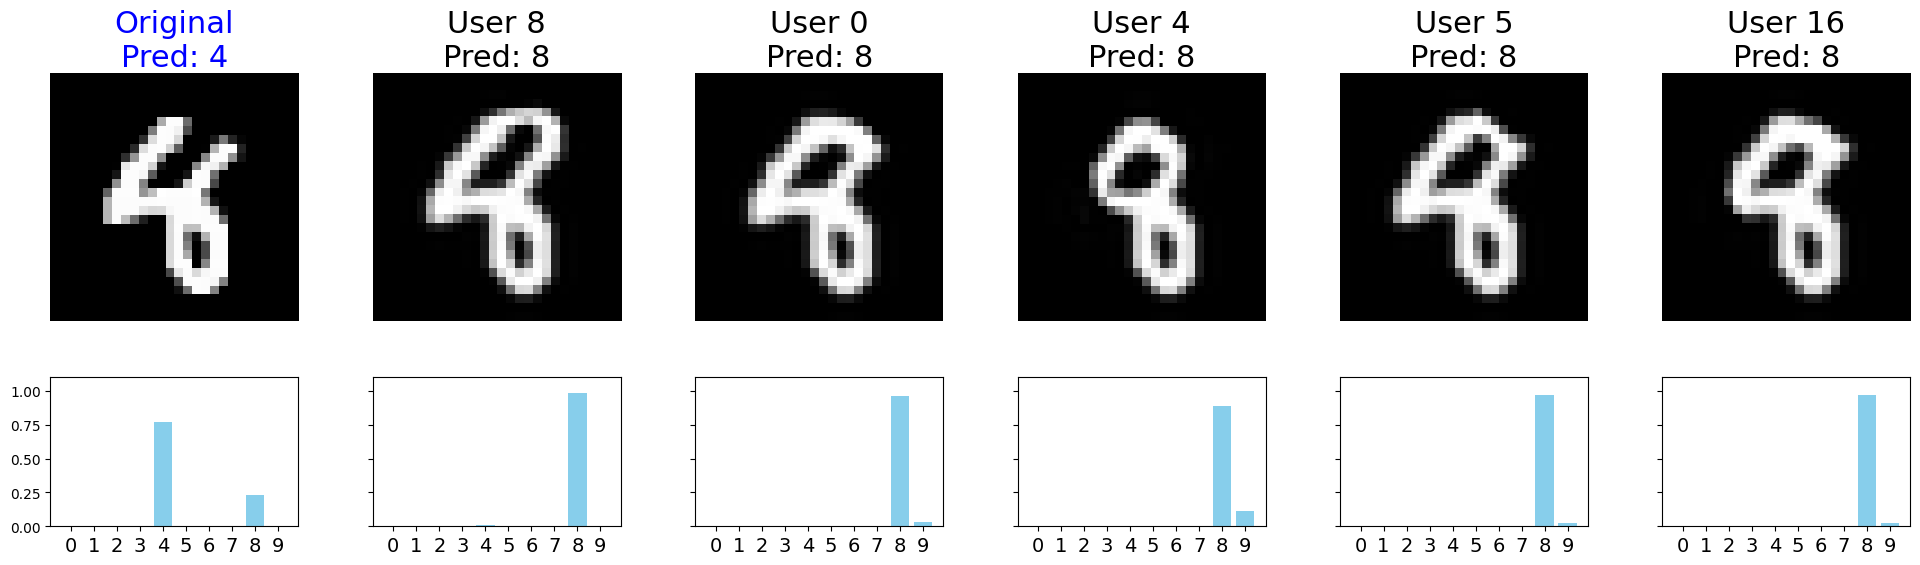

In [388]:
plot_6_columns(37, cf_indices)

In [347]:
mnist_user_explanations_flattended.shape

(1050, 28, 28, 1)

In [332]:
print(mnist_true_labels[2],mnist_preds[2],mnist_preds_original_all[2])

6 5 0


In [352]:
mnist_true_labels_all.shape

(1050,)

In [348]:
mnist_preds.shape

(1050,)

In [355]:
def plot_5x5_images(indices_to_plot, images,):

    plt.figure(figsize=(12, 12))
    
    for i, idx in enumerate(indices_to_plot):
        plt.subplot(5, 5, i + 1)
        
        img = images[idx]
        if img.ndim == 3: # 处理 (28,28,1) 的情况
            img = img.reshape(28, 28)
            
        plt.imshow(img, cmap='gray') # gray_r 让底色变白，笔画变黑，适合论文
        
        # 构造标题
        true_label = mnist_true_labels_all[idx]
        pred = mnist_preds[idx]
        original_pred = mnist_preds_original_all[idx]
        title = f"Idx:{idx}\nTrue:{true_label}\nPred:{pred}\nOriginal Pred:{original_pred}"
            
        plt.title(title, fontsize=9)
        plt.axis('off')
        
    plt.tight_layout()
    plt.show()

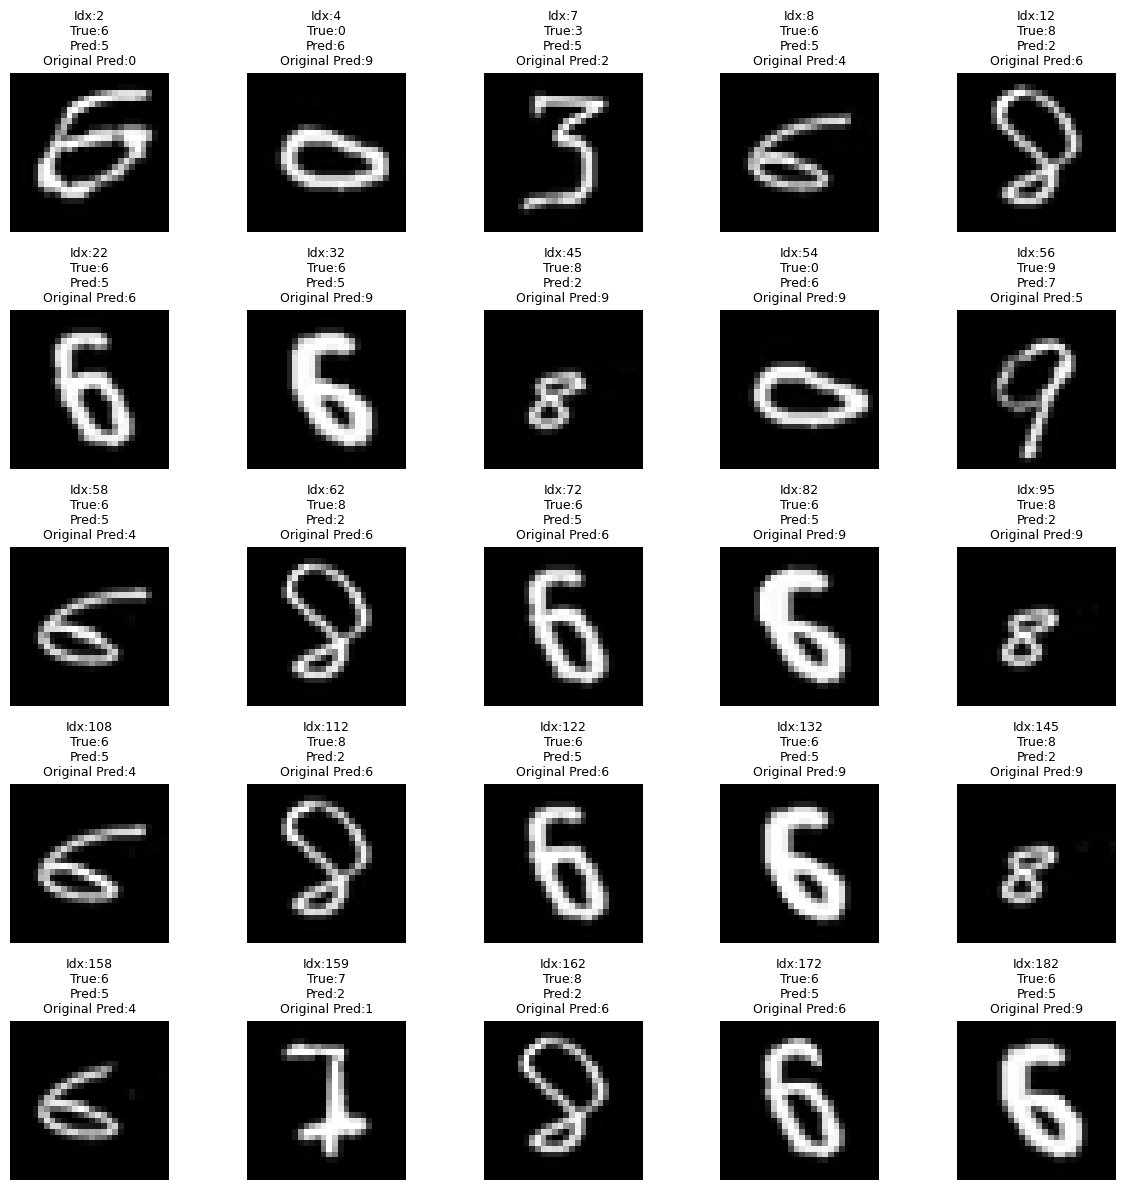

In [356]:
plot_5x5_images(m_inconsistent_indices[:25],mnist_user_explanations_flattended)

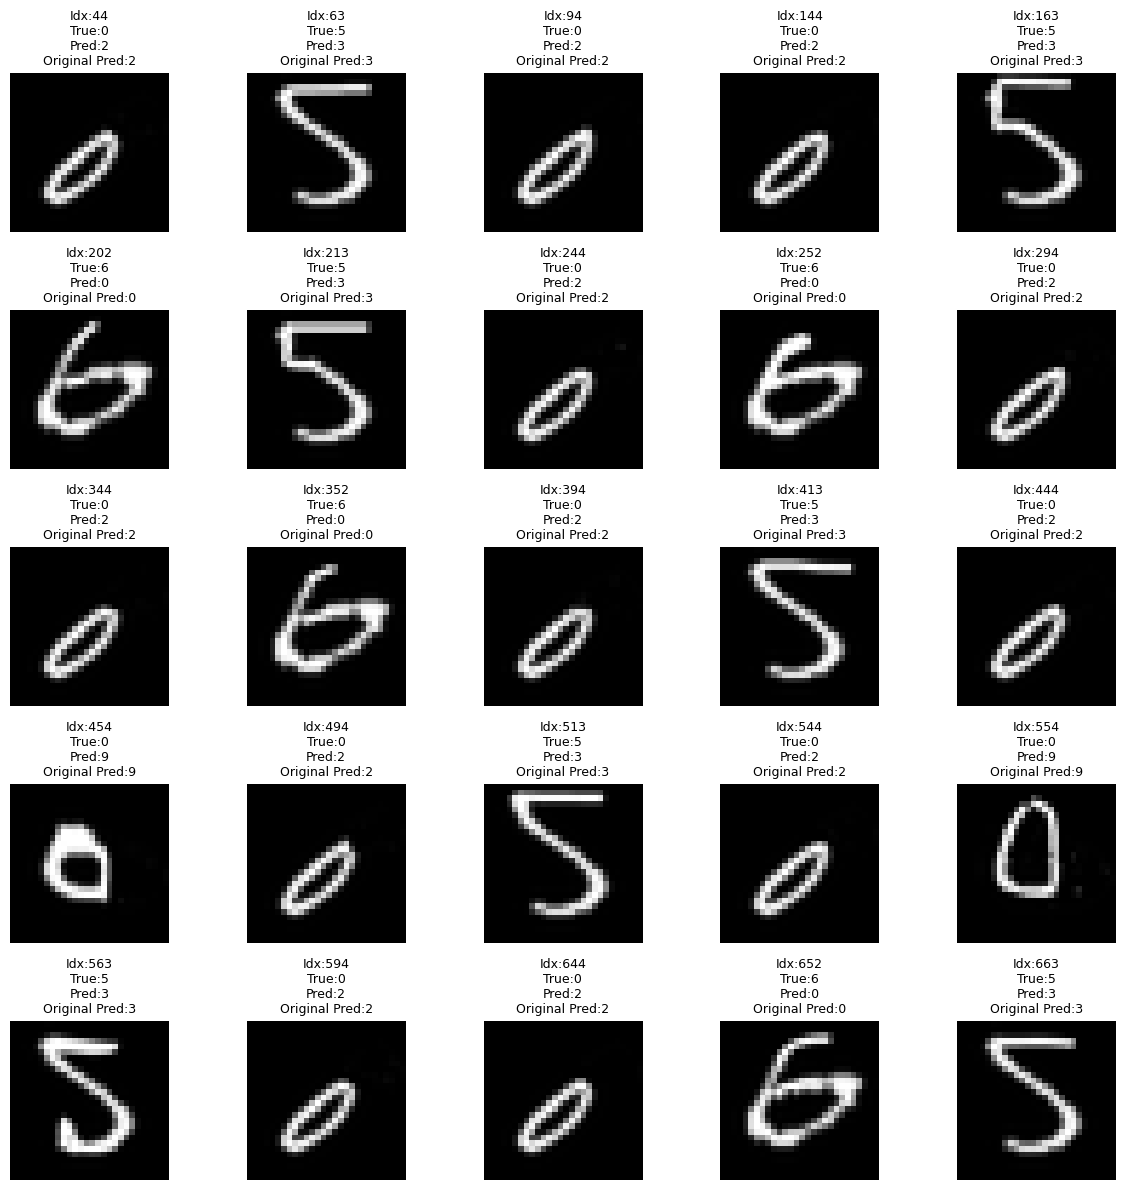

In [357]:
plot_5x5_images(m_consistent_indices[:25],mnist_user_explanations_flattended)

In [329]:
41/1050

0.039047619047619046